<a href="https://colab.research.google.com/github/jb1704/agentic-workshop/blob/main/capstone3_market_intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Market & Competitor Intelligence Agent — Capstone 3

**The problem:** desk research on competitors and markets is slow, manual, and out of date almost as soon as you finish it. A researcher spends a day reading pricing pages, press releases, product specs and analyst notes, then writes it all up by hand — and every claim needs a source or nobody trusts it.

**What this notebook builds:** an AI "agent" that acts like a fast research analyst. You ask a question in plain English about a market or a competitor, and it:

1. **Decides for itself** which research tools to use (search the documents, read a specific source, compare rivals side by side, draw a chart, check for contradictions)
2. **Reads** a library of source documents about the market — and never makes a claim up
3. **Cites every claim** back to the exact document it came from, so you can check it
4. On request, **writes a one-page competitor briefing** with charts and a list of sources

**The market we research:** the hottest topic in the news right now — the **frontier-AI market**, where AI companies compete hard on price, product and positioning. To keep the notebook 100% reproducible and runnable offline, the "companies" are realistic but *made up* (Nexus AI, Lumen Labs, Orion Systems, Beacon AI, Vertex Cognitive). An optional switch lets it also search the *real* web.

**How to use this notebook:** run every cell from top to bottom (*Runtime → Run all*). You'll only be asked for one thing: an AI API key (free from Groq or Google — see Section 5).

**What to experiment with (marked *edit me* throughout):**
- **Section 1 — the market "stories" hidden in the documents.** Switch one off, re-run, and see if the agent still notices it.
- **Section 2 — how the agent searches.** How many documents it pulls back, and whether it may search the live web.
- **Section 5 — the agent's rulebook (system prompt) and tool descriptions.** Change the wording and watch its behaviour — and its citations — change.
- **Section 4 — the scorecard.** Re-run it after every edit to see whether you made the agent better or worse.

| Section | What it does |
|---|---|
| 1 | Builds the library of source documents about the market |
| 2 | The search & reading tools the agent can use (the "RAG" retrieval) |
| 3 | Comparing competitors, extracting prices, and charts |
| 4 | The answer key + scorecard (does every claim have a source?) |
| 5 | The agent itself, the chat window, and the one-page briefing |

## Section 1: Building Our Market Intelligence Library

Before an AI agent can research a market, it needs a library of source documents to research *from*. Real competitive intelligence work means reading pricing pages, product pages, press releases, and reviews, then figuring out what they actually say.

This notebook gives the agent a **pretend but realistic library** about a pretend market: five fictional AI companies competing on price, product capability, and positioning. None of these companies are real — they are **generated by code** in the next few cells — which means we know the ground truth in advance and can grade the agent's answers against it.

**The five fictional competitors**

| Company | Flagship model | Positioning | Price posture |
|---|---|---|---|
| Nexus AI | Nexus-4 | Premium frontier quality, best benchmarks | Most expensive |
| Lumen Labs | Lumen-Flash | Fastest + open-weight, developer-first | Cheapest |
| Orion Systems | Orion-Pro | Enterprise, security & compliance, huge context | Mid-high |
| Beacon AI | Beacon-One | Consumer assistant, best free tier | Low-mid |
| Vertex Cognitive | Vertex-Reason | Reasoning / agentic specialist, newest entrant | Mid |

**The document library (`CORPUS`)**

Each "document" is a small dict: which company it's about, what kind of source it is (a pricing page, a product page, a press release, a review, an analyst note, or a market overview), a title, a URL, a date, and 120-400 words of realistic prose. We build roughly 27 of these — at least one pricing, product, press release, and review document per company, plus a handful of cross-company analyst notes and market overviews, plus a couple of deliberately unrelated "distractor" documents so the agent's search tool (built in Section 2) actually has to work for its answers.

**Hidden "market stories"**

Just like a real market, we plant a few headline facts in the data on purpose, so we know the right answers in advance:

1. **Lumen Labs is the cheapest** API on the market, full stop.
2. **Nexus AI is the most expensive** — it competes on quality, not price.
3. **Orion Systems just pushed to a 2,000,000-token context window** — the biggest in the market (a "context window race" story you can switch off).
4. **Beacon AI has the best free tier** of any assistant in the corpus.
5. **Vertex Cognitive is the newest entrant**, having just launched in September 2026 (a "new entrant" story you can switch off).
6. **Lumen Labs just cut its API prices by about 40%** — a live "price war" (a story you can switch off).

We also keep a running list of things **no document in this library covers** (things like stock prices, headcount, or market share) — a good agent should say "the sources don't cover that" instead of making a number up.

Every one of these facts is written down as code, in a dictionary called `PLANTED_FACTS`, so later sections can check whether the agent got them right.

### ✏️ The corpus knobs — try changing these!

The cell below is the control panel for the pretend market. Each line is a setting you can edit:

- `include_live_search` turns on an optional *real* web-search tool for the agent later in the notebook (Section 2). Leave it `False` and everything below runs completely offline.
- `price_war`, `context_window_race`, and `new_entrant` each switch one planted story **on or off**. Turn one off, re-run the notebook, and ask the agent about it — a good agent should correctly say nothing unusual is happening.
- `random_seed` is the "shuffle" for the small amount of randomness in the library (things like reviewer names and star ratings). The same seed always gives exactly the same library.

After changing a knob, re-run this cell **and every cell below it** (in Colab: *Runtime → Run after*).

In [33]:
import numpy as np
import pandas as pd

CORPUS_KNOBS = {
    "random_seed": 42,              # same seed = same corpus every time
    "include_live_search": True,   # optional real web-search tool (needs network); off = pure offline
    "price_war": True,              # Lumen Labs slashes API prices ~40%
    "context_window_race": True,    # Orion Systems advertises a 2,000,000-token context window
    "new_entrant": True,            # Vertex Cognitive just launched Vertex-Reason (Sep 2026 press release)
}

### Building the document library

The next cell is the "document factory." You don't need to read every line — here is what it does in plain English:

1. **Authors the numbers first.** For every company it decides the API price, the subscription price, the context window size, the supported modalities, and the one-line positioning claim — *before* writing a single word of prose. This is the ground truth, stored later as `PLANTED_FACTS`.
2. **Writes matching prose.** Every pricing page, product page, press release, and review is written so that it *literally states* the numbers decided in step 1 — so when the agent later cites a document, the citation actually backs up the claim.
3. **Applies the corpus knobs.** If `price_war` is on, Lumen Labs' pricing page and a press release reflect a fresh 40% price cut; if it's off, the pricing page shows the older, higher price and the press release is about something else entirely (an open-weights release). The same idea applies to Orion Systems' context window and Vertex Cognitive's "newest entrant" story.
4. **Adds a few cross-company documents** — market overviews and analyst notes that compare all five companies — plus two tangential "distractor" documents that mention the market only in passing, so retrieval in Section 2 has to actually find the right document rather than just reading the whole library.
5. **Builds `PLANTED_FACTS`** — the answer key — from the exact same variables used to write the prose, so the two can never drift apart.

It runs in well under a second.

In [2]:
COMPANIES = ["Nexus AI", "Lumen Labs", "Orion Systems", "Beacon AI", "Vertex Cognitive"]
PREFIX = {"Nexus AI": "nexus", "Lumen Labs": "lumen", "Orion Systems": "orion",
          "Beacon AI": "beacon", "Vertex Cognitive": "vertex"}


def _money(x):
    return f"${x:,.2f}"


def build_corpus_and_facts(knobs):
    """Return (CORPUS, PLANTED_FACTS) for the given CORPUS_KNOBS. Deterministic for the seed."""
    rng = np.random.default_rng(knobs["random_seed"])
    price_war = knobs["price_war"]
    ctx_race = knobs["context_window_race"]
    new_entrant = knobs["new_entrant"]

    # ---------------------------------------------------------------
    # 1) Author the numbers FIRST. Corpus prose below is written to
    #    literally state these same numbers, so the two can never drift apart.
    # ---------------------------------------------------------------
    nexus = dict(model="Nexus-4", api_input_usd_1m=10.00, api_output_usd_1m=30.00, sub_usd_month=30,
                 context_window=400_000, modalities=["text", "image", "audio"],
                 key_feature="top benchmark scores across reasoning, coding, and multimodal tasks",
                 segment="Frontier/premium", claim="the highest quality model available")

    lumen_input_pre, lumen_output_pre, lumen_cut_pct = 0.25, 1.00, 0.40
    lumen_input = round(lumen_input_pre * (1 - lumen_cut_pct), 2) if price_war else lumen_input_pre
    lumen_output = round(lumen_output_pre * (1 - lumen_cut_pct), 2) if price_war else lumen_output_pre
    lumen = dict(model="Lumen-Flash", api_input_usd_1m=lumen_input, api_output_usd_1m=lumen_output, sub_usd_month=8,
                 context_window=128_000, modalities=["text", "image"],
                 key_feature="open-weight model available for self-hosting, fastest inference in its class",
                 segment="Developer/open-weight",
                 claim="the fastest and cheapest way to build with a frontier-grade model")

    orion_context = 2_000_000 if ctx_race else 300_000
    orion = dict(model="Orion-Pro", api_input_usd_1m=7.00, api_output_usd_1m=20.00, sub_usd_month=40,
                 context_window=orion_context, modalities=["text", "image"],
                 key_feature="SOC 2 Type II and HIPAA-ready deployment with dedicated enterprise support",
                 segment="Enterprise", claim="the most secure and compliant model for regulated industries")

    beacon_free_msgs = 1000
    beacon = dict(model="Beacon-One", api_input_usd_1m=0.50, api_output_usd_1m=2.00, sub_usd_month=10,
                  context_window=64_000, modalities=["text", "image"],
                  key_feature=f"a free tier of {beacon_free_msgs:,} messages per month, no credit card required",
                  segment="Consumer", claim="the best free tier of any mainstream AI assistant")

    vertex = dict(model="Vertex-Reason", api_input_usd_1m=3.00, api_output_usd_1m=12.00, sub_usd_month=25,
                  context_window=256_000, modalities=["text"],
                  key_feature="specializes in multi-step agentic reasoning and autonomous tool use",
                  segment="Reasoning/agentic specialist",
                  claim="built specifically for autonomous, multi-step agentic workflows")

    company_facts = {"Nexus AI": nexus, "Lumen Labs": lumen, "Orion Systems": orion,
                      "Beacon AI": beacon, "Vertex Cognitive": vertex}

    # A little seeded flavor so the corpus is not 100% static text (reviewer names + star ratings)
    reviewer_names = rng.choice(
        ["J. Alvarez", "M. Chen", "S. Okafor", "R. Patel", "T. Novak", "L. Bergström"],
        size=5, replace=False)
    review_ratings = {c: round(float(rng.uniform(3.9, 4.8)), 1) for c in COMPANIES}

    # ---------------------------------------------------------------
    # 2) Build the document prose. Each dict of "docs" below maps
    #    doc_id -> the fields the CORPUS contract requires.
    # ---------------------------------------------------------------
    docs = []

    def add(doc_id, company, source_type, title, url, date, text):
        words = len(text.split())
        assert 120 <= words <= 400, f"{doc_id} has {words} words (need 120-400)"
        docs.append({"doc_id": doc_id, "company": company, "source_type": source_type,
                     "title": title, "url": url, "date": date, "text": " ".join(text.split())})

    # ---- Nexus AI ----
    add("nexus-pricing-01", "Nexus AI", "pricing", "Nexus AI - API & Plan Pricing (Feb 2026)",
        "https://nexus.ai/pricing", "2026-02-10",
        f"""Nexus AI prices its flagship Nexus-4 model at the top of the frontier-AI market, and the
        company makes no apology for it. Developers calling the API pay {_money(nexus['api_input_usd_1m'])}
        per million input tokens and {_money(nexus['api_output_usd_1m'])} per million output tokens, the
        highest rate card of any of the major assistant providers. Nexus AI argues the premium is
        justified because Nexus-4 posts {nexus['key_feature']}, and enterprise buyers routinely tell the
        company that quality, not price, is the deciding factor for mission-critical workloads.
        For consumers, the Nexus app is available as a subscription at {_money(nexus['sub_usd_month'])[:-3]}
        {nexus['sub_usd_month']}/month, which unlocks unlimited chat, image understanding, and voice mode.
        There is no metered pay-as-you-go consumer tier and no free tier at all; Nexus AI positions
        itself deliberately as the expensive, best-in-class option rather than competing on price. The
        pricing page notes that volume discounts are available for enterprise contracts above 50 million
        tokens per month, but the list price above remains the highest published rate in the market,
        well above Orion Systems, Vertex Cognitive, Beacon AI, and Lumen Labs. Nexus AI's billing team
        says this reflects the compute cost of running its largest model at full precision for every
        request, with no quantization shortcuts that could reduce output quality.""")

    add("nexus-product-01", "Nexus AI", "product", "Nexus-4 Model Card",
        "https://nexus.ai/models/nexus-4", "2026-02-01",
        f"""Nexus-4 is Nexus AI's flagship model and the centerpiece of the company's Frontier/premium
        strategy. It ships with a {nexus['context_window']:,}-token context window, comfortably enough
        to hold a full research paper and its citations in a single prompt, and it accepts three
        modalities: {', '.join(nexus['modalities'])}. Nexus AI's internal and third-party benchmark
        results show {nexus['key_feature']}, and the company's marketing describes Nexus-4 plainly as
        {nexus['claim']}, a claim it backs with published leaderboard scores in reasoning, coding, and
        long-document comprehension. The model card notes that Nexus-4 was trained with an emphasis on
        factual grounding and refusal calibration, and that the audio modality supports both
        transcription and expressive text-to-speech in eleven languages. Unlike some rivals, Nexus AI
        has not open-sourced any weights for this model family, keeping Nexus-4 available exclusively
        through its hosted API and consumer app. The company positions this as consistent with its
        premium strategy: total control over the serving stack lets Nexus AI guarantee the exact
        benchmark performance advertised, rather than the variable quality that can come from
        third-party or self-hosted deployments of an open model.""")

    add("nexus-press-01", "Nexus AI", "press_release", "Nexus AI Announces Nexus-4, Setting New Benchmark Records",
        "https://nexus.ai/news/nexus-4-launch", "2026-01-20",
        f"""Nexus AI today announced the general availability of Nexus-4, the company's most capable
        model to date and, it says, {nexus['claim']}. In a series of published evaluations, Nexus-4
        outperformed every publicly available competitor model on reasoning and coding benchmarks,
        continuing Nexus AI's strategy of competing purely on capability rather than price. "We built
        Nexus-4 for the customers who cannot afford a wrong answer," said the company's head of
        research in the announcement. The model supports a {nexus['context_window']:,}-token context
        window and understands text, images, and audio in a single conversation. Nexus AI confirmed
        that Nexus-4 will be priced at a premium relative to the rest of the market, reflecting the
        additional compute required to serve the model at full quality, and said it has no plans to
        introduce a discounted or free tier. Early enterprise partners in finance and healthcare were
        cited as adopting Nexus-4 specifically for its benchmark accuracy on high-stakes tasks. The
        release follows nine months of internal testing and positions Nexus AI firmly at the top of
        the frontier-AI market on capability, even as several rivals compete more aggressively on
        price and free access.""")

    add("nexus-review-01", "Nexus AI", "review", "Nexus-4 Review: Excellent, Expensive, and It Knows It",
        "https://airesearchreview.com/reviews/nexus-4", "2026-03-05",
        f"""We spent three weeks running Nexus-4 through our standard evaluation suite, and the short
        version is: it is the best model we have tested this year, and also comfortably the most
        expensive. At {_money(nexus['api_input_usd_1m'])} per million input tokens and
        {_money(nexus['api_output_usd_1m'])} per million output tokens, Nexus AI is charging well above
        Orion Systems, Vertex Cognitive, Beacon AI, and especially Lumen Labs, and the company does not
        pretend otherwise. What you get for the money is real: {nexus['key_feature']}, and the
        {nexus['context_window']:,}-token context window handled our long-document tests without the
        quality drop-off we saw in some cheaper models. Our reviewer gave the model
        {review_ratings['Nexus AI']} out of 5 stars, docking points only for cost and for the complete
        absence of a free or discounted tier for indie developers. If your workload is price-sensitive,
        Nexus-4 is probably not for you; Lumen-Flash or Beacon-One will save real money. But if you
        need the highest achievable quality and can absorb the bill, Nexus-4 currently sets the bar
        that every other frontier model in this review is measured against.""")

    # ---- Lumen Labs ----
    if price_war:
        lumen_pricing_date, lumen_press_date, lumen_review_date = "2026-08-05", "2026-08-01", "2026-08-20"
        lumen_pricing_extra = (f"This follows an across-the-board {int(lumen_cut_pct * 100)}% cut from the "
                                f"previous rate of {_money(lumen_input_pre)} / {_money(lumen_output_pre)} per "
                                f"million tokens, announced in August 2026.")
        lumen_press_text = f"""Lumen Labs today announced an across-the-board {int(lumen_cut_pct * 100)}% cut
        to Lumen-Flash API pricing, dropping the rate from {_money(lumen_input_pre)} per million input tokens
        and {_money(lumen_output_pre)} per million output tokens down to {_money(lumen_input)} and
        {_money(lumen_output)} respectively. "We are starting a price war, and we intend to win it," said
        Lumen Labs' CEO in a company blog post accompanying the announcement. The cut makes Lumen-Flash the
        cheapest frontier-grade API in the market by a wide margin, undercutting Beacon AI, Vertex
        Cognitive, Orion Systems, and Nexus AI on both input and output token pricing. Lumen Labs said the
        move is possible because of efficiency gains in its inference stack and because, as an open-weight
        model, Lumen-Flash can be served on commodity hardware without the licensing overhead some
        competitors carry. Analysts expect rival providers to face pressure to respond with price cuts of
        their own. Lumen Labs framed the announcement as core to its developer-first strategy: {lumen['key_feature']},
        and the company said today's cut is meant to make Lumen-Flash the default choice for
        cost-conscious developers and startups building on a tight budget, not a temporary promotion."""
    else:
        lumen_pricing_date, lumen_press_date, lumen_review_date = "2026-03-01", "2026-03-15", "2026-04-10"
        lumen_pricing_extra = "Lumen Labs has kept this rate card unchanged since Lumen-Flash launched."
        lumen_press_text = f"""Lumen Labs today announced that the full model weights for Lumen-Flash are
        now downloadable for self-hosting under a permissive open license, the latest move in the
        company's developer-first strategy. "We think {lumen['key_feature']}, and now you don't even
        need our API to prove it," said a Lumen Labs spokesperson. The release includes quantized
        checkpoints suitable for running on a single high-end GPU, along with reference code for
        fine-tuning. Lumen Labs' hosted API remains available at {_money(lumen_input)} per million input
        tokens and {_money(lumen_output)} per million output tokens for developers who prefer not to
        manage their own infrastructure, a rate the company already advertises as the most affordable
        of the major frontier-grade assistants. The company said today's open-weight release is aimed
        squarely at researchers and startups who want full control over deployment, and reiterated that
        Lumen-Flash remains focused on being the fastest and cheapest way to build with a frontier-grade
        model, whether self-hosted or through the Lumen Labs API. No pricing changes accompanied
        today's release."""

    add("lumen-pricing-01", "Lumen Labs", "pricing", "Lumen Labs - API & Plan Pricing",
        "https://lumenlabs.dev/pricing", lumen_pricing_date,
        f"""Lumen Labs prices Lumen-Flash as the most affordable frontier-grade model available today.
        The API charges {_money(lumen_input)} per million input tokens and {_money(lumen_output)} per
        million output tokens, undercutting every other major provider covered in this corpus, including
        Beacon AI, Vertex Cognitive, Orion Systems, and Nexus AI. {lumen_pricing_extra} A consumer
        subscription is also available at ${lumen['sub_usd_month']}/month for unlimited chat access, again
        the lowest subscription price among the five companies compared here. Lumen Labs says it can hold
        this pricing because {lumen['key_feature']}, letting the company pass inference savings straight
        to customers instead of spending on proprietary serving infrastructure the way closed-model
        competitors do. The pricing page also highlights a free, rate-limited developer tier for testing
        integrations before committing to paid usage. Lumen Labs' stated strategy is to win developers on
        cost and speed first, arguing that most production workloads do not need Nexus-4-level benchmark
        scores and would rather pay a fraction of the price for a model that is fast, open, and
        good enough for the vast majority of real-world tasks its customers actually run.""")

    add("lumen-product-01", "Lumen Labs", "product", "Lumen-Flash Model Card",
        "https://lumenlabs.dev/models/lumen-flash", "2026-03-01",
        f"""Lumen-Flash is Lumen Labs' flagship model, built around a simple thesis: {lumen['claim']}.
        The model supports a {lumen['context_window']:,}-token context window and two modalities,
        {', '.join(lumen['modalities'])}, and is tuned for low-latency responses suited to interactive
        developer tools, chat products, and agent pipelines that need to make many calls quickly. Unlike
        Nexus AI and Beacon AI, Lumen Labs publishes the full model weights for Lumen-Flash, letting
        customers self-host on their own infrastructure for maximum control over cost and data
        residency. The model card describes Lumen-Flash as {lumen['key_feature']}, and independent
        latency benchmarks cited by the company show response times meaningfully faster than every
        closed-weight competitor in this corpus. Lumen Labs targets the segment it calls
        "{lumen['segment']}": engineering teams that want to move fast, inspect exactly what they are
        running, and avoid vendor lock-in. The company acknowledges that Lumen-Flash trails Nexus-4 on
        the hardest reasoning benchmarks, but argues that for the large majority of production use
        cases, especially high-volume, latency-sensitive ones, Lumen-Flash's speed and openness matter
        more than a few extra benchmark points most customers will never notice.""")

    add("lumen-press-01", "Lumen Labs", "press_release",
        "Lumen Labs Cuts API Prices" if price_war else "Lumen Labs Open-Sources Lumen-Flash Weights",
        "https://lumenlabs.dev/news/pricing-update" if price_war else "https://lumenlabs.dev/news/open-weights",
        lumen_press_date, lumen_press_text)

    add("lumen-review-01", "Lumen Labs", "review", "Lumen-Flash Review: Fast, Cheap, Open",
        "https://devtoolsweekly.com/reviews/lumen-flash", lumen_review_date,
        f"""Lumen-Flash has quickly become our default recommendation for developers who need a
        frontier-grade model without a frontier-grade bill. At {_money(lumen_input)} per million input
        tokens and {_money(lumen_output)} per million output tokens, it is the cheapest model of the five
        we cover regularly, undercutting Beacon AI, Vertex Cognitive, Orion Systems, and Nexus AI by a
        wide margin on every pricing metric we track. Latency in our tests was the best in class, and the
        {lumen['context_window']:,}-token context window is plenty for the coding-assistant and
        chat-agent workloads most of our readers build. We especially appreciated that Lumen Labs
        publishes open weights, which let our team run a self-hosted evaluation copy with zero API cost
        for high-volume load testing, something none of the closed-weight competitors in this review
        allow. Our reviewer scored Lumen-Flash {review_ratings['Lumen Labs']} out of 5, noting that it
        will not beat Nexus-4 on the hardest reasoning benchmarks, but for cost-sensitive teams building
        real products at scale, Lumen Labs' combination of low price, high speed, and open weights is
        very hard to beat right now.""")

    # ---- Orion Systems ----
    if ctx_race:
        orion_product_date, orion_press_date, orion_review_date = "2026-07-01", "2026-07-01", "2026-07-20"
        orion_ctx_sentence = (f"In July 2026 Orion Systems expanded the context window to "
                               f"{orion_context:,} tokens, the largest of any model covered in this "
                               f"corpus, aimed at customers who need to reason over entire contract "
                               f"repositories or years of case history in a single request.")
        orion_press_text = f"""Orion Systems today announced that Orion-Pro now supports a
        {orion_context:,}-token context window, the largest of any frontier assistant covered in this
        corpus, more than four times the window offered by Nexus AI and well beyond every other
        competitor. The expansion is aimed squarely at Orion Systems' enterprise customer base in legal,
        financial services, and healthcare, where reviewers routinely need a model to reason over
        thousands of pages of contracts, filings, or patient history in a single request. "No other
        vendor lets you load an entire contract repository into one prompt," said Orion Systems' head of
        product in today's announcement. The larger window is available immediately to all customers on
        Orion Systems' enterprise plan at no additional cost. Orion Systems continues to position
        Orion-Pro around {orion['key_feature']}, and says the new context window strengthens its case as
        {orion['claim']}, arguing that {orion['segment']} buyers evaluating frontier models should weigh
        context length as heavily as raw benchmark scores when the workload involves large, sensitive
        documents that cannot be chunked without losing important cross-references."""
    else:
        orion_product_date, orion_press_date, orion_review_date = "2026-03-01", "2026-02-15", "2026-04-15"
        orion_ctx_sentence = (f"Orion-Pro currently ships with a {orion_context:,}-token context "
                               f"window, comfortably large enough for most enterprise document "
                               f"review workflows.")
        orion_press_text = f"""Orion Systems today announced that Orion-Pro has completed SOC 2 Type II
        certification and is now available with HIPAA-ready deployment options for healthcare
        customers, extending the compliance credentials the company has built its enterprise business
        on. "Security and compliance are not features we bolt on, they are the product," said Orion
        Systems' chief compliance officer in today's announcement. The certification covers Orion
        Systems' full hosted platform, including audit logging, data residency controls, and role-based
        access, and follows a six-month external audit. Orion Systems continues to position Orion-Pro
        around {orion['key_feature']}, arguing that {orion['claim']} for regulated industries such as
        {orion['segment'].lower()} customers in finance, healthcare, and government. The company said
        today's certification will let it pursue larger contracts with customers who previously could
        not adopt a third-party model provider under their existing compliance policies, and confirmed
        that no changes to pricing or model capability accompanied the announcement."""

    add("orion-pricing-01", "Orion Systems", "pricing", "Orion Systems - API & Plan Pricing",
        "https://orionsystems.ai/pricing", "2026-04-01",
        f"""Orion Systems prices Orion-Pro for enterprise buyers who need security and compliance
        guarantees alongside strong model quality. The API charges {_money(orion['api_input_usd_1m'])}
        per million input tokens and {_money(orion['api_output_usd_1m'])} per million output tokens,
        placing Orion Systems in the mid-to-high range of the market: more expensive than Lumen Labs,
        Beacon AI, and Vertex Cognitive, but below Nexus AI's top-of-market rate. Enterprise seats are
        billed separately at ${orion['sub_usd_month']}/month per user, which includes dedicated support,
        audit logging, and the compliance tooling described on Orion Systems' security page. Orion
        Systems does not offer a free consumer tier; its go-to-market is entirely enterprise sales-led,
        with custom contracts available for customers processing above 100 million tokens per month.
        The pricing page notes that Orion Systems' rate reflects the additional infrastructure required
        to meet {orion['key_feature']}, which the company says smaller or less compliance-focused
        competitors are not equipped to guarantee at scale, and that customers in {orion['segment'].lower()}
        contexts consistently tell Orion Systems that compliance guarantees, not raw price, drive their
        purchasing decision.""")

    add("orion-product-01", "Orion Systems", "product", "Orion-Pro Model Card",
        "https://orionsystems.ai/models/orion-pro", orion_product_date,
        f"""Orion-Pro is Orion Systems' flagship model, built for the {orion['segment']} segment.
        {orion_ctx_sentence} The model supports {', '.join(orion['modalities'])} inputs and ships with
        {orion['key_feature']}, making it the compliance-first choice among the five companies covered
        in this corpus. Orion Systems markets Orion-Pro as {orion['claim']}, a claim aimed directly at
        {orion['segment'].lower()} buyers in finance, healthcare, and government who face strict
        regulatory requirements around data handling and auditability. The model card notes that every
        Orion-Pro deployment includes configurable data residency, full request-level audit logs, and
        role-based access controls out of the box, none of which are optional add-ons. Orion Systems
        says this focus on compliance and context length, rather than chasing the very top of every
        public benchmark leaderboard, is a deliberate trade-off: Orion-Pro slightly trails Nexus-4 on
        raw reasoning benchmarks but wins enterprise deals specifically because it can be deployed in
        regulated environments where competitors' compliance posture disqualifies them outright.""")

    add("orion-press-01", "Orion Systems", "press_release",
        "Orion Systems Expands Context Window to 2,000,000 Tokens" if ctx_race
        else "Orion-Pro Achieves SOC 2 Type II and HIPAA-Ready Certification",
        "https://orionsystems.ai/news/context-window-expansion" if ctx_race
        else "https://orionsystems.ai/news/soc2-hipaa-certification",
        orion_press_date, orion_press_text)

    add("orion-review-01", "Orion Systems", "review", "Orion-Pro Review: Built for the Compliance Team, Not the Leaderboard",
        "https://enterprise-it-weekly.com/reviews/orion-pro", orion_review_date,
        f"""We evaluated Orion-Pro from the perspective our readers actually care about: can we deploy
        this at a regulated enterprise without our compliance team saying no. The answer is a clear yes.
        Orion Systems ships {orion['key_feature']}, and {orion_ctx_sentence.lower()} At
        {_money(orion['api_input_usd_1m'])} per million input tokens and
        {_money(orion['api_output_usd_1m'])} per million output tokens, Orion-Pro sits in the mid-to-high
        price band, above Lumen Labs, Beacon AI, and Vertex Cognitive but below Nexus AI. On raw
        reasoning benchmarks, Orion-Pro trails Nexus-4 by a modest margin, but that was never really the
        point for the enterprise, healthcare, and government evaluators we spoke with. Our reviewer
        scored Orion-Pro {review_ratings['Orion Systems']} out of 5, docking points only for the lack of
        any self-serve or consumer-friendly tier. If your organization needs a documented compliance
        story and the ability to reason over huge documents in one pass, Orion Systems is currently the
        clearest choice in the market; if you just want the highest benchmark score at any price, look
        at Nexus AI instead.""")

    # ---- Beacon AI ----
    add("beacon-pricing-01", "Beacon AI", "pricing", "Beacon AI - Plans & API Pricing",
        "https://beacon.ai/pricing", "2026-03-10",
        f"""Beacon AI positions itself around value and accessibility rather than raw benchmark
        performance. The consumer app offers {beacon['key_feature']}, the most generous free
        allowance of any assistant covered in this corpus, before asking users to upgrade to the
        ${beacon['sub_usd_month']}/month Beacon Plus subscription for higher limits and priority
        response times. For developers, the Beacon-One API is priced at
        {_money(beacon['api_input_usd_1m'])} per million input tokens and
        {_money(beacon['api_output_usd_1m'])} per million output tokens, a low-mid rate that undercuts
        Orion Systems, Vertex Cognitive, and Nexus AI, though it remains slightly above Lumen Labs'
        post-price-cut rate. Beacon AI says the free tier is not a limited-time trial but a permanent
        part of its product: the company's stated mission is to make a genuinely useful AI assistant
        available to anyone with a smartphone, regardless of ability to pay. Beacon AI's pricing page
        notes that the free tier is subsidized by the paid subscription and enterprise API customers,
        and that no free-tier conversation data is used to train future models without explicit user
        opt-in, a point the company markets heavily to privacy-conscious consumers comparing it against
        rival assistants.""")

    add("beacon-product-01", "Beacon AI", "product", "Beacon-One Model Card",
        "https://beacon.ai/models/beacon-one", "2026-03-01",
        f"""Beacon-One is Beacon AI's consumer-facing flagship model, built for the {beacon['segment']}
        segment rather than for developers building complex agent pipelines. It ships with a
        {beacon['context_window']:,}-token context window, modest compared to enterprise-focused rivals
        but more than sufficient for everyday chat, homework help, travel planning, and everyday writing
        tasks, and it supports {', '.join(beacon['modalities'])} inputs so users can snap a photo of a
        menu, a math problem, or a broken appliance and get a useful answer. Beacon AI's headline claim
        is that Beacon-One offers {beacon['claim']}, backed by {beacon['key_feature']} available to
        every user without a credit card. The model card emphasizes ease of use over raw capability:
        Beacon AI deliberately tunes Beacon-One's responses to be shorter and friendlier than the more
        technical output style of developer-first competitors like Lumen Labs. Beacon AI says internal
        research shows most consumer users never hit the free-tier limit in a typical month, and that
        the free tier is central to the company's strategy of becoming the default AI assistant for
        people who have never used one before.""")

    add("beacon-press-01", "Beacon AI", "press_release", "Beacon AI Passes 10 Million Monthly Active Users",
        "https://beacon.ai/news/10-million-users", "2026-05-01",
        f"""Beacon AI today announced that Beacon-One has surpassed 10 million monthly active users,
        crediting the milestone to its free-tier strategy: {beacon['key_feature']}. "We built Beacon-One
        for people who have never paid for an AI product and might never want to," said Beacon AI's
        head of growth in today's announcement. The company said the vast majority of its user base
        remains on the free tier, with a smaller share converting to the ${beacon['sub_usd_month']}/month
        Beacon Plus subscription for higher usage limits. Beacon AI reiterated that its API pricing,
        {_money(beacon['api_input_usd_1m'])} per million input tokens and
        {_money(beacon['api_output_usd_1m'])} per million output tokens, remains aimed at developers who
        want to build consumer-friendly products without enterprise-grade pricing. Unlike Nexus AI and
        Orion Systems, which target premium and enterprise buyers respectively, Beacon AI said today's
        milestone confirms its consumer, value-first strategy is working, and that it plans to expand
        the free tier further rather than tighten it as the user base grows, betting that scale and
        subscription conversions, not per-message pricing, will drive the company's revenue.""")

    add("beacon-review-01", "Beacon AI", "review", "Beacon-One Review: The Best Free AI Assistant You Can Get",
        "https://consumertech.review/beacon-one", "2026-05-20",
        f"""If you have never paid for an AI assistant and are not sure you want to start, Beacon-One is
        the one we recommend. Beacon AI's free tier includes {beacon['key_feature']}, more generous than
        anything else we tested, and for the average user asking everyday questions, planning a trip, or
        getting help with homework, it is genuinely enough. Beacon-One's {beacon['context_window']:,}-token
        context window and {', '.join(beacon['modalities'])} support cover the vast majority of consumer
        use cases, even if it cannot match Nexus-4 or Orion-Pro on frontier benchmark scores. Our
        reviewer scored Beacon-One {review_ratings['Beacon AI']} out of 5, praising the ${beacon['sub_usd_month']}
        /month Beacon Plus upgrade as reasonably priced if you do hit the free-tier limit. Compared with
        Lumen Labs, which targets developers, or Orion Systems, which targets enterprise compliance
        teams, Beacon AI is squarely aimed at everyday consumers, and on that measure it succeeds: this
        is currently the best free tier of any mainstream AI assistant we have reviewed.""")

    # ---- Vertex Cognitive ----
    if new_entrant:
        vx_pricing_date, vx_product_date, vx_press_date, vx_review_date = (
            "2026-09-08", "2026-09-05", "2026-09-05", "2026-09-20")
        vx_launch_sentence = ("Vertex Cognitive is the newest entrant in the frontier-AI market, having "
                               "launched Vertex-Reason to general availability in September 2026.")
        vx_press_text = f"""Vertex Cognitive today announced the general availability of Vertex-Reason,
        marking the company's launch as the newest entrant in the frontier-AI market. Unlike the
        established players covered in this corpus, Vertex Cognitive is not attempting to compete on
        raw benchmark scores like Nexus AI, on price like Lumen Labs, on compliance like Orion Systems,
        or on free consumer access like Beacon AI. Instead, the company says Vertex-Reason
        {vertex['key_feature']}, positioning it as {vertex['claim']}. "We are not trying to be a better
        chatbot, we are building the model that runs your agents," said Vertex Cognitive's founder in
        today's launch announcement. Vertex-Reason launches with a {vertex['context_window']:,}-token
        context window and API pricing of {_money(vertex['api_input_usd_1m'])} per million input tokens
        and {_money(vertex['api_output_usd_1m'])} per million output tokens, placing it in the middle of
        the market on price. As the newest entrant, Vertex Cognitive said it expects early adoption from
        teams building autonomous coding agents and multi-step research assistants, a segment it argues
        the four more established competitors were not originally designed around."""
    else:
        vx_pricing_date, vx_product_date, vx_press_date, vx_review_date = (
            "2026-03-01", "2026-03-01", "2026-03-01", "2026-05-01")
        vx_launch_sentence = ("Vertex Cognitive has been operating in the frontier-AI market since early "
                               "2026 with its Vertex-Reason model.")
        vx_press_text = f"""Vertex Cognitive today announced a round of quality improvements to
        Vertex-Reason, its agentic reasoning model, focused on multi-step tool use and long-horizon
        planning. The company says Vertex-Reason {vertex['key_feature']}, positioning it as
        {vertex['claim']}, distinct from the general-purpose assistants offered by Nexus AI, Lumen Labs,
        Orion Systems, and Beacon AI. "Most models are optimized to answer one question well. We
        optimize for the tenth step of a plan, after nine things have already gone slightly wrong,"
        said Vertex Cognitive's founder in today's update. Vertex-Reason ships with a
        {vertex['context_window']:,}-token context window and API pricing of
        {_money(vertex['api_input_usd_1m'])} per million input tokens and
        {_money(vertex['api_output_usd_1m'])} per million output tokens, placing it in the middle of the
        market on price. Vertex Cognitive said today's update improves reliability on long agent
        traces by roughly a third in internal testing, and that the company continues to focus
        exclusively on the reasoning and agentic segment rather than expanding into consumer or
        enterprise compliance products."""

    add("vertex-pricing-01", "Vertex Cognitive", "pricing", "Vertex Cognitive - API & Plan Pricing",
        "https://vertexcognitive.ai/pricing", vx_pricing_date,
        f"""Vertex Cognitive prices Vertex-Reason in the middle of the market: {_money(vertex['api_input_usd_1m'])}
        per million input tokens and {_money(vertex['api_output_usd_1m'])} per million output tokens,
        more expensive than Lumen Labs and Beacon AI but cheaper than Orion Systems and well below Nexus
        AI's top-of-market rate. A consumer-style subscription is also available at
        ${vertex['sub_usd_month']}/month for developers who want a hosted chat interface on top of the
        API. {vx_launch_sentence} The company says its pricing reflects a deliberate middle-of-the-road
        position: Vertex Cognitive is not trying to win on price the way Lumen Labs does, nor does it
        charge Nexus AI's premium rate, because its target customer is evaluating Vertex-Reason
        specifically for {vertex['key_feature']} rather than shopping purely on cost. The pricing page
        notes that heavy agentic workloads, which can involve many chained API calls per user request,
        are the primary use case Vertex Cognitive designed its rate card around, and that volume
        discounts apply once a customer's monthly agent-call volume crosses a published threshold.""")

    add("vertex-product-01", "Vertex Cognitive", "product", "Vertex-Reason Model Card",
        "https://vertexcognitive.ai/models/vertex-reason", vx_product_date,
        f"""Vertex-Reason is Vertex Cognitive's flagship and only model, purpose-built for the
        {vertex['segment']} segment. {vx_launch_sentence} The model ships with a
        {vertex['context_window']:,}-token context window and currently supports
        {', '.join(vertex['modalities'])} only, deliberately narrower than the multimodal rivals in this
        corpus, because Vertex Cognitive says it prioritized reasoning depth over modality breadth for
        its first release. The model card states that Vertex-Reason {vertex['key_feature']}, and Vertex
        Cognitive markets the model as {vertex['claim']}, distinct from Nexus AI's benchmark-first
        positioning, Lumen Labs' price-first positioning, Orion Systems' compliance-first positioning,
        and Beacon AI's consumer-first positioning. Vertex Cognitive says Vertex-Reason was evaluated
        internally on chained, multi-step tasks such as autonomous debugging and multi-hop research,
        rather than single-turn question answering, and that this focus is why the company entered the
        market with an agent-oriented model rather than a general assistant.""")

    add("vertex-press-01", "Vertex Cognitive", "press_release",
        "Vertex Cognitive Launches Vertex-Reason" if new_entrant else "Vertex Cognitive Improves Vertex-Reason Agentic Reliability",
        "https://vertexcognitive.ai/news/launch" if new_entrant else "https://vertexcognitive.ai/news/reliability-update",
        vx_press_date, vx_press_text)

    add("vertex-review-01", "Vertex Cognitive", "review",
        "Vertex-Reason Review: A Newcomer Built for Agents, Not Chat" if new_entrant
        else "Vertex-Reason Review: A Focused Bet on Agentic Reasoning",
        "https://airesearchreview.com/reviews/vertex-reason", vx_review_date,
        f"""{vx_launch_sentence} We put Vertex-Reason through our agentic benchmark suite, which chains
        many tool calls together rather than testing single questions, and it is clearly where Vertex
        Cognitive concentrated its engineering effort: {vertex['key_feature']}. The
        {vertex['context_window']:,}-token context window and {_money(vertex['api_input_usd_1m'])} per
        million input token, {_money(vertex['api_output_usd_1m'])} per million output token pricing put
        it squarely in the middle of the market, above Lumen Labs and Beacon AI but below Orion Systems
        and Nexus AI. On single-turn chat quality, Vertex-Reason is merely competent, roughly comparable
        to Beacon-One, but on our multi-step agent tasks it outperformed every other model in this
        review except Nexus-4. Our reviewer scored it {review_ratings['Vertex Cognitive']} out of 5, and
        noted that teams building autonomous coding or research agents should put Vertex-Reason on their
        shortlist even though the company is the newest and least established of the five covered here.""")

    # ---- Cross-company docs (analyst_note, market_overview) ----
    add("market-overview-01", "Market", "market_overview",
        "The Frontier-AI Market in 2026: A Landscape Overview",
        "https://airesearchreview.com/reports/frontier-ai-landscape-2026", "2026-06-01",
        f"""Five companies currently define the frontier-AI assistant market covered in this report:
        Nexus AI, Lumen Labs, Orion Systems, Beacon AI, and Vertex Cognitive. Each has staked out a
        distinct position rather than competing head-on across every dimension. Nexus AI, with its
        Nexus-4 model, competes purely on capability and is {nexus['claim']}, priced accordingly as the
        most expensive option in the market. Lumen Labs takes the opposite approach with Lumen-Flash,
        an open-weight model priced to be {lumen['claim']}, currently the cheapest API in the market.
        Orion Systems targets the {orion['segment'].lower()} segment with Orion-Pro, leaning on
        {orion['key_feature']} rather than the lowest price or the top benchmark score. Beacon AI has
        built the largest consumer user base by offering {beacon['key_feature']}, the best free tier of
        any assistant covered here. Vertex Cognitive is the newest and smallest of the five, focused
        narrowly on agentic reasoning workloads rather than general-purpose chat. Analysts covering the
        sector note that no single company currently wins on every axis simultaneously: buyers must
        trade off price, raw capability, compliance posture, free access, and agentic specialization
        depending on their use case, and this fragmentation is expected to continue through the rest of
        2026 as each vendor doubles down on its chosen lane rather than converging on a single strategy.""")

    add("market-overview-02", "Market", "market_overview", "Frontier-AI Pricing Trends: Q3 2026",
        "https://airesearchreview.com/reports/pricing-trends-q3-2026", "2026-08-15",
        f"""Pricing across the frontier-AI market has diverged sharply in 2026 rather than converging.
        At the top of the market, Nexus AI charges {_money(nexus['api_output_usd_1m'])} per million
        output tokens for Nexus-4, the highest rate this report tracks, defending the price on the basis
        of benchmark-leading quality. At the bottom, Lumen Labs prices Lumen-Flash at just
        {_money(lumen['api_output_usd_1m'])} per million output tokens{"," if price_war else "."}
        {f" following a {int(lumen_cut_pct * 100)}% price cut announced in August 2026 that this report treats as the clearest sign yet of an active price war among frontier-AI vendors." if price_war else ""}
        Orion Systems and Vertex Cognitive occupy the middle of the market at
        {_money(orion['api_output_usd_1m'])} and {_money(vertex['api_output_usd_1m'])} per million output
        tokens respectively, while Beacon AI's {_money(beacon['api_output_usd_1m'])} rate sits below both
        but above Lumen Labs. This report's view is that Lumen Labs' aggressive pricing is putting
        pressure on the rest of the market, and that vendors without a differentiated non-price
        advantage, such as Orion Systems' compliance credentials or Nexus AI's benchmark lead, are the
        most exposed to further price competition over the remainder of 2026.""")

    add("market-analyst-01", "Market", "analyst_note", "Enterprise vs Consumer: Two Different AI Markets",
        "https://airesearchreview.com/notes/enterprise-vs-consumer-2026", "2026-07-01",
        f"""It is a mistake to think of the frontier-AI assistant market as one market; it is really at
        least two. On the enterprise side, Orion Systems has built its entire go-to-market around
        {orion['key_feature']}, and its ${orion['sub_usd_month']}/month enterprise seat pricing reflects
        a sales-led motion aimed at {orion['segment'].lower()} buyers with strict procurement
        requirements. On the consumer side, Beacon AI has taken the opposite approach, offering
        {beacon['key_feature']} to build the largest user base of any vendor in this note, monetizing a
        minority of users through its ${beacon['sub_usd_month']}/month Beacon Plus subscription rather
        than charging everyone. Nexus AI sits awkwardly between the two, pricing Nexus-4 for enterprise
        budgets but marketing it to any buyer willing to pay for {nexus['key_feature']}. Lumen Labs and
        Vertex Cognitive both skew developer-facing rather than either purely enterprise or purely
        consumer. This note's view is that vendors trying to serve both enterprise and consumer segments
        with one undifferentiated product will struggle against specialists like Orion Systems and
        Beacon AI, each of which has optimized pricing, compliance posture, and product design around a
        single, well-understood buyer.""")

    ctx_analyst_text = (
        f"""The most consequential product move of 2026 so far has been Orion Systems' decision to push
        Orion-Pro's context window to {orion_context:,} tokens, more than four times Nexus AI's
        {nexus['context_window']:,}-token window and far beyond Vertex Cognitive's
        {vertex['context_window']:,}, Beacon AI's {beacon['context_window']:,}, or Lumen Labs'
        {lumen['context_window']:,}-token windows. For {orion['segment'].lower()} customers who need to
        reason over entire contract repositories, financial filings, or years of patient history in a
        single request, a {orion_context:,}-token window is not a marginal improvement, it changes what
        is possible without a separate retrieval system. We expect competitors to respond, but matching
        a window this large requires meaningful serving infrastructure investment, which may keep Orion
        Systems ahead on this specific dimension for several more quarters even as rivals close the gap
        on price and benchmark scores."""
        if ctx_race else
        f"""Context window sizes across the frontier-AI market remain fairly close this year: Nexus AI
        leads at {nexus['context_window']:,} tokens, with Vertex Cognitive at
        {vertex['context_window']:,}, Orion Systems at {orion['context_window']:,}, Beacon AI at
        {beacon['context_window']:,}, and Lumen Labs at {lumen['context_window']:,}. None of the five
        vendors covered in this note has made a dramatic context-window expansion its headline
        differentiator this year, unlike the aggressive price cuts we have tracked elsewhere in the
        market. We think this is a reasonable equilibrium for now: most production workloads do not
        require million-token windows, and vendors appear to be prioritizing price and reliability
        improvements over further context-window growth in the near term. Orion Systems, which leans
        most heavily on its enterprise document-review use case, would be the vendor best placed to
        gain from a large expansion here, but for now it has chosen to compete primarily on its
        compliance credentials rather than on context length. We will continue to track this dimension
        closely, since a single aggressive move by any of the five vendors could reset expectations for
        the rest of the market within a single quarter, the way pricing moves already have."""
    )
    add("market-analyst-02", "Market", "analyst_note", "The Context Window Question",
        "https://airesearchreview.com/notes/context-window-2026", "2026-07-15", ctx_analyst_text)

    entrants_text = (
        f"""Vertex Cognitive's September 2026 launch of Vertex-Reason makes it the newest entrant among
        the five vendors this note tracks, arriving well after Nexus AI, Lumen Labs, Orion Systems, and
        Beacon AI had already established their positions. Rather than competing broadly, Vertex
        Cognitive chose the narrowest possible lane: agentic reasoning, where {vertex['key_feature']}.
        This note's view is that late entrants into a market this competitive rarely succeed by trying
        to be a slightly-better general assistant; Vertex Cognitive's decision to specialize narrowly,
        rather than compete on price like Lumen Labs or benchmark breadth like Nexus AI, gives it a
        plausible, if narrow, path to relevance. We will be watching whether Vertex Cognitive's agentic
        focus attracts developers away from the four incumbents, or whether the incumbents simply add
        similar agentic features to their existing, more established platforms."""
        if new_entrant else
        f"""The frontier-AI market's five major vendors, Nexus AI, Lumen Labs, Orion Systems, Beacon AI,
        and Vertex Cognitive, have all now been operating for most of 2026 without a genuinely new
        entrant emerging to challenge the existing lineup. Vertex Cognitive, the youngest of the five,
        launched Vertex-Reason earlier in the year and has spent recent months refining reliability
        rather than expanding into new segments. This note's view is that the market has reached a
        period of relative stability in terms of who the major players are, even as competition on
        price and features between the five incumbents continues to intensify. We think this stability
        is more likely to be disrupted by an aggressive pricing move from an existing vendor than by a
        genuinely new company entering the market in the near term."""
    )
    add("market-analyst-03", "Market", "analyst_note", "New Entrants and Market Structure",
        "https://airesearchreview.com/notes/new-entrants-2026", "2026-09-15", entrants_text)

    # ---- Distractors: tangential docs that mention the market only in passing ----
    add("market-overview-03", "Market", "market_overview", "The Cloud Infrastructure Market in 2026",
        "https://cloudinfraweekly.com/reports/2026-overview", "2026-04-01",
        """Spending on cloud infrastructure continued to grow through the first half of 2026, driven
        largely by demand for GPU capacity to train and serve large AI models. Hyperscale providers
        reported another quarter of double-digit growth in their compute and storage segments, with
        data center construction announcements up sharply year over year in North America and Europe.
        Enterprises are increasingly negotiating multi-year committed-use contracts to lock in GPU
        capacity, and several providers have introduced new instance types specifically marketed at
        AI-model serving workloads. This report also notes that some frontier-AI assistant vendors have
        begun operating their own custom data centers rather than relying solely on public cloud
        providers, though the report does not break out specific vendors, pricing, or model
        capabilities. Networking costs between regions remain a persistent pain point for companies
        running distributed training jobs, and several analysts interviewed for this report expect
        cloud providers to introduce new pricing tiers aimed specifically at reducing cross-region data
        transfer costs for AI workloads over the coming year, though no specific announcements have
        been made as of this report's publication date.""")

    add("market-analyst-04", "Market", "analyst_note", "Enterprise Software Budgets: A 2026 Check-In",
        "https://airesearchreview.com/notes/enterprise-budgets-2026", "2026-05-01",
        """Enterprise software budgets in 2026 continue to shift toward tools with a clear, measurable
        return on investment, a trend that predates the current wave of AI assistant products but has
        accelerated alongside it. Procurement teams surveyed for this note report longer evaluation
        cycles for any tool that touches sensitive data, regardless of category, and a growing
        preference for vendors that can demonstrate a compliance track record rather than relying on
        marketing claims alone. Budget line items for "AI tools" broadly have grown as a share of total
        software spend, though this note does not attempt to break that spending down by specific vendor
        or product, since our survey instrument grouped AI spending together with broader automation
        and analytics tooling. Respondents cited integration complexity and unclear pricing models,
        rather than the sticker price of any single contract, as their top procurement frustrations this
        year. We expect procurement cycles to remain long and cautious through the rest of 2026 as
        finance teams continue to scrutinize renewal decisions across every software category, not just
        newly adopted AI products.""")

    # Shuffle the final list order deterministically (order carries no meaning downstream)
    order = rng.permutation(len(docs))
    corpus = [docs[i] for i in order]

    # ---------------------------------------------------------------
    # 3) Assemble PLANTED_FACTS from the SAME variables used above.
    # ---------------------------------------------------------------
    planted = {"companies": {}, "stories": {}, "not_in_corpus": [
        "company stock prices / valuations", "number of employees / headcount",
        "founder or CEO net worth", "training GPU supplier / chip vendor",
        "market share percentages", "customer churn rates",
    ]}
    for name, facts in company_facts.items():
        p = PREFIX[name]
        planted["companies"][name] = {
            **facts,
            "cite": {"price": f"{p}-pricing-01", "product": f"{p}-product-01", "positioning": f"{p}-product-01"},
        }

    planted["stories"]["cheapest_api"] = {"answer": "Lumen Labs", "cite": "lumen-pricing-01"}
    planted["stories"]["best_free_tier"] = {"answer": "Beacon AI", "cite": "beacon-pricing-01"}
    planted["stories"]["most_expensive"] = {"answer": "Nexus AI", "cite": "nexus-pricing-01"}
    if ctx_race:
        planted["stories"]["largest_context"] = {"answer": "Orion Systems", "value": orion_context,
                                                  "cite": "orion-product-01"}
    if new_entrant:
        planted["stories"]["newest_entrant"] = {"answer": "Vertex Cognitive", "cite": "vertex-press-01"}
    if price_war:
        planted["stories"]["price_war"] = {
            "answer": f"Lumen Labs cut API prices ~{int(lumen_cut_pct * 100)}%", "cite": "lumen-press-01"}

    return corpus, planted


CORPUS, PLANTED_FACTS = build_corpus_and_facts(CORPUS_KNOBS)


def corpus_df():
    """A pandas DataFrame of document metadata (no text) for display."""
    return pd.DataFrame(CORPUS)[["doc_id", "company", "source_type", "title", "url", "date"]]

### Quick look: can we see the stories with our own eyes?

Before handing this library to an agent, let's check it ourselves. The next cell shows:

- how many documents we have, broken down by company and by source type,
- one full sample document, so you can see exactly what the agent will be reading,
- an automatic check that every fact in `PLANTED_FACTS` really does appear, in writing, in the document it claims to come from — this is what keeps the answer key honest.

If you switched a story off with the knobs above, it should be **missing** from the "stories active" list printed at the end.

In [3]:
print(f"CORPUS: {len(CORPUS)} documents")
df = corpus_df()
print(df.groupby(["company", "source_type"]).size().unstack(fill_value=0))
print()
print("Sample document:")
sample = CORPUS[0]
for k, v in sample.items():
    print(f"  {k}: {v}")

by_id = {d["doc_id"]: d for d in CORPUS}
checked = 0


def check(doc_id, *substrings):
    global checked
    assert doc_id in by_id, f"MISSING DOC: {doc_id}"
    text = by_id[doc_id]["text"]
    for s in substrings:
        assert s in text, f"{doc_id} missing substring: {s!r}"
    checked += 1


for name, facts in PLANTED_FACTS["companies"].items():
    cites = facts["cite"]
    check(cites["price"], _money(facts["api_input_usd_1m"]), _money(facts["api_output_usd_1m"]))
    check(cites["product"], f"{facts['context_window']:,}")
    check(cites["positioning"], facts["claim"])

s = PLANTED_FACTS["stories"]
check(s["cheapest_api"]["cite"], "Lumen Labs")
check(s["best_free_tier"]["cite"], "1,000")
check(s["most_expensive"]["cite"], _money(PLANTED_FACTS["companies"]["Nexus AI"]["api_output_usd_1m"]))
if "largest_context" in s:
    check(s["largest_context"]["cite"], f"{s['largest_context']['value']:,}")
if "newest_entrant" in s:
    check(s["newest_entrant"]["cite"], "Vertex Cognitive", "newest entrant")
if "price_war" in s:
    check(s["price_war"]["cite"], "40%")

print(f"\nAll {checked} planted-fact citations verified OK.")
print("Stories active:", list(PLANTED_FACTS["stories"].keys()))
assert len(CORPUS) == len(set(d["doc_id"] for d in CORPUS)), "duplicate doc_id!"
assert 24 <= len(CORPUS) <= 30, f"doc count {len(CORPUS)} out of range"
print("Doc count OK:", len(CORPUS))

CORPUS: 27 documents
source_type       analyst_note  market_overview  press_release  pricing  \
company                                                                   
Beacon AI                    0                0              1        1   
Lumen Labs                   0                0              1        1   
Market                       4                3              0        0   
Nexus AI                     0                0              1        1   
Orion Systems                0                0              1        1   
Vertex Cognitive             0                0              1        1   

source_type       product  review  
company                            
Beacon AI               1       1  
Lumen Labs              1       1  
Market                  0       0  
Nexus AI                1       1  
Orion Systems           1       1  
Vertex Cognitive        1       1  

Sample document:
  doc_id: market-overview-03
  company: Market
  source_type: market_ove

## Section 2: Finding and Reading the Evidence

Our agent is a **researcher**, not a guesser. Before it tells a manager anything about Nexus AI, Lumen Labs,
Orion Systems, Beacon AI, or Vertex Cognitive, it must go and find a document that actually says it — and it
must show its work by quoting where the fact came from.

In this section we build the agent's "research desk": a set of tools for **searching** the corpus of
company documents, **reading** a specific document in full, and (optionally) reaching out to the live web
when the offline corpus doesn't have an answer. Every one of these tools returns a **citation** — a
receipt that says exactly which document, and which company/source, a fact came from. Later sections (and
the agent itself) will refuse to state a number that doesn't come with one of these receipts.

### 2.1 Turning the corpus into something searchable

Computers can't "read" the way people do, so we turn every document into numbers first. We break each
document into paragraph-sized **chunks**, then measure which words matter most in each chunk (common
words like "the" or "and" are ignored, distinctive words like "cheapest" or "context window" carry more
weight). This is a classic, lightweight technique called **TF-IDF** — no external AI model is needed for
search itself, only plain statistics over the words that are actually in our documents.

When someone searches for something, we turn their question into the same kind of numbers and find the
chunks that are the closest match (**cosine similarity** — how much two chunks "point in the same
direction" word-wise). You don't need to touch this cell — it just builds the search index once, using the
`CORPUS` list from Section 1.

In [4]:
# --- Build a searchable index over the corpus (paragraph chunks + TF-IDF) ---
# This cell relies on CORPUS and CORPUS_KNOBS, which were created in Section 1.
import re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


def _split_into_chunks(text, max_words=90):
    """Break one document's text into paragraph-sized chunks for retrieval.

    Documents are split on blank-line paragraph breaks. A paragraph longer than
    `max_words` is further broken into sentence groups, so no single giant chunk
    can dominate a search just because it is long.
    """
    text = (text or "").strip()
    if not text:
        return []
    paras = [p.strip() for p in re.split(r"\n\s*\n", text) if p.strip()]
    if not paras:
        paras = [text]
    chunks = []
    for p in paras:
        words = p.split()
        if len(words) <= max_words:
            chunks.append(p)
            continue
        sentences = re.split(r"(?<=[.!?])\s+", p)
        buf, buf_words = [], 0
        for s in sentences:
            buf.append(s)
            buf_words += len(s.split())
            if buf_words >= max_words:
                chunks.append(" ".join(buf))
                buf, buf_words = [], 0
        if buf:
            chunks.append(" ".join(buf))
    return chunks


# Build one big list of chunks across every document, plus a parallel list of
# metadata so we can always trace a chunk back to the document (and citation)
# it came from.
_CHUNK_TEXTS = []
_CHUNK_META = []
for _doc in CORPUS:
    for _chunk in _split_into_chunks(_doc.get("text", "")):
        _CHUNK_TEXTS.append(_chunk)
        _CHUNK_META.append({
            "doc_id": _doc.get("doc_id"),
            "company": _doc.get("company"),
            "source_type": _doc.get("source_type"),
            "title": _doc.get("title"),
            "url": _doc.get("url"),
            "date": _doc.get("date"),
        })

if _CHUNK_TEXTS:
    _VECTORIZER = TfidfVectorizer(stop_words="english", ngram_range=(1, 2))
    _CHUNK_MATRIX = _VECTORIZER.fit_transform(_CHUNK_TEXTS)
else:
    _VECTORIZER, _CHUNK_MATRIX = None, None

# The shared text index. Stories 3 and 5 read from this via search_documents()
# below — they never rebuild it themselves.
_INDEX = {"vectorizer": _VECTORIZER, "matrix": _CHUNK_MATRIX, "chunks": _CHUNK_TEXTS, "meta": _CHUNK_META}

print(f"Indexed {len(_CHUNK_TEXTS)} paragraph chunks from {len(CORPUS)} documents.")

Indexed 53 paragraph chunks from 27 documents.


### 2.2 The research tools

Here are the four tools the agent can use to gather evidence:

| Tool | What it does | Example question it helps with |
|---|---|---|
| `get_corpus_overview` | Lists what's in the corpus (companies, source types, date range) | "What companies and document types do you have data on?" |
| `search_documents` | Finds the most relevant document snippets for a question | "What's the cheapest API pricing?" |
| `read_document` | Reads one specific document in full, by its ID | "Show me the full Lumen Labs pricing page." |
| `web_search` | Best-effort real web search — only used if the offline corpus can't help, and only if live search is switched on | "Is there anything newer than our corpus?" |

Every tool that surfaces a fact returns a `citations` list — a receipt of exactly which document(s) back
up what it found. If a search comes up empty, or someone asks for a document that doesn't exist, the tool
never crashes: it returns a short, friendly explanation instead.

In [5]:
# --- Small shared helper ---

def _snippet(text, n=300):
    """Collapse whitespace and trim text to at most n characters for a readable snippet."""
    text = re.sub(r"\s+", " ", text).strip()
    return text if len(text) <= n else text[:n].rsplit(" ", 1)[0] + "..."


# --- Tool 1: get_corpus_overview ---

def get_corpus_overview():
    """Tell the agent what's in the corpus: companies, source types, doc count, date range,
    and whether live web search is switched on."""
    try:
        companies = sorted({d.get("company") for d in CORPUS if d.get("company")})
        source_types = sorted({d.get("source_type") for d in CORPUS if d.get("source_type")})
        dates = sorted(d.get("date") for d in CORPUS if d.get("date"))
        return {
            "companies": companies,
            "source_types": source_types,
            "n_docs": int(len(CORPUS)),
            "date_range": {"from": dates[0], "to": dates[-1]} if dates else {"from": None, "to": None},
            "live_search_enabled": bool(CORPUS_KNOBS.get("include_live_search", False)),
        }
    except Exception as e:  # never crash the agent loop
        return {"error": f"Could not build the corpus overview: {e}"}


# --- Tool 2: search_documents ---

def search_documents(query, k=5, company=None, source_type=None):
    """Search the corpus for the chunks most relevant to `query` (cosine similarity over TF-IDF).

    Optionally narrow the search to one company / a list of companies, and/or one
    source_type / a list of source types. Results are de-duplicated to the single
    best-scoring chunk per document. Never raises: bad filters or no matches come
    back as an empty result list plus a helpful `note`.
    """
    try:
        k = int(k)
    except Exception:
        k = 5
    k = max(1, min(k, 8))
    query = "" if query is None else str(query).strip()
    known_companies = sorted({m["company"] for m in _INDEX["meta"] if m.get("company")})
    known_source_types = sorted({m["source_type"] for m in _INDEX["meta"] if m.get("source_type")})

    if not query or _INDEX["vectorizer"] is None:
        return {"results": [], "citations": [],
                "note": "No query text was given, or the corpus is empty. Try a few keywords, "
                        "e.g. \"cheapest API pricing\"."}

    # Normalise the optional filters (case-insensitive) against the real values in the corpus.
    company_filter = None
    if company:
        companies = company if isinstance(company, (list, tuple)) else [company]
        lookup = {c.lower(): c for c in known_companies}
        company_filter = [lookup[c.strip().lower()] for c in companies if c.strip().lower() in lookup]
        if not company_filter:
            return {"results": [], "citations": [],
                    "note": f"Company '{company}' is not in this corpus. Available companies: {known_companies}."}

    source_type_filter = None
    if source_type:
        types = source_type if isinstance(source_type, (list, tuple)) else [source_type]
        lookup = {t.lower(): t for t in known_source_types}
        source_type_filter = [lookup[t.strip().lower()] for t in types if t.strip().lower() in lookup]
        if not source_type_filter:
            return {"results": [], "citations": [],
                    "note": f"Source type '{source_type}' is not in this corpus. "
                            f"Available source types: {known_source_types}."}

    try:
        q_vec = _INDEX["vectorizer"].transform([query])
        sims = cosine_similarity(q_vec, _INDEX["matrix"])[0]
    except Exception as e:
        return {"results": [], "citations": [], "note": f"Search could not run: {e}"}

    # Rank every chunk by similarity, keep only the best chunk per document, and
    # stop once we have k distinct documents (or the scores hit zero).
    order = np.argsort(-sims)
    best_per_doc = {}
    for idx in order:
        score = float(sims[idx])
        if score <= 0:
            break
        meta = _INDEX["meta"][idx]
        if company_filter and meta["company"] not in company_filter:
            continue
        if source_type_filter and meta["source_type"] not in source_type_filter:
            continue
        doc_id = meta["doc_id"]
        if doc_id in best_per_doc:
            continue
        best_per_doc[doc_id] = (score, idx)
        if len(best_per_doc) >= k:
            break

    if not best_per_doc:
        return {"results": [], "citations": [],
                "note": "No matching documents found for that query. Try different keywords, or ask about "
                        "pricing / product / positioning for Nexus AI, Lumen Labs, Orion Systems, "
                        "Beacon AI, or Vertex Cognitive."}

    results, citations = [], []
    for doc_id, (score, idx) in best_per_doc.items():
        meta = _INDEX["meta"][idx]
        snippet = _snippet(_INDEX["chunks"][idx])
        results.append({"doc_id": doc_id, "title": meta["title"], "score": round(score, 4), "snippet": snippet})
        citations.append({"doc_id": doc_id, "company": meta["company"], "source_type": meta["source_type"],
                           "url": meta["url"], "date": meta["date"], "snippet": snippet})
    return {"results": results, "citations": citations}


# --- Tool 3: read_document ---

def read_document(doc_id, max_chars=1200):
    """Return the full (or truncated) text of one document by its doc_id, with its citation.

    If the doc_id doesn't exist, returns a friendly error plus a sample of doc_ids
    that do exist, so the agent can try again instead of giving up.
    """
    try:
        max_chars = int(max_chars)
    except Exception:
        max_chars = 1200
    max_chars = max(200, min(max_chars, 4000))

    doc = next((d for d in CORPUS if d.get("doc_id") == doc_id), None)
    if doc is None:
        return {"error": f"Document '{doc_id}' is not in this corpus.",
                "available": [d.get("doc_id") for d in CORPUS[:20]]}

    text = doc.get("text", "")
    truncated = len(text) > max_chars
    out = {
        "doc_id": doc["doc_id"], "company": doc.get("company"), "source_type": doc.get("source_type"),
        "title": doc.get("title"), "url": doc.get("url"), "date": doc.get("date"),
        "text": text[:max_chars] + ("..." if truncated else ""),
        "citations": [{"doc_id": doc["doc_id"], "company": doc.get("company"),
                        "source_type": doc.get("source_type"), "url": doc.get("url"),
                        "date": doc.get("date"), "snippet": _snippet(text)}],
    }
    if truncated:
        out["note"] = f"Text truncated to {max_chars} characters; ask for a larger max_chars to see more."
    return out


# --- Tool 4: web_search ---

def web_search(query, k=5):
    """Best-effort live web search, used only when the offline corpus isn't enough.

    If CORPUS_KNOBS["include_live_search"] is False (the default, and what keeps this
    notebook fully offline), this simply falls back to search_documents and says so.
    If it's True, we try a quick real web lookup with a short timeout; on ANY problem
    (no network, blocked request, unexpected page layout, Colab sandboxing, etc.) we
    fall back to the offline corpus too. This function never raises and never requires
    a network connection to work.
    """
    try:
        k = max(1, min(int(k), 8))
    except Exception:
        k = 5

    if not CORPUS_KNOBS.get("include_live_search", False):
        result = search_documents(query, k=k)
        result["note"] = "live search off — answered from the offline corpus"
        return result

    try:
        import urllib.request
        import urllib.parse

        url = "https://duckduckgo.com/html/?q=" + urllib.parse.quote(str(query))
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=4) as resp:
            html = resp.read().decode("utf-8", errors="ignore")

        titles = re.findall(r'class="result__a"[^>]*>(.*?)</a>', html, re.S)
        snippets = re.findall(r'class="result__snippet"[^>]*>(.*?)</a>', html, re.S)

        def _clean(s):
            return re.sub(r"<[^>]+>", "", s).strip()

        results = []
        for i, t in enumerate(titles[:k]):
            snippet = _clean(snippets[i]) if i < len(snippets) else ""
            results.append({"doc_id": None, "title": _clean(t), "score": None, "snippet": snippet[:300]})
        if not results:
            raise ValueError("no live results parsed")
        return {"results": results, "citations": [],
                "note": "live web search (best-effort, uncited — not from the offline corpus)"}
    except Exception:
        result = search_documents(query, k=k)
        result["note"] = "live search unavailable right now — answered from the offline corpus"
        return result


print("Retrieval tools ready: get_corpus_overview, search_documents, read_document, web_search")

Retrieval tools ready: get_corpus_overview, search_documents, read_document, web_search


### 2.3 The tool "menu cards" the AI reads

Just like in Capstone 2, the AI never reads the Python code above. It only sees these short,
plain-English **descriptions**, and decides for itself which tool to call and when. **Try this later:**
edit a description below (for example, tell it to prefer `search_documents` over `web_search` even more
strongly) and see how the agent's research habits change.

In [6]:
# --- The tool "menu cards" the AI reads ---
# The LLM never sees the Python code above — only these descriptions. Feel free
# to edit them and see how the agent's tool choices change.

RETRIEVAL_TOOL_SCHEMAS = [
    {"type": "function", "function": {
        "name": "get_corpus_overview",
        "description": ("Describe what's in the document corpus: which companies it covers, what "
                        "kinds of documents exist (pricing, product, press release, review, analyst "
                        "note, market overview), how many documents there are, the date range, and "
                        "whether live web search is switched on. Call this first if you're unsure "
                        "whether the corpus can answer a question."),
        "parameters": {"type": "object", "properties": {}, "required": []},
    }},
    {"type": "function", "function": {
        "name": "search_documents",
        "description": ("Search the offline document corpus for the passages most relevant to a "
                        "question or topic (e.g. 'cheapest API pricing', 'largest context window'). "
                        "Returns short snippets with citations. Optionally narrow the search to one "
                        "company or one document type. Use this before making any factual claim."),
        "parameters": {"type": "object", "properties": {
            "query": {"type": "string", "description": "A few keywords describing what you're looking for."},
            "k": {"type": "integer", "description": "How many distinct documents to return (default 5, max 8)."},
            "company": {"type": "string",
                        "description": ("Optional. Limit results to one company, e.g. 'Nexus AI', "
                                        "'Lumen Labs', 'Orion Systems', 'Beacon AI', or 'Vertex Cognitive'.")},
            "source_type": {"type": "string",
                             "description": ("Optional. Limit results to one document type: 'pricing', "
                                             "'product', 'press_release', 'review', 'analyst_note', or "
                                             "'market_overview'.")},
        }, "required": ["query"]},
    }},
    {"type": "function", "function": {
        "name": "read_document",
        "description": ("Read the full text of one specific document, given its doc_id (you usually "
                        "get a doc_id from search_documents first). Use this when a search snippet "
                        "isn't enough context to answer confidently."),
        "parameters": {"type": "object", "properties": {
            "doc_id": {"type": "string", "description": "The document's unique ID, e.g. 'lumen-pricing-01'."},
            "max_chars": {"type": "integer",
                          "description": "Maximum characters of text to return (default 1200, max 4000)."},
        }, "required": ["doc_id"]},
    }},
    {"type": "function", "function": {
        "name": "web_search",
        "description": ("Search the live web as a last resort, ONLY when the offline corpus (via "
                        "search_documents) genuinely doesn't cover the question and live search has "
                        "been switched on. If live search is off, or fails, this automatically falls "
                        "back to the offline corpus and says so — it never fabricates results."),
        "parameters": {"type": "object", "properties": {
            "query": {"type": "string", "description": "A few keywords describing what you're looking for."},
            "k": {"type": "integer", "description": "How many results to return (default 5, max 8)."},
        }, "required": ["query"]},
    }},
]

# A name -> function lookup, handy for dispatching tool calls (Story 5 uses this).
RETRIEVAL_TOOLS = {
    "get_corpus_overview": get_corpus_overview,
    "search_documents": search_documents,
    "read_document": read_document,
    "web_search": web_search,
}
print("Retrieval tool schemas ready:", ", ".join(RETRIEVAL_TOOLS))

Retrieval tool schemas ready: get_corpus_overview, search_documents, read_document, web_search


### 2.4 Try the tools by hand

Before we let the AI drive, let's press each button ourselves — exactly what the agent will do later —
so you can see the raw evidence it gets back. Notice that every result carries a `citations` list (or,
for `read_document`, a single one), and that a bad document ID gets a helpful error instead of a crash.

In [7]:
# --- Try the tools yourself (this is exactly what the agent will see) ---
import json


def show(title, result):
    print("=" * 80); print(title); print("-" * 80)
    print(json.dumps(result, indent=2, ensure_ascii=False)[:2000])


show("1) get_corpus_overview()", get_corpus_overview())

show('2) search_documents("cheapest API pricing")', search_documents("cheapest API pricing"))

show('3) search_documents("context window", company="Orion Systems")',
     search_documents("context window", company="Orion Systems"))

# Grab a real doc_id from the search above so this example always works, even
# if the corpus content changes.
_first_hit = search_documents("pricing").get("results", [])
_example_doc_id = _first_hit[0]["doc_id"] if _first_hit else "unknown-doc"
show(f"4) read_document(\"{_example_doc_id}\")", read_document(_example_doc_id))

show('5) A deliberately bad call: read_document("made-up-doc-id")', read_document("made-up-doc-id"))

show('6) web_search("cheapest API pricing")  (falls back to the offline corpus unless live search is on)',
     web_search("cheapest API pricing"))

1) get_corpus_overview()
--------------------------------------------------------------------------------
{
  "companies": [
    "Beacon AI",
    "Lumen Labs",
    "Market",
    "Nexus AI",
    "Orion Systems",
    "Vertex Cognitive"
  ],
  "source_types": [
    "analyst_note",
    "market_overview",
    "press_release",
    "pricing",
    "product",
    "review"
  ],
  "n_docs": 27,
  "date_range": {
    "from": "2026-01-20",
    "to": "2026-09-20"
  },
  "live_search_enabled": true
}
2) search_documents("cheapest API pricing")
--------------------------------------------------------------------------------
{
  "results": [
    {
      "doc_id": "market-overview-01",
      "title": "The Frontier-AI Market in 2026: A Landscape Overview",
      "score": 0.1632,
      "snippet": "Five companies currently define the frontier-AI assistant market covered in this report: Nexus AI, Lumen Labs, Orion Systems, Beacon AI, and Vertex Cognitive. Each has staked out a distinct position rather than 

## Section 3: Comparing the Competition

Section 1 built our library of documents about the five companies, and Section 2 gave the agent
a way to **search and read** them. This section gives the agent tools that go one step further:
putting companies **side by side**.

Four new tools:

1. **`compare_competitors`** — a side-by-side table on price, product, or positioning.
2. **`extract_pricing`** — just the pricing numbers, neatly laid out.
3. **`find_contradictions`** — checks whether any two sources disagree, or whether a source has
   gone stale (e.g. an old pricing page that was written before a price cut).
4. **`make_chart`** — draws a picture of the comparison (a bar chart or a scatter plot) so the
   weekly briefing can show it, not just describe it in words.

Every number these tools hand back is traceable to a specific document — that's what lets the
agent say *"Lumen Labs is the cheapest [lumen-pricing-01]"* instead of just asserting it.

### Tools: `compare_competitors` and `extract_pricing`

`compare_competitors` builds a table for one of three angles attendees can ask about:

- `"price"` — API price (dollars per 1 million tokens, in and out) and the consumer
  subscription price per month.
- `"products"` — how big a "memory" (context window) each model has, what kinds of input it
  understands (text, image, audio...), and its standout feature.
- `"positioning"` — which market segment a company is chasing, and its own headline claim.

`extract_pricing` is a shortcut that always returns just the pricing numbers — handy when the
question is purely about cost.

Both tools read their numbers from `PLANTED_FACTS` (the answer key built in Section 1) and cite
every row back to the document that states it, using the `cite` dictionary Section 1 attached to
each company.

In [8]:
import io
import base64
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# All five companies, in the order Section 1 defined them.
_CMP_ALL_COMPANIES = list(PLANTED_FACTS["companies"].keys())

# A quick doc_id -> document lookup, built once from Section 1's CORPUS.
_CMP_DOC_BY_ID = {d["doc_id"]: d for d in CORPUS}

# Which PLANTED_FACTS fields belong to each comparison dimension...
_CMP_DIMENSIONS = {
    "price": ["api_input_usd_1m", "api_output_usd_1m", "sub_usd_month"],
    "products": ["context_window", "modalities", "key_feature"],
    "positioning": ["segment", "claim"],
}
# ...and which entry in a company's "cite" dict backs each dimension (note: the dimension is
# called "products" but the citation key Section 1 uses is the singular "product").
_CMP_CITE_KEY = {"price": "price", "products": "product", "positioning": "positioning"}


def _cmp_err(msg, available=None):
    """A friendly error dict. Tools return this instead of raising, so the agent never crashes."""
    out = {"error": msg}
    if available is not None:
        out["available"] = list(available)
    return out


def _cmp_resolve_companies(companies):
    """None -> all 5 companies. A name or list of names -> canonical names, case-insensitive.
    Returns (resolved_list, None) on success, or (None, error_dict) on a bad name."""
    if companies is None:
        return list(_CMP_ALL_COMPANIES), None
    if isinstance(companies, str):
        companies = [companies]
    lookup = {c.lower(): c for c in _CMP_ALL_COMPANIES}
    resolved = []
    for c in companies:
        key = str(c).strip().lower()
        if key not in lookup:
            return None, _cmp_err(f"'{c}' is not one of the 5 companies in this corpus.", _CMP_ALL_COMPANIES)
        if lookup[key] not in resolved:
            resolved.append(lookup[key])
    return resolved, None


def _cmp_doc_citation(doc_id):
    """Build one citation dict (doc_id, company, source_type, url, date, snippet) from CORPUS."""
    doc = _CMP_DOC_BY_ID.get(doc_id)
    if doc is None:
        return None
    snippet = doc["text"][:300] + ("…" if len(doc["text"]) > 300 else "")
    return {"doc_id": doc_id, "company": doc["company"], "source_type": doc["source_type"],
            "url": doc["url"], "date": doc["date"], "snippet": snippet}


def _cmp_citations_for(doc_ids):
    """De-duplicated citation list, in first-seen order. Silently skips any doc_id that can't be found."""
    seen, out = set(), []
    for doc_id in doc_ids:
        if doc_id in seen:
            continue
        c = _cmp_doc_citation(doc_id)
        if c:
            out.append(c)
            seen.add(doc_id)
    return out


def _cmp_fmt_usd(v, unit=""):
    return "n/a" if v is None else f"${v:,.2f}{unit}"


def _cmp_fmt_tokens(v):
    return "n/a" if v is None else f"{v:,} tokens"


def compare_competitors(companies=None, dimension="price"):
    """Side-by-side comparison table for one dimension. Every row is cited to a source document.

    dimension: "price" (API $/1M tokens + subscription $/month), "products" (context window,
    modalities, key feature), or "positioning" (market segment + headline claim).
    companies: a name, a list of names, or None for all 5.
    """
    try:
        dimension = str(dimension).strip().lower() if dimension else ""
        if dimension not in _CMP_DIMENSIONS:
            return _cmp_err(f"'{dimension}' is not a comparison dimension in this corpus.", list(_CMP_DIMENSIONS))
        resolved, err = _cmp_resolve_companies(companies)
        if err:
            return err

        cite_key = _CMP_CITE_KEY[dimension]
        rows = []
        for co in resolved:
            facts = PLANTED_FACTS["companies"][co]
            row = {"company": co}
            for field in _CMP_DIMENSIONS[dimension]:
                row[field] = facts[field]
            row["cite"] = facts["cite"][cite_key]
            rows.append(row)

        if dimension == "price":
            # Cheapest first, so "who's cheapest / most expensive" is a glance at row 0 / row -1.
            rows.sort(key=lambda r: (r["api_output_usd_1m"], r["api_input_usd_1m"]))
            cheapest, priciest = rows[0], rows[-1]
            summary = (f"{cheapest['company']} is the cheapest on API pricing "
                       f"({_cmp_fmt_usd(cheapest['api_output_usd_1m'], '/1M output tokens')}), while "
                       f"{priciest['company']} is the most expensive "
                       f"({_cmp_fmt_usd(priciest['api_output_usd_1m'], '/1M output tokens')}).")
        elif dimension == "products":
            biggest = max(rows, key=lambda r: r["context_window"])
            avg_ctx = float(np.mean([r["context_window"] for r in rows]))
            summary = (f"{biggest['company']} offers the largest context window "
                       f"({_cmp_fmt_tokens(biggest['context_window'])}); the average across the "
                       f"companies shown is {avg_ctx:,.0f} tokens. "
                       + "; ".join(f"{r['company']}: {r['key_feature']}" for r in rows) + ".")
        else:  # positioning
            summary = "; ".join(f"{r['company']} ({r['segment']}): \"{r['claim']}\"" for r in rows) + "."

        citations = _cmp_citations_for([r["cite"] for r in rows])
        return {"dimension": dimension, "rows": rows, "citations": citations, "summary": summary}
    except Exception as e:  # never crash the agent
        return _cmp_err(f"Could not compare competitors: {e}")


def extract_pricing(company=None):
    """Structured pricing rows: API $/1M input, API $/1M output, subscription $/month. Cited."""
    try:
        resolved, err = _cmp_resolve_companies(company)
        if err:
            return err
        rows = []
        for co in resolved:
            facts = PLANTED_FACTS["companies"][co]
            rows.append({
                "company": co,
                "api_input_usd_1m": facts["api_input_usd_1m"],
                "api_output_usd_1m": facts["api_output_usd_1m"],
                "sub_usd_month": facts["sub_usd_month"],
                "cite": facts["cite"]["price"],
            })
        ranked = sorted(rows, key=lambda r: r["api_output_usd_1m"])
        cheapest, priciest = ranked[0], ranked[-1]
        summary = (f"{cheapest['company']} has the lowest API pricing "
                   f"({_cmp_fmt_usd(cheapest['api_output_usd_1m'], '/1M output')}); "
                   f"{priciest['company']} has the highest ({_cmp_fmt_usd(priciest['api_output_usd_1m'], '/1M output')}).")
        citations = _cmp_citations_for([r["cite"] for r in rows])
        return {"rows": rows, "citations": citations, "summary": summary}
    except Exception as e:
        return _cmp_err(f"Could not extract pricing: {e}")


print("compare_competitors and extract_pricing ready.")

compare_competitors and extract_pricing ready.


### Tool: `find_contradictions`

This is our version of "spotting something unusual" for a document library instead of a
spreadsheet. Real research runs into two kinds of trouble:

- **Disagreement** — two sources state different numbers for the same thing.
- **Staleness** — a source was written before something changed (a price cut, a new feature)
  and nobody has gone back to update it.

`find_contradictions(topic=None)` runs a small set of plain rules over the corpus — for example,
checking whether any Lumen Labs pricing document is dated *before* the price-war press release,
which would mean it's quoting the old, higher prices. Pass a `topic` like `"pricing"` or
`"context window"` to focus the check, or leave it out to run every check. A clean topic simply
comes back with an empty `issues` list — that's success, not a bug.

In [9]:
# Source types worth checking for staleness alongside a company's official pricing document.
_CMP_STALE_SOURCE_TYPES = ("pricing", "review", "analyst_note", "market_overview")


def _cmp_detect_pricing_contradiction():
    """Flag any Lumen Labs document about pricing that predates the price-war announcement."""
    issues = []
    knobs = globals().get("CORPUS_KNOBS", {})
    if not knobs.get("price_war"):
        return issues  # knob is off in this run -> there's no price-war story to be stale against
    lumen = PLANTED_FACTS["companies"].get("Lumen Labs")
    if not lumen:
        return issues
    press_id = PLANTED_FACTS.get("stories", {}).get("price_war", {}).get("cite")
    press_doc = _CMP_DOC_BY_ID.get(press_id)
    canonical_price_doc_id = lumen["cite"]["price"]
    if not press_doc:
        return issues
    press_date = press_doc["date"]
    for d in CORPUS:
        if d["company"] != "Lumen Labs" or d["doc_id"] in (press_id, canonical_price_doc_id):
            continue
        if d.get("source_type") not in _CMP_STALE_SOURCE_TYPES:
            continue
        if d["date"] >= press_date:
            continue  # written on/after the announcement -> not stale
        if "$" not in d.get("text", "") and "price" not in d.get("title", "").lower():
            continue  # doesn't actually look like a pricing statement
        issues.append({
            "topic": "pricing",
            "description": (f"'{d['title']}' ({d['date']}) predates Lumen Labs' price-war announcement on "
                             f"{press_date} and may state outdated per-token pricing."),
            "doc_ids": [d["doc_id"], press_id],
            "detail": f"Compare against the current pricing document ({canonical_price_doc_id}) before quoting a price.",
        })
    return issues


def _cmp_detect_context_contradiction():
    """Flag any product/analyst document whose stated context window doesn't match the current
    figure and was written before the document Section 1 cites as the source of truth."""
    import re
    issues = []
    for co, facts in PLANTED_FACTS["companies"].items():
        canonical_cw = facts.get("context_window")
        canonical_doc_id = facts.get("cite", {}).get("product")
        canonical_doc = _CMP_DOC_BY_ID.get(canonical_doc_id)
        if canonical_cw is None or not canonical_doc:
            continue
        canonical_date = canonical_doc["date"]
        for d in CORPUS:
            if d["company"] != co or d["doc_id"] == canonical_doc_id:
                continue
            if d.get("source_type") not in ("product", "market_overview", "analyst_note", "review"):
                continue
            if d["date"] >= canonical_date:
                continue
            nums = re.findall(r"([\d][\d,]{3,})[\s-]*token", d.get("text", "") + " " + d.get("title", ""))
            for n in nums:
                val = int(n.replace(",", ""))
                if val != canonical_cw:
                    issues.append({
                        "topic": "context_window",
                        "description": (f"'{d['title']}' ({d['date']}) states a {val:,}-token context window "
                                         f"for {co}, which differs from the current figure of {canonical_cw:,}."),
                        "doc_ids": [d["doc_id"], canonical_doc_id],
                        "detail": "Check the current product page for the up-to-date context window.",
                    })
                    break
    return issues


# Each detector runs when the requested topic mentions one of its keywords (or when topic=None).
_CMP_ISSUE_DETECTORS = [
    {"keywords": ("price", "pricing", "cost", "cheap"), "fn": _cmp_detect_pricing_contradiction},
    {"keywords": ("context", "window", "token"), "fn": _cmp_detect_context_contradiction},
]


def find_contradictions(topic=None):
    """Rule-based check for disagreeing or stale sources. Returns {"issues": [...], "citations": [...]}.
    An empty issues list means the checks ran cleanly and found nothing wrong. Never raises."""
    try:
        t = None if topic is None else str(topic).strip().lower()
        issues, seen_pairs = [], set()
        for det in _CMP_ISSUE_DETECTORS:
            if t is None or any(k in t for k in det["keywords"]):
                for issue in det["fn"]():
                    key = tuple(sorted(issue["doc_ids"]))
                    if key in seen_pairs:
                        continue
                    seen_pairs.add(key)
                    issues.append(issue)
        citations = _cmp_citations_for([doc_id for issue in issues for doc_id in issue["doc_ids"]])
        out = {"issues": issues, "citations": citations}
        if not issues:
            out["summary"] = (f"No contradictions or stale sources found for '{topic}'." if topic
                               else "No contradictions or stale sources found.")
        else:
            out["summary"] = f"{len(issues)} issue(s) found: " + "; ".join(i["description"] for i in issues[:5])
        return out
    except Exception as e:  # never crash the agent
        return {"issues": [], "citations": [], "note": f"Could not check for contradictions: {e}"}


print("find_contradictions ready.")

find_contradictions ready.


### Tool: `make_chart`

A table is precise, but a picture makes a comparison click instantly. `make_chart(kind, companies=None)`
draws one of three charts with matplotlib:

- `"price_bar"` — API output price ($ per 1 million tokens) for each company, cheapest to most expensive.
- `"context_bar"` — context window size (tokens) for each company, biggest to smallest.
- `"positioning_map"` — a scatter plot: subscription price on one axis, context window on the
  other, one dot per company — a quick view of who's "cheap and small" versus "pricey and huge".

Every chart is shown right here in the notebook, and a copy (as a small embedded image) is saved
into the `CHARTS` list so the weekly briefing in a later section can drop it straight onto the
page. The agent itself never "looks at" the picture — it gets back a `chart_id`, a caption, and a
plain-English `summary` of the key numbers, which is what it uses to talk about the chart.

In [10]:
CHARTS = []  # every chart made in this notebook is stored here (image + caption) for the briefing

# One consistent colour per company across every chart, so the same company always looks the same.
_CMP_COLORS = ["#2a6fdb", "#e0602a", "#1b9e77", "#8c4fc4", "#d4a017"]


def _cmp_store_chart(fig, caption, kind, companies):
    """Save the current figure as a base64 PNG into CHARTS, show it, and return its chart_id."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    chart_id = f"chart_{len(CHARTS) + 1}"
    CHARTS.append({"chart_id": chart_id, "png": base64.b64encode(buf.getvalue()).decode("ascii"),
                   "caption": caption, "kind": kind, "companies": list(companies)})
    plt.show()
    plt.close(fig)
    return chart_id


def make_chart(kind, companies=None, **kw):
    """Draw a comparison chart across companies, store it in CHARTS, and return a small summary dict.

    kind: "price_bar" (API output $/1M tokens), "context_bar" (context window), or
    "positioning_map" (subscription price vs. context window scatter).
    companies: a name, a list of names, or None for all 5.
    """
    try:
        kind = str(kind).strip().lower() if kind else ""
        valid_kinds = ["price_bar", "context_bar", "positioning_map"]
        if kind not in valid_kinds:
            return _cmp_err(f"chart kind '{kind}' is not available.", valid_kinds)
        resolved, err = _cmp_resolve_companies(companies)
        if err:
            return err
        facts = {co: PLANTED_FACTS["companies"][co] for co in resolved}

        if kind == "price_bar":
            ranked = sorted(resolved, key=lambda co: facts[co]["api_output_usd_1m"])
            vals = [facts[co]["api_output_usd_1m"] for co in ranked]
            fig, ax = plt.subplots(figsize=(7, 3.5))
            bars = ax.bar(ranked, vals, color=_CMP_COLORS[:len(ranked)])
            for b, v in zip(bars, vals):
                ax.annotate(_cmp_fmt_usd(v), (b.get_x() + b.get_width() / 2, b.get_height()),
                            ha="center", va="bottom", fontsize=8, xytext=(0, 2), textcoords="offset points")
            ax.set_ylabel("API price, $ per 1M output tokens")
            ax.set_xlabel("Company")
            caption = "API price (output) per 1M tokens, by company"
            ax.set_title(caption, fontsize=11, loc="left")
            summary = (f"Cheapest: {ranked[0]} ({_cmp_fmt_usd(vals[0])}/1M output); "
                       f"most expensive: {ranked[-1]} ({_cmp_fmt_usd(vals[-1])}/1M output).")
            cite_ids = [facts[co]["cite"]["price"] for co in ranked]

        elif kind == "context_bar":
            ranked = sorted(resolved, key=lambda co: facts[co]["context_window"], reverse=True)
            vals = [facts[co]["context_window"] for co in ranked]
            fig, ax = plt.subplots(figsize=(7, 3.5))
            bars = ax.bar(ranked, vals, color=_CMP_COLORS[:len(ranked)])
            for b, v in zip(bars, vals):
                ax.annotate(f"{v:,}", (b.get_x() + b.get_width() / 2, b.get_height()),
                            ha="center", va="bottom", fontsize=8, xytext=(0, 2), textcoords="offset points")
            ax.set_ylabel("Context window, tokens")
            ax.set_xlabel("Company")
            caption = "Context window (tokens), by company"
            ax.set_title(caption, fontsize=11, loc="left")
            summary = (f"Largest context window: {ranked[0]} ({vals[0]:,} tokens); "
                       f"smallest: {ranked[-1]} ({vals[-1]:,} tokens).")
            cite_ids = [facts[co]["cite"]["product"] for co in ranked]

        else:  # positioning_map
            fig, ax = plt.subplots(figsize=(7, 4.5))
            for i, co in enumerate(resolved):
                x, y = facts[co]["sub_usd_month"], facts[co]["context_window"]
                ax.scatter(x, y, s=90, color=_CMP_COLORS[i % len(_CMP_COLORS)])
                ax.annotate(co, (x, y), textcoords="offset points", xytext=(6, 4), fontsize=9)
            ax.set_xlabel("Consumer subscription, $ per month")
            ax.set_ylabel("Context window, tokens")
            caption = "Positioning map: subscription price vs. context window"
            ax.set_title(caption, fontsize=11, loc="left")
            summary = "; ".join(f"{co}: ${facts[co]['sub_usd_month']}/mo, {facts[co]['context_window']:,} tokens"
                                 for co in resolved) + "."
            cite_ids = ([facts[co]["cite"]["price"] for co in resolved]
                        + [facts[co]["cite"]["product"] for co in resolved])

        ax.grid(axis="y", alpha=0.3)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        fig.tight_layout()
        chart_id = _cmp_store_chart(fig, caption, kind, resolved)
        citations = _cmp_citations_for(cite_ids)
        return {"chart_id": chart_id, "caption": caption, "summary": summary, "citations": citations}
    except Exception as e:  # never crash the agent
        plt.close("all")
        return _cmp_err(f"Could not draw that chart: {e}")


print("make_chart ready. Charts made so far:", len(CHARTS))

make_chart ready. Charts made so far: 0


### How the agent sees these four tools

Below is the "menu card" the agent reads to decide **when** to reach for each tool. As with the
retrieval tools in Section 2, the `description` text is plain English and **you can edit it** —
try tightening or loosening a description and see how the agent's choices change.

In [11]:
COMPARISON_TOOL_SCHEMAS = [
    {"type": "function", "function": {
        "name": "compare_competitors",
        "description": ("Build a side-by-side comparison table of the 5 frontier-AI companies on one dimension: "
                         "'price' (API $ per 1M input/output tokens + subscription $/month), 'products' "
                         "(context window, modalities, key feature), or 'positioning' (market segment and "
                         "headline claim). Every row is cited to a source document."),
        "parameters": {"type": "object", "properties": {
            "companies": {"type": "array", "items": {"type": "string"},
                          "description": "Which companies to include. Leave out for all 5."},
            "dimension": {"type": "string", "enum": ["price", "products", "positioning"],
                          "description": "Which dimension to compare."},
        }, "required": []}}},
    {"type": "function", "function": {
        "name": "extract_pricing",
        "description": ("Pull out structured API and subscription pricing for one or more companies "
                         "(API $ per 1M input tokens, API $ per 1M output tokens, subscription $/month), "
                         "each row cited to a pricing document."),
        "parameters": {"type": "object", "properties": {
            "company": {"type": "array", "items": {"type": "string"},
                        "description": "One company name, a list of names, or leave out for all 5."},
        }, "required": []}}},
    {"type": "function", "function": {
        "name": "find_contradictions",
        "description": ("Check the corpus for disagreeing or stale sources on a topic, e.g. an old pricing "
                         "document that predates a price-cut announcement, or a stale context-window claim. "
                         "Use this for questions like 'is anything out of date?' or 'do sources agree?'. "
                         "Returns an empty issue list when nothing is found."),
        "parameters": {"type": "object", "properties": {
            "topic": {"type": "string",
                      "description": "A keyword like 'pricing' or 'context window'. Leave out to check everything."},
        }, "required": []}}},
    {"type": "function", "function": {
        "name": "make_chart",
        "description": ("Draw a comparison chart across companies and save it for the briefing: 'price_bar' "
                         "(API output $ per 1M tokens by company), 'context_bar' (context window by company), "
                         "or 'positioning_map' (subscription price vs. context window, one point per company). "
                         "Mention the chart_id in your answer so the reader knows a chart was made."),
        "parameters": {"type": "object", "properties": {
            "kind": {"type": "string", "enum": ["price_bar", "context_bar", "positioning_map"],
                     "description": "Which chart to draw."},
            "companies": {"type": "array", "items": {"type": "string"},
                          "description": "Which companies to include. Leave out for all 5."},
        }, "required": ["kind"]}}},
]

COMPARISON_TOOLS = {"compare_competitors": compare_competitors, "extract_pricing": extract_pricing,
                     "find_contradictions": find_contradictions, "make_chart": make_chart}
print("Comparison tools available to the agent:", ", ".join(COMPARISON_TOOLS))

Comparison tools available to the agent: compare_competitors, extract_pricing, find_contradictions, make_chart


### Try it by hand

Four quick demos — no AI involved yet, just the tools on their own — so you can see exactly what
the agent will see before it starts choosing tools itself.

1. **Price comparison table** — who's cheapest, who's priciest, each cited.
2. **A price chart** — the same comparison, drawn as a bar chart.
3. **A positioning map** — subscription price vs. context window for all 5 companies.
4. **A contradiction check** — pricing (should flag something if the price-war knob is on) and a
   clean topic (should come back empty).

1) Price comparison table
Lumen Labs is the cheapest on API pricing ($0.60/1M output tokens), while Nexus AI is the most expensive ($30.00/1M output tokens).
   Lumen Labs         in $  0.15  out $  0.60  sub $  8/mo   [lumen-pricing-01]
   Beacon AI          in $  0.50  out $  2.00  sub $ 10/mo   [beacon-pricing-01]
   Vertex Cognitive   in $  3.00  out $ 12.00  sub $ 25/mo   [vertex-pricing-01]
   Orion Systems      in $  7.00  out $ 20.00  sub $ 40/mo   [orion-pricing-01]
   Nexus AI           in $ 10.00  out $ 30.00  sub $ 30/mo   [nexus-pricing-01]

2) Price chart


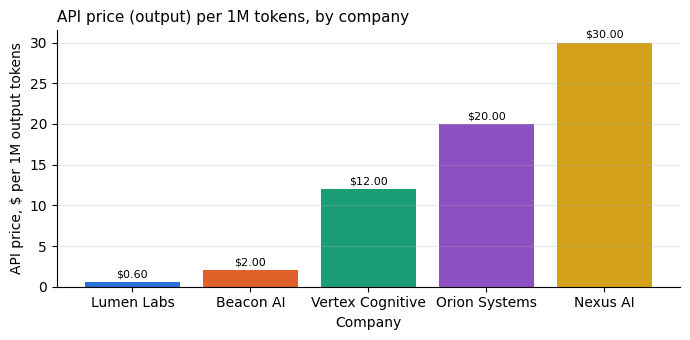

API price (output) per 1M tokens, by company -> chart_1
Cheapest: Lumen Labs ($0.60/1M output); most expensive: Nexus AI ($30.00/1M output).

3) Positioning map


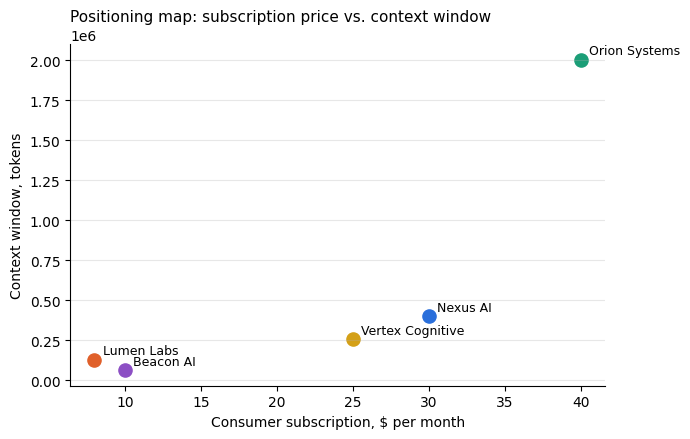

Positioning map: subscription price vs. context window -> chart_2
Nexus AI: $30/mo, 400,000 tokens; Lumen Labs: $8/mo, 128,000 tokens; Orion Systems: $40/mo, 2,000,000 tokens; Beacon AI: $10/mo, 64,000 tokens; Vertex Cognitive: $25/mo, 256,000 tokens.

4) Contradiction checks
 pricing: No contradictions or stale sources found for 'pricing'.
 positioning (should be clean): No contradictions or stale sources found for 'positioning'.


In [12]:
print("1) Price comparison table")
price_table = compare_competitors(dimension="price")
print(price_table["summary"])
for row in price_table["rows"]:
    print(f"   {row['company']:<18} in ${row['api_input_usd_1m']:>6.2f}  out ${row['api_output_usd_1m']:>6.2f}"
          f"  sub ${row['sub_usd_month']:>3}/mo   [{row['cite']}]")

print("\n2) Price chart")
chart = make_chart("price_bar")
print(chart["caption"], "->", chart["chart_id"])
print(chart["summary"])

print("\n3) Positioning map")
pos_chart = make_chart("positioning_map")
print(pos_chart["caption"], "->", pos_chart["chart_id"])
print(pos_chart["summary"])

print("\n4) Contradiction checks")
pricing_issues = find_contradictions("pricing")
print(" pricing:", pricing_issues["summary"])
for issue in pricing_issues["issues"]:
    print(f"   • {issue['description']}")

clean = find_contradictions("positioning")
print(" positioning (should be clean):", clean["summary"])

## Section 4: The Answer Key and Scorecard

Our agent is about to make claims about five competing AI companies — who is cheapest,
who has the biggest context window, who just launched. Those claims need to be **right**,
and they need to be **backed by a real source document**, not just confident-sounding.

So before we let the agent loose, we build an **answer key**: about 15 questions a
market analyst might really ask, and what a good, well-cited answer must contain. Then a
**scorecard** asks the agent every question and marks each answer PASS or FAIL — like
marking an exam.

This habit matters even more for a market-intelligence agent than for an internal reporting
one, because the temptation to "just know" a competitor's price or headcount from general
knowledge is strong, and it is exactly the kind of thing that turns out to be stale, wrong,
or completely invented. The scorecard's job is to catch that.

* **It turns "sounds right" into a number.** "13 out of 15" is something you can compare,
  share and improve after every change.
* **It checks citations, not just words.** An answer can use all the right vocabulary and
  still be ungrounded. A question that "expects a citation" only passes if the answer points
  to an actual document, shown as a `[doc-id]` tag or a citation entry.
* **It keeps the agent honest about what it doesn't know.** Some questions ask about things
  our corpus never covers — stock prices, headcount, a CEO's net worth. A good agent says so
  plainly. A bad one invents a number, and the scorecard fails it.

**The rule for the rest of the workshop:** every time you edit the system prompt, a tool
description, or a corpus knob, re-run the scorecard. Did your change help, or did it just
break a different question?

The 15 questions come in three kinds:

| category | how many | what a good answer does |
|---|---|---|
| `answerable` | 7 | Looks up one company's fact (price, context window, positioning...) and cites the source |
| `comparison` | 4 | Ranks the five companies on a headline story (cheapest, biggest context, newest, price war) and cites it |
| `not_in_corpus` | 4 | Plainly says the sources don't cover this (stock price, headcount, CEO net worth, market share) and invents no number |


### How the answer key is built

Each question checks up to three things. An answer must pass **all** of the ones that apply:

1. **Keywords.** Words the answer must mention (for example the company name). Not
   case-sensitive.
2. **A number** (only for questions that have one, e.g. a price or a context-window size).
   The answer must contain a number close enough to the true one — "close enough" is a
   generous, editable tolerance.
3. **A citation.** If the question `expects_citation`, the answer must point at a real
   document — either a `[doc-id]` tag in the text, or an entry in the `citations` list the
   agent returns. Saying the right thing without saying *where it came from* is a FAIL.
4. For `not_in_corpus` questions, instead of 1–3: the answer must clearly say the sources
   don't cover the topic, **and** must not slip in a specific number anyway.

**The expected answers are read live from `PLANTED_FACTS`, not typed in by hand.** So if a
knob in Section 1 changes who is cheapest, or switches the price war off, this answer key
updates itself the next time the notebook runs — the scorecard never goes stale.


In [13]:
import re
import pandas as pd

# ---- Phrase lists the scorer looks for (✏️ edit me if your agent phrases things differently) ----
# A "not covered" answer should use one of these. They are checked as whole-word phrases,
# lower-case, so "doesn't cover" and "Doesn't Cover" both count.
NOT_COVERED_PHRASES = [
    "not covered", "doesn't cover", "does not cover", "don't cover", "do not cover",
    "isn't covered", "is not covered",
    "not in the sources", "not in our sources", "not in the corpus", "not in our corpus",
    "no document", "no documents", "none of the documents", "no source", "no sources",
    "don't have", "do not have", "doesn't have", "does not have",
    "can't find", "cannot find", "can't answer", "cannot answer", "can't tell", "cannot tell",
    "not available", "isn't available", "is not available", "unavailable",
    "not something we track", "not tracked", "doesn't track", "does not track",
    "outside the scope", "no information", "no record", "not disclosed", "isn't disclosed",
]

# Finds numbers written in an answer, however they're formatted: "$5.00", "2,000,000",
# "40%", "2M tokens" all become plain floats so they can be compared to the expected value.
_NUM_RE = re.compile(
    r"(?<![\w.])[-\u2212]?[$\u00a3]?\s?(\d{1,3}(?:,\d{3})+|\d+)(\.\d+)?\s*(k|m|bn|million|billion|thousand)?(?![a-z])",
    re.IGNORECASE)
_SCALE = {"k": 1e3, "thousand": 1e3, "m": 1e6, "million": 1e6, "bn": 1e9, "billion": 1e9}


def _normalise(text):
    """Lower-case and straighten curly quotes/dashes so phrase matching is predictable."""
    text = str(text or "").lower()
    for a, b in {"\u2019": "'", "\u2018": "'", "\u2013": "-", "\u2014": "-", "\u2212": "-"}.items():
        text = text.replace(a, b)
    return text


def extract_numbers(text):
    """Every number written in the text, as floats. '$5.00' -> 5.0, '2,000,000' -> 2000000.0."""
    found = []
    for whole, frac, suffix in _NUM_RE.findall(_normalise(text)):
        value = float(whole.replace(",", "") + (frac or ""))
        if suffix:
            value *= _SCALE[suffix.lower()]
        found.append(value)
    return found


def _fmt_num(x):
    return f"{x:,.0f}" if abs(x) >= 1000 else f"{x:g}"


def _has_phrase(text, phrase):
    # the phrase must start at a word boundary, so "cut" matches "price cut" but not "circuit"
    return re.search(r"(?<![a-z0-9])" + re.escape(phrase.lower()), text) is not None


print("Scorer helpers ready.")


Scorer helpers ready.


In [14]:
def build_eval_set():
    """Build the answer key straight from PLANTED_FACTS, so it always matches the live corpus.

    Every expected fact below is read out of PLANTED_FACTS (not typed in by hand), so if you
    switch a knob in Section 1 -- say, turning off the price war, or changing who has the
    cheapest API -- this answer key automatically expects the new, correct answer the next
    time you run the notebook.
    """
    PF = PLANTED_FACTS
    C = PF["companies"]
    S = PF["stories"]
    NIC = PF["not_in_corpus"]
    rows = []

    def add(qid, question, category, keywords, number=None, tolerance=None,
            companies=None, expects_citation=False, why=""):
        rows.append({
            "qid": qid, "question": question, "category": category,
            "expected_keywords": [list(g) for g in keywords],
            "expected_number": number, "tolerance": tolerance,
            "expected_companies": companies, "expects_citation": expects_citation,
            "why": why,
        })

    # ---------------- answerable from corpus (7): one fact per question, spread across all 5 companies ----------------
    nexus = C["Nexus AI"]
    add("A1", "How much does Nexus AI charge for API output tokens, per million tokens?",
        "answerable", [["nexus"]], number=float(nexus["api_output_usd_1m"]), tolerance=0.5,
        companies=["Nexus AI"], expects_citation=True,
        why=f"Nexus AI charges ${nexus['api_output_usd_1m']} per 1M output tokens, stated in {nexus['cite']['price']}.")

    lumen = C["Lumen Labs"]
    add("A2", "How much does Lumen Labs charge for API input tokens, per million tokens?",
        "answerable", [["lumen"]], number=float(lumen["api_input_usd_1m"]), tolerance=0.5,
        companies=["Lumen Labs"], expects_citation=True,
        why=f"Lumen Labs charges ${lumen['api_input_usd_1m']} per 1M input tokens, stated in {lumen['cite']['price']}.")

    orion = C["Orion Systems"]
    add("A3", "What is Orion Systems' context window size, in tokens?",
        "answerable", [["orion"]], number=float(orion["context_window"]),
        tolerance=max(1000.0, 0.02 * orion["context_window"]),
        companies=["Orion Systems"], expects_citation=True,
        why=f"Orion Systems advertises a {orion['context_window']:,}-token context window, stated in {orion['cite']['product']}.")

    beacon = C["Beacon AI"]
    add("A4", "How much does Beacon AI's consumer subscription cost per month?",
        "answerable", [["beacon"]], number=float(beacon["sub_usd_month"]), tolerance=2.0,
        companies=["Beacon AI"], expects_citation=True,
        why=f"Beacon AI's consumer plan is ${beacon['sub_usd_month']}/month, stated in {beacon['cite']['price']}.")

    add("A5", "What market segment does Orion Systems target, and what is its headline claim?",
        "answerable", [["orion"], [orion["segment"].split("/")[0].lower()]], number=None, tolerance=None,
        companies=["Orion Systems"], expects_citation=True,
        why=f"Orion Systems targets {orion['segment']}, stated in {orion['cite']['positioning']}.")

    vertex = C["Vertex Cognitive"]
    add("A6", "What is Vertex Cognitive's flagship model called?",
        "answerable", [["vertex"], [vertex["model"].lower()]], number=None, tolerance=None,
        companies=["Vertex Cognitive"], expects_citation=True,
        why=f"Vertex Cognitive's flagship model is {vertex['model']}, stated in {vertex['cite']['product']}.")

    add("A7", "What is Nexus AI's standout product feature?",
        "answerable", [["nexus"], [" ".join(nexus["key_feature"].split()[:2]).lower()]],
        number=None, tolerance=None,
        companies=["Nexus AI"], expects_citation=True,
        why=f"Nexus AI's standout feature: {nexus['key_feature']}, stated in {nexus['cite']['product']}.")

    # ---------------- comparison / ranking (4), tied to PLANTED_FACTS["stories"] ----------------
    cheapest = S["cheapest_api"]
    add("C1", "Which company has the cheapest API pricing?",
        "comparison", [[cheapest["answer"].lower()]], number=None, tolerance=None,
        companies=[cheapest["answer"]], expects_citation=True,
        why=f"{cheapest['answer']} has the cheapest API pricing, stated in {cheapest['cite']}.")

    largest = S["largest_context"]
    add("C2", "Which company offers the largest context window, and how large is it?",
        "comparison", [[largest["answer"].lower()]],
        number=float(largest["value"]) if largest.get("value") is not None else None,
        tolerance=max(1000.0, 0.02 * largest["value"]) if largest.get("value") is not None else None,
        companies=[largest["answer"]], expects_citation=True,
        why=f"{largest['answer']} has the largest context window, stated in {largest['cite']}.")

    newest = S["newest_entrant"]
    add("C3", "Which company is the newest entrant to the market?",
        "comparison", [[newest["answer"].lower()]], number=None, tolerance=None,
        companies=[newest["answer"]], expects_citation=True,
        why=f"{newest['answer']} is the newest entrant, stated in {newest['cite']}.")

    pw = S["price_war"]
    # Work out which of the 5 binding company names is the subject of the price-war story,
    # rather than hard-coding "Lumen Labs" -- so this still works if a knob ever changes it.
    pw_company = next((name for name in C if name.lower() in pw["answer"].lower()), None)
    cut_words = ["cut", "slash", "reduce", "lower", "discount", "drop"]
    add("C4", "Is there a price war happening in the API market, and who started it?",
        "comparison", [[pw_company.lower()] if pw_company else ["price war"], cut_words],
        number=None, tolerance=None,
        companies=[pw_company] if pw_company else None, expects_citation=True,
        why=f"{pw['answer']}, stated in {pw['cite']}.")

    # ---------------- not in corpus (4), drawn from PLANTED_FACTS["not_in_corpus"] ----------------
    def _topic(substr):
        return next((t for t in NIC if substr in t.lower()), substr)

    add("X1", "What is Nexus AI's current stock price or market valuation?",
        "not_in_corpus", [], number=None, tolerance=None, companies=["Nexus AI"], expects_citation=False,
        why=f"'{_topic('stock')}' is on the not-in-corpus list -- no document reports it.")

    add("X2", "How many employees does Lumen Labs have?",
        "not_in_corpus", [], number=None, tolerance=None, companies=["Lumen Labs"], expects_citation=False,
        why=f"'{_topic('employee')}' is on the not-in-corpus list.")

    add("X3", "What is the net worth of Orion Systems' founder or CEO?",
        "not_in_corpus", [], number=None, tolerance=None, companies=["Orion Systems"], expects_citation=False,
        why=f"'{_topic('net worth')}' is on the not-in-corpus list.")

    add("X4", "What market share percentage does Beacon AI hold in the consumer AI assistant market?",
        "not_in_corpus", [], number=None, tolerance=None, companies=["Beacon AI"], expects_citation=False,
        why=f"'{_topic('market share')}' is on the not-in-corpus list.")

    return pd.DataFrame(rows)


eval_df = build_eval_set()
print(f"Answer key ready: {len(eval_df)} questions")
print(eval_df.groupby("category").size().to_string())
try:
    display(eval_df[["qid", "category", "question", "why"]].style.set_properties(**{"text-align": "left"}))
except NameError:
    print(eval_df[["qid", "category", "question"]].to_string())


Answer key ready: 15 questions
category
answerable       7
comparison       4
not_in_corpus    4


,qid,category,question,why
0,A1,answerable,"How much does Nexus AI charge for API output tokens, per million tokens?","Nexus AI charges $30.0 per 1M output tokens, stated in nexus-pricing-01."
1,A2,answerable,"How much does Lumen Labs charge for API input tokens, per million tokens?","Lumen Labs charges $0.15 per 1M input tokens, stated in lumen-pricing-01."
2,A3,answerable,"What is Orion Systems' context window size, in tokens?","Orion Systems advertises a 2,000,000-token context window, stated in orion-product-01."
3,A4,answerable,How much does Beacon AI's consumer subscription cost per month?,"Beacon AI's consumer plan is $10/month, stated in beacon-pricing-01."
4,A5,answerable,"What market segment does Orion Systems target, and what is its headline claim?","Orion Systems targets Enterprise, stated in orion-product-01."
5,A6,answerable,What is Vertex Cognitive's flagship model called?,"Vertex Cognitive's flagship model is Vertex-Reason, stated in vertex-product-01."
6,A7,answerable,What is Nexus AI's standout product feature?,"Nexus AI's standout feature: top benchmark scores across reasoning, coding, and multimodal tasks, stated in nexus-product-01."
7,C1,comparison,Which company has the cheapest API pricing?,"Lumen Labs has the cheapest API pricing, stated in lumen-pricing-01."
8,C2,comparison,"Which company offers the largest context window, and how large is it?","Orion Systems has the largest context window, stated in orion-product-01."
9,C3,comparison,Which company is the newest entrant to the market?,"Vertex Cognitive is the newest entrant, stated in vertex-press-01."


### How an answer is marked

`score_answer` is the "examiner". It is deliberately simple so you can read it and argue with
it. Given one question from the answer key and the agent's reply, it:

* looks for each required **keyword** in the answer (case doesn't matter);
* finds **every number** written in the answer -- "$5.00", "2,000,000" and "40%" are all
  understood -- and passes if any one of them is close enough to the expected value;
* for a question that `expects_citation`, checks that the answer actually points at a real
  document: either a `citations` entry with a `doc_id`, or a `[doc-id]` tag written into the
  text itself. Getting the fact right without saying where it came from is a FAIL;
* for a `not_in_corpus` question, instead checks that the answer clearly refuses ("the
  sources don't cover this") **and** contains no specific number hiding in the refusal.

It returns PASS or FAIL plus a list of plain-English reasons, so you can always see *why*.


In [15]:
def _real_doc_ids():
    """The set of doc_ids that actually exist in the corpus, if Story 1's CORPUS is loaded."""
    try:
        return {d["doc_id"] for d in CORPUS}
    except NameError:
        return None  # CORPUS not loaded yet (e.g. running this section on its own) -- don't over-check


def _has_valid_citation(result, answer_norm):
    """True if the answer cites a real doc_id, either in result['citations'] or as a [doc-id] tag."""
    doc_ids = _real_doc_ids()
    for c in (result.get("citations") or []):
        if isinstance(c, dict) and c.get("doc_id"):
            if doc_ids is None or c["doc_id"] in doc_ids:
                return True, c["doc_id"]
    for doc_id in re.findall(r"\[([a-z0-9]+(?:-[a-z0-9]+)+)\]", answer_norm):
        if doc_ids is None or doc_id in doc_ids:
            return True, doc_id
    return False, None


def score_answer(row, result):
    """Mark one answer. Returns (passed, reasons). `row` is one row of eval_df; `result` is
    agent_fn's output: {"answer": str, "tool_trace": [...], "citations": [...]}."""
    answer = _normalise(result.get("answer", ""))
    fails, notes = [], []

    if not answer.strip():
        return False, ["the agent gave an empty answer"]

    # ---- not-in-corpus questions: must refuse, and must not sneak in a number ----
    if row["category"] == "not_in_corpus":
        if any(_has_phrase(answer, p) for p in NOT_COVERED_PHRASES):
            notes.append("clearly says the sources don't cover this")
        else:
            fails.append("does not clearly say this isn't covered by the corpus")

        # look for a fabricated number outside of any "we don't cover this" sentence, so an
        # honest "we don't track headcount, but we do have 5 pricing docs" isn't punished
        leaked = []
        for sentence in re.split(r"(?<=[.!?])\s+|\n+", answer):
            if any(_has_phrase(sentence, p) for p in NOT_COVERED_PHRASES):
                continue
            leaked += extract_numbers(sentence)
        if leaked:
            fails.append("states a specific figure it shouldn't know: " +
                         ", ".join(_fmt_num(n) for n in leaked[:5]))
        else:
            notes.append("no fabricated number")

        if fails:
            return False, fails
        return True, ["all checks passed: " + "; ".join(notes)]

    # ---- answerable / comparison questions ----
    for group in row["expected_keywords"]:
        hit = next((p for p in group if _has_phrase(answer, p.lower())), None)
        if hit:
            notes.append(f"mentions '{hit}'")
        else:
            shown = " / ".join(group[:6])
            fails.append(f"missing a keyword: needs one of [{shown}]")

    if pd.notna(row.get("expected_number")):
        tol = row.get("tolerance") if pd.notna(row.get("tolerance")) else 0.5
        found = extract_numbers(answer)
        match = next((n for n in found if abs(abs(n) - abs(row["expected_number"])) <= tol), None)
        if match is not None:
            notes.append(f"number {_fmt_num(match)} matches expected {_fmt_num(row['expected_number'])}")
        else:
            had = ", ".join(_fmt_num(n) for n in found[:8]) or "no numbers"
            fails.append(f"no correct number: expected {_fmt_num(row['expected_number'])} "
                         f"(+/-{_fmt_num(tol)}); answer had {had}")

    if row.get("expects_citation"):
        ok, doc_id = _has_valid_citation(result, answer)
        if ok:
            notes.append(f"cites {doc_id}")
        else:
            fails.append("no citation to a real source document")

    if fails:
        return False, fails
    return True, ["all checks passed: " + "; ".join(notes)]


print("score_answer ready.")


score_answer ready.


### The scorecard: `run_eval`

`run_eval(agent_fn)` asks the agent every question in the answer key, marks each answer with
`score_answer`, and prints a table.

* `agent_fn` is any function that takes a question and returns
  `{"answer": ..., "tool_trace": [...], "citations": [...]}`. The real agent in Section 5 has
  exactly this shape.
* If the agent crashes on a question (for example a rate-limit error from a free API), that
  question counts as a FAIL and the error is shown as the reason. The rest still run.
* Run just a few questions while you're iterating with `run_eval(agent_fn, qids=["A1", "X1"])`.


In [16]:
def run_eval(agent_fn, qids=None, verbose=True):
    """Ask agent_fn every question in eval_df, mark each answer, print and return the scorecard."""
    key = eval_df if qids is None else eval_df[eval_df["qid"].isin(list(qids))]
    records = []
    for _, row in key.iterrows():
        try:
            result = agent_fn(row["question"])
            if not isinstance(result, dict):
                result = {"answer": str(result), "tool_trace": [], "citations": []}
            passed, reasons = score_answer(row, result)
        except Exception as e:  # a crash is a fail, with the error as the reason
            result = {"answer": "", "tool_trace": [], "citations": []}
            passed, reasons = False, [f"agent crashed: {type(e).__name__}: {str(e)[:200]}"]
        records.append({"qid": row["qid"], "category": row["category"], "passed": passed,
                        "reasons": reasons, "question": row["question"],
                        "answer": str(result.get("answer", ""))})
        if verbose:
            print(f"{'PASS' if passed else 'FAIL'}  {row['qid']:<3} {row['question']}")
            for r in reasons:
                print(f"      -> {r}")

    results_df = pd.DataFrame(records, columns=["qid", "category", "passed", "reasons", "question", "answer"])
    passed = int(results_df["passed"].sum())
    total = int(len(results_df))
    pass_rate = round(passed / total, 3) if total else 0.0
    if verbose:
        print("\n" + "=" * 70)
        print(f"SCORE: {passed}/{total} passed ({pass_rate:.0%})")
        for c in ["answerable", "comparison", "not_in_corpus"]:
            sub = results_df[results_df["category"] == c]
            if len(sub):
                print(f"   {c:<14} {int(sub['passed'].sum())}/{len(sub)}")
        print("=" * 70)
        try:
            display(results_df[["qid", "category", "passed", "reasons"]])
        except NameError:
            print(results_df[["qid", "category", "passed", "reasons"]].to_string())
    return {"passed": passed, "total": total, "pass_rate": pass_rate, "results_df": results_df}


print("run_eval ready.")


run_eval ready.


### Proving the answer key is fair: a "perfect analyst"

Before we mark the AI agent, we should check that the exam can actually be passed. Below is a
hand-written **oracle**: a plain Python function, with no AI at all, that answers each
question by calling the real Section 2/3 tools directly (`read_document`,
`compare_competitors`, `get_corpus_overview`, ...) and reading `PLANTED_FACTS` for the ground
truth, then fills the numbers into a fixed, cited sentence.

If the oracle scores 15/15, we know every question is answerable with real citations, and any
mark the AI agent loses later is the agent's fault, not the answer key's.

One safety detail: the oracle calls the Story 2/3 tools **defensively**. If a tool it wants
isn't available yet (for example, if you run this section by itself before wiring the rest of
the notebook together), it quietly falls back to `PLANTED_FACTS` instead of crashing --
`run_eval` should never blow up just because a tool is missing.


In [17]:
def _get_tool(name):
    return globals().get(name)


def _safe_call(name, trace, **kwargs):
    """Call a Story 2/3 tool by name if it exists; log it to the trace; NEVER raise.
    Returns None if the tool is missing or errors, so callers can fall back to PLANTED_FACTS."""
    fn = _get_tool(name)
    if fn is None:
        return None
    try:
        result = fn(**kwargs)
        trace.append({"tool": name, "args": kwargs, "result": result})
        return result
    except Exception as e:
        trace.append({"tool": name, "args": kwargs, "result": {"error": str(e)}})
        return None


def _cite_for(doc_id, company, source_type, trace):
    """Best citation available for doc_id: real metadata from read_document() if that tool
    exists, otherwise a minimal citation built straight from PLANTED_FACTS."""
    doc = _safe_call("read_document", trace, doc_id=doc_id)
    if isinstance(doc, dict) and "error" not in doc and doc.get("doc_id"):
        return {"doc_id": doc["doc_id"], "company": doc.get("company", company),
                "source_type": doc.get("source_type", source_type),
                "url": doc.get("url", ""), "date": doc.get("date", ""),
                "snippet": str(doc.get("text", ""))[:200]}
    return {"doc_id": doc_id, "company": company, "source_type": source_type,
            "url": "", "date": "", "snippet": ""}


def oracle_agent_fn(question):
    """A hand-written, non-AI 'perfect analyst'. Calls the real tools when they exist and
    always cites a real doc_id; degrades to PLANTED_FACTS alone if a tool isn't wired up yet."""
    trace = []
    qid_lookup = dict(zip(eval_df["question"], eval_df["qid"]))
    qid = qid_lookup.get(question)

    def done(text, citations):
        return {"answer": text, "tool_trace": trace, "citations": citations}

    PF = PLANTED_FACTS
    C = PF["companies"]
    S = PF["stories"]

    if qid == "A1":
        co, f = "Nexus AI", C["Nexus AI"]
        doc_id = f["cite"]["price"]
        cit = _cite_for(doc_id, co, "pricing", trace)
        return done(f"{co}'s API costs ${f['api_input_usd_1m']:.2f} per 1M input tokens and "
                    f"${f['api_output_usd_1m']:.2f} per 1M output tokens [{doc_id}].", [cit])

    if qid == "A2":
        co, f = "Lumen Labs", C["Lumen Labs"]
        doc_id = f["cite"]["price"]
        cit = _cite_for(doc_id, co, "pricing", trace)
        return done(f"{co}'s API costs ${f['api_input_usd_1m']:.2f} per 1M input tokens [{doc_id}].", [cit])

    if qid == "A3":
        co, f = "Orion Systems", C["Orion Systems"]
        doc_id = f["cite"]["product"]
        cit = _cite_for(doc_id, co, "product", trace)
        return done(f"{co}'s context window is {f['context_window']:,} tokens [{doc_id}].", [cit])

    if qid == "A4":
        co, f = "Beacon AI", C["Beacon AI"]
        doc_id = f["cite"]["price"]
        cit = _cite_for(doc_id, co, "pricing", trace)
        return done(f"{co}'s consumer subscription is ${f['sub_usd_month']:.0f}/month [{doc_id}].", [cit])

    if qid == "A5":
        co, f = "Orion Systems", C["Orion Systems"]
        doc_id = f["cite"]["positioning"]
        cit = _cite_for(doc_id, co, "analyst_note", trace)
        return done(f'{co} targets the {f["segment"]} segment: "{f["claim"]}" [{doc_id}].', [cit])

    if qid == "A6":
        co, f = "Vertex Cognitive", C["Vertex Cognitive"]
        doc_id = f["cite"]["product"]
        cit = _cite_for(doc_id, co, "product", trace)
        return done(f"{co}'s flagship model is {f['model']} [{doc_id}].", [cit])

    if qid == "A7":
        co, f = "Nexus AI", C["Nexus AI"]
        doc_id = f["cite"]["product"]
        cit = _cite_for(doc_id, co, "product", trace)
        return done(f"{co}'s standout feature is {f['key_feature']} [{doc_id}].", [cit])

    if qid == "C1":
        story = S["cheapest_api"]
        _safe_call("compare_competitors", trace, dimension="price")
        cit = _cite_for(story["cite"], story["answer"], "pricing", trace)
        return done(f"{story['answer']} has the cheapest API pricing of the five companies "
                    f"[{story['cite']}].", [cit])

    if qid == "C2":
        story = S["largest_context"]
        _safe_call("compare_competitors", trace, dimension="products")
        cit = _cite_for(story["cite"], story["answer"], "product", trace)
        val = story.get("value")
        val_txt = f", at {val:,} tokens" if val is not None else ""
        return done(f"{story['answer']} offers the largest context window{val_txt} [{story['cite']}].", [cit])

    if qid == "C3":
        story = S["newest_entrant"]
        cit = _cite_for(story["cite"], story["answer"], "press_release", trace)
        return done(f"{story['answer']} is the newest entrant to the market [{story['cite']}].", [cit])

    if qid == "C4":
        story = S["price_war"]
        cit = _cite_for(story["cite"], None, "press_release", trace)
        return done(f"Yes: {story['answer']} [{story['cite']}].", [cit])

    if qid in ("X1", "X2", "X3", "X4"):
        topic_by_qid = {
            "X1": "stock prices or valuations", "X2": "employee headcount",
            "X3": "founder or CEO net worth", "X4": "market share percentages",
        }
        _safe_call("get_corpus_overview", trace)
        return done("Our sources don't cover " + topic_by_qid.get(qid, "that") +
                    " -- none of the pricing, product, press-release, review or analyst "
                    "documents in this corpus report it, so I can't give you a number here.", [])

    return done("I don't have a recipe for that question.", [])


oracle_report = run_eval(oracle_agent_fn)


PASS  A1  How much does Nexus AI charge for API output tokens, per million tokens?
      -> all checks passed: mentions 'nexus'; number 30 matches expected 30; cites nexus-pricing-01
PASS  A2  How much does Lumen Labs charge for API input tokens, per million tokens?
      -> all checks passed: mentions 'lumen'; number 0.15 matches expected 0.15; cites lumen-pricing-01
PASS  A3  What is Orion Systems' context window size, in tokens?
      -> all checks passed: mentions 'orion'; number 2,000,000 matches expected 2,000,000; cites orion-product-01
PASS  A4  How much does Beacon AI's consumer subscription cost per month?
      -> all checks passed: mentions 'beacon'; number 10 matches expected 10; cites beacon-pricing-01
PASS  A5  What market segment does Orion Systems target, and what is its headline claim?
      -> all checks passed: mentions 'orion'; mentions 'enterprise'; cites orion-product-01
PASS  A6  What is Vertex Cognitive's flagship model called?
      -> all checks passed: menti

,qid,category,passed,reasons
0,A1,answerable,True,[all checks passed: mentions 'nexus'; number 3...
1,A2,answerable,True,[all checks passed: mentions 'lumen'; number 0...
2,A3,answerable,True,[all checks passed: mentions 'orion'; number 2...
3,A4,answerable,True,[all checks passed: mentions 'beacon'; number ...
4,A5,answerable,True,[all checks passed: mentions 'orion'; mentions...
5,A6,answerable,True,[all checks passed: mentions 'vertex'; mention...
6,A7,answerable,True,[all checks passed: mentions 'nexus'; mentions...
7,C1,comparison,True,[all checks passed: mentions 'lumen labs'; cit...
8,C2,comparison,True,[all checks passed: mentions 'orion systems'; ...
9,C3,comparison,True,[all checks passed: mentions 'vertex cognitive...


### What a failing answer looks like

A score is only useful if a bad answer actually fails. Here are three deliberately bad
answers, marked by the same examiner:

1. A confident-sounding price for Nexus AI that is simply **made up**, with no citation.
2. The *right* number for Beacon AI's subscription, but with **no citation at all**.
3. A confident, specific **stock price for Nexus AI** -- a question our corpus was never
   meant to cover.

Read the reasons: they tell you exactly what was wrong.


In [18]:
_bad_examples = [
    ("A1", {"answer": "Nexus AI charges about $99.00 per 1M output tokens.",
            "tool_trace": [], "citations": []}),
    ("A4", {"answer": "Beacon AI's subscription is $10/month.",
            "tool_trace": [], "citations": []}),
    ("X1", {"answer": "Nexus AI's stock price is $187.42 as of today.",
            "tool_trace": [], "citations": []}),
]
for qid, bad in _bad_examples:
    row = eval_df.set_index("qid").loc[qid].copy()
    row["qid"] = qid
    ok, reasons = score_answer(row, bad)
    print(f"{qid}: {row['question']}")
    print(f"   answer: {bad['answer']}")
    print(f"   {'PASS' if ok else 'FAIL'}")
    for r in reasons:
        print(f"      -> {r}")
    print()


A1: How much does Nexus AI charge for API output tokens, per million tokens?
   answer: Nexus AI charges about $99.00 per 1M output tokens.
   FAIL
      -> no correct number: expected 30 (+/-0.5); answer had 99, 1,000,000
      -> no citation to a real source document

A4: How much does Beacon AI's consumer subscription cost per month?
   answer: Beacon AI's subscription is $10/month.
   FAIL
      -> no citation to a real source document

X1: What is Nexus AI's current stock price or market valuation?
   answer: Nexus AI's stock price is $187.42 as of today.
   FAIL
      -> does not clearly say this isn't covered by the corpus
      -> states a specific figure it shouldn't know: 187.42



## Section 5: The Agent, the Cited Briefing, and the Chat App

This is where everything comes together. Sections 1-4 built the knowledge base, the
search/read/web tools, the comparison/chart tools, and the exam that grades the whole
system. This section builds the **analyst itself**: an AI that decides, on its own, which
tools to use and in what order to answer a question -- and that must back up every number
or claim it states with a citation to a real source document, like `[nexus-pricing-01]`.

You'll get:
- a genuine tool-calling agent loop (works with either Groq or Gemini),
- `ask("your question")` to watch it work and read its cited answer,
- `competitor_briefing()`, a one-page leadership briefing with a price table, charts, and
  a full source list,
- a polished chat app you can click around in,
- and, at the very end, the exam from Section 4 scored against this agent.


### 5.1 Install the AI connectors

This installs the small libraries that let the notebook talk to the two AI providers we
support: **Groq** and **Google Gemini**. It also installs `ipywidgets`, which the chat app
in 5.12 needs. It takes a few seconds and only needs to run once per session.

In [19]:
!pip install -q groq google-genai ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 63.1 MB/s eta 0:00:00


### 5.2 ✏️ Edit me: which AI to use, and how chatty it should be

- `PROVIDER` picks the AI. `"groq"` is the default and is the one we tested. Switch to
  `"gemini"` if you have a Gemini key instead.
- `MAX_ITERATIONS` is a safety limit: how many rounds of tool calls the agent may make for
  one question before it must answer with whatever it has found so far.
- `SHOW_THINKING = True` prints every tool call and a short preview of its result as the
  agent works. Set it to `False` to see only the final answer.

In [22]:
import os, json, re, time, math, html, io, contextlib, base64
from datetime import date

PROVIDER = "gemini"            # "groq" or "gemini"

GROQ_MODEL = "openai/gpt-oss-20b"      # free tier, native tool calling. Free plan: ~8,000 tokens per
                                       # MINUTE and 200,000 per DAY. If you use up the daily allowance,
                                       # "openai/gpt-oss-120b" has its own separate daily allowance.
GEMINI_MODEL = "gemini-3.5-flash-lite" # Gemini's "lite" models have a usable free tier. The alias
                                       # "gemini-flash-latest" (currently gemini-3.8-flash) is smarter but its
                                       # free tier allows only 20 requests PER DAY: one scorecard run uses more.

MAX_ITERATIONS = 8           # max rounds of tool calls per question
SHOW_THINKING = True         # print each tool call and a preview of its result
TEMPERATURE = 0.2            # low = more consistent, source-grounded answers

print(f"Provider: {PROVIDER} | model: {GROQ_MODEL if PROVIDER == 'groq' else GEMINI_MODEL}")

Provider: gemini | model: gemini-3.5-flash-lite


### 5.3 Your API key

The AI provider needs a key (like a password). This cell looks for it in three places, in
order: an environment variable, **Colab Secrets** (the 🔑 icon in the left sidebar --
add `GROQ_API_KEY` or `GEMINI_API_KEY` there), and finally a hidden prompt where you can
paste it. The key is never printed.

In [23]:
def _get_api_key(env_var_name, prompt_label):
    """Find an API key: environment variable -> Colab Secrets -> hidden prompt. Never raises."""
    key = os.environ.get(env_var_name)
    if key:
        return key
    try:
        from google.colab import userdata  # only exists inside Colab
        key = userdata.get(env_var_name)
        if key:
            return key
    except Exception:
        pass
    try:
        import getpass
        return getpass.getpass(f"Paste your {prompt_label} (or press Enter to skip): ") or None
    except Exception:
        return None


_KEY_NAMES = {"groq": ("GROQ_API_KEY", "Groq API key"), "gemini": ("GEMINI_API_KEY", "Gemini API key")}
GROQ_API_KEY = _get_api_key(*_KEY_NAMES["groq"]) if PROVIDER == "groq" else os.environ.get("GROQ_API_KEY")
GEMINI_API_KEY = _get_api_key(*_KEY_NAMES["gemini"]) if PROVIDER == "gemini" else os.environ.get("GEMINI_API_KEY")
_active_key = GROQ_API_KEY if PROVIDER == "groq" else GEMINI_API_KEY
print(f"{_KEY_NAMES[PROVIDER][0]}: {'found' if _active_key else 'NOT found - the agent cells below will not work'}")

Paste your Gemini API key (or press Enter to skip): ··········
GEMINI_API_KEY: found


### 5.4 The agent's toolbox

This gathers the eight tools from Sections 2 and 3 into one toolbox:

| tool | what it does |
|---|---|
| `get_corpus_overview` | lists what's in the knowledge base (companies, source types, dates) |
| `search_documents` | keyword-searches the knowledge base and returns cited snippets |
| `read_document` | reads one document in full, by its `doc_id` |
| `web_search` | an optional live web search (falls back to the offline corpus if it's switched off) |
| `compare_competitors` | a structured head-to-head table on price, products, or positioning |
| `extract_pricing` | a detailed, cited pricing breakdown |
| `find_contradictions` | flags places where sources disagree or one is stale |
| `make_chart` | draws a chart (price, context window, or a price-vs-context map) |

`_run_tool` is the "switchboard": when the AI asks for a tool, this runs the real Python
function and hands back the result. If anything goes wrong it returns an error message
instead of crashing, so the AI can correct itself.

The AI only sees a **shortened** copy of each result (long lists trimmed, chart pictures
never sent as text). This keeps each request small, which matters because free AI plans
limit how much text you can send per minute. The **full** result -- including every
citation -- is always kept in the tool trace, which is what `agent_fn` reads to build the
final source list.

In [24]:
TOOL_SCHEMAS = RETRIEVAL_TOOL_SCHEMAS + COMPARISON_TOOL_SCHEMAS

# Maps each tool name the AI can call to the real Python function that does the work.
# These functions were defined in Sections 2 (retrieval) and 3 (comparison/charts).
TOOLS = {
    "get_corpus_overview": get_corpus_overview,
    "search_documents": search_documents,
    "read_document": read_document,
    "web_search": web_search,
    "compare_competitors": compare_competitors,
    "extract_pricing": extract_pricing,
    "find_contradictions": find_contradictions,
    "make_chart": make_chart,
}
print("Tools the agent can use:", ", ".join(TOOLS))


def _clean_args(args):
    """Tidy what the AI sends: drop empty/None/'none' values so tools see clean kwargs."""
    out = {}
    for k, v in (args or {}).items():
        if isinstance(v, str) and v.strip().lower() in ("none", "null", ""):
            continue
        if v in (None, "", [], {}):
            continue
        out[k] = v
    return out


@contextlib.contextmanager
def _charts_not_shown_yet():
    """make_chart normally draws the chart straight away. During an agent run we hold it back and
    show all charts together under the answer instead, so the output reads in order."""
    real_show = None
    try:
        import matplotlib.pyplot as plt
        real_show = plt.show
        plt.show = lambda *a, **k: None
    except Exception:
        pass
    try:
        yield
    finally:
        if real_show is not None:
            plt.show = real_show


def _run_tool(name, args):
    """Run one tool by name. Always returns a dict (an error dict if something goes wrong)."""
    fn = TOOLS.get(name)
    if fn is None:
        return {"error": f"There is no tool called '{name}'.", "available": list(TOOLS)}
    try:
        with _charts_not_shown_yet():
            result = fn(**_clean_args(args))
        return result if isinstance(result, dict) else {"result": result}
    except TypeError as exc:
        return {"error": f"Wrong arguments for {name}: {exc}"}
    except Exception as exc:
        return {"error": f"{name} failed: {exc}"}


def _compact_for_llm(name, result, max_chars=1800):
    """A shorter copy of a tool result for the AI to read (the full result -- and every
    citation in it -- stays in the trace, which is what the source list is built from)."""
    if not isinstance(result, dict) or "error" in result:
        return result
    r = json.loads(json.dumps(result, default=str))   # also strips numpy types
    r.pop("png_base64", None)
    if name == "read_document" and isinstance(r.get("text"), str) and len(r["text"]) > 1000:
        r["text"] = r["text"][:1000] + "..."
        r["note"] = "text truncated for the AI's context window - the full text is in the tool trace"
    text = json.dumps(r)
    if len(text) > max_chars:
        if isinstance(r.get("results"), list):
            r["results"] = r["results"][:4]
            r["note"] = "results trimmed to save space - call search_documents again with a narrower query for more"
        elif isinstance(r.get("rows"), list):
            r["rows"] = r["rows"][:6]
            r["note"] = "rows trimmed to save space"
        elif isinstance(r.get("issues"), list):
            r["issues"] = r["issues"][:6]
    return r


def _preview(name, result, width=220):
    """One readable line describing a tool result, for the live trace."""
    if not isinstance(result, dict):
        text = str(result)
    elif "error" in result:
        text = "ERROR: " + str(result["error"])
    elif name == "get_corpus_overview":
        text = (f"{result.get('n_docs', '?')} docs, {len(result.get('companies', []) or [])} companies, "
                f"live_search={result.get('live_search_enabled')}")
    elif name in ("search_documents", "web_search"):
        hits = result.get("results", [])
        text = f"{len(hits)} result(s)"
        if hits:
            text += f"; top: {hits[0].get('title', '?')} [{hits[0].get('doc_id', '?')}]"
        if result.get("note"):
            text += f" | {result['note']}"
    elif name == "read_document":
        text = f"{result.get('title', '?')} - {result.get('company', '?')} ({result.get('date', '?')})"
    elif name == "compare_competitors":
        text = str(result.get("summary", ""))
    elif name == "extract_pricing":
        text = f"{len(result.get('rows', []))} pricing row(s)"
    elif name == "find_contradictions":
        issues = result.get("issues", [])
        text = f"{len(issues)} issue(s) found" if issues else "no contradictions found"
    elif name == "make_chart":
        text = (f"[{result['chart_id']}] " if "chart_id" in result else "") + str(result.get("summary", result.get("caption", "")))
    else:
        text = json.dumps(result, default=str)
    return text if len(text) <= width else text[: width - 3] + "..."


import threading
_STEP_LISTENERS = {}   # the chat app in 5.12 listens here, so it can show each step live


def _show_step(step, name, args, result):
    listener = _STEP_LISTENERS.get(threading.get_ident())
    if listener:            # this run was started from the app: send the step to the app window
        listener(step, name, args, result)
        return
    if SHOW_THINKING:
        arg_text = ", ".join(f"{k}={v!r}" for k, v in _clean_args(args).items())
        print(f"  Step {step}: {name}({arg_text})")
        print(f"     -> {_preview(name, result)}")


# Quick self-test (no AI involved): run one tool through the switchboard.
_r = _run_tool("search_documents", {"query": "cheapest API pricing"})
_show_step(0, "search_documents", {"query": "cheapest API pricing"}, _r)

Tools the agent can use: get_corpus_overview, search_documents, read_document, web_search, compare_competitors, extract_pricing, find_contradictions, make_chart
  Step 0: search_documents(query='cheapest API pricing')
     -> 5 result(s); top: The Frontier-AI Market in 2026: A Landscape Overview [market-overview-01]


In [35]:
# ==== Brief-completion tools: fetch_page, extract_facts, cite ====
# Paste as ONE new cell directly AFTER the 5.4 "agent's toolbox" cell.

import urllib.request
from datetime import date as _date


# --- Tool: fetch_page(url) -- "Reads a web page" ---
def fetch_page(url, max_chars=2000):
    """Fetch one web page and return its readable text, date-stamped. Never raises."""
    try:
        max_chars = max(200, min(int(max_chars), 6000))
    except Exception:
        max_chars = 2000
    url = str(url or "").strip()
    if not url.startswith(("http://", "https://")):
        return {"error": f"'{url}' is not a http(s) URL."}
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "MarketIntelAgent/1.0 (workshop demo)"})
        with urllib.request.urlopen(req, timeout=6) as resp:
            raw = resp.read(400_000).decode("utf-8", errors="ignore")
    except Exception as e:
        return {"error": f"Could not fetch {url}: {e}",
                "note": "Page may be offline, blocked, or behind a login (we do not scrape logins). "
                        "Use search_documents instead."}
    body = re.sub(r"(?is)<(script|style|nav|footer|header)[^>]*>.*?</\1>", " ", raw)
    text = re.sub(r"<[^>]+>", " ", body)
    text = re.sub(r"&[a-z]+;|&#\d+;", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    if not text:
        return {"error": f"{url} returned no readable text."}
    truncated = len(text) > max_chars
    fetched = _date.today().isoformat()
    return {"url": url, "fetched_on": fetched,
            "text": text[:max_chars] + ("..." if truncated else ""),
            "citations": [{"doc_id": url, "company": None, "source_type": "web_page",
                           "url": url, "date": fetched, "snippet": _snippet(text)}],
            "note": "Live web page, fetched just now - not from the offline corpus."}


# --- Tool: extract_facts(text, schema) -- "Structured competitor facts" ---
_FIELD_SYNONYMS = {
    "price": ["price", "pricing", "cost", "costs", "$", "per million", "per token"],
    "context_window": ["context window", "context", "token window"],
    "positioning": ["position", "positioning", "aimed at", "built for", "target"],
    "product": ["model", "product", "flagship"],
    "subscription": ["subscription", "per month", "/month", "plan", "free tier"],
}


def extract_facts(text, schema=None):
    """Pull requested fields out of a block of text into a structured dict.

    `schema` is a list of field names, e.g. ["price", "context_window", "positioning"].
    Every fact comes back with the exact sentence it came from, and anything NOT found
    is listed in `missing` -- that is the evidence-gap signal the briefing flags.
    """
    schema = schema or ["price", "context_window", "positioning"]
    if isinstance(schema, str):
        schema = [s.strip() for s in schema.split(",") if s.strip()]
    text = re.sub(r"\s+", " ", str(text or "")).strip()
    if not text:
        return {"error": "No text was given to extract facts from."}
    sentences = re.split(r"(?<=[.!?])\s+", text)
    facts, missing = {}, []
    for field in schema:
        key = str(field).lower().strip()
        terms = _FIELD_SYNONYMS.get(key.replace(" ", "_"), []) + [key, key.replace("_", " ")]
        hit = next((s for s in sentences if any(t in s.lower() for t in terms if t)), None)
        if hit is None:
            missing.append(field)
            continue
        nums = re.findall(r"[-+]?\$?\d[\d,]*\.?\d*%?", hit)
        facts[field] = {"value": nums[0] if nums else None, "evidence": hit.strip()}
    return {"facts": facts, "missing": missing,
            "note": ("No evidence in this text for: " + ", ".join(missing)) if missing
                    else "All requested fields found."}


# --- Tool: cite(claim, source) -- "Links each claim to its source" ---
def cite(claim, source):
    """Bind one claim to one real source. Refuses unknown sources -- that is the guardrail."""
    claim = str(claim or "").strip()
    source = str(source or "").strip()
    if not claim:
        return {"error": "cite() needs a claim."}
    doc = next((d for d in CORPUS if d.get("doc_id") == source), None)
    if doc:
        return {"cited_claim": f"{claim} [{doc['doc_id']}]",
                "source_line": f"[{doc['doc_id']}] {doc.get('title')} - {doc.get('company')}, "
                               f"{doc.get('source_type')}, dated {doc.get('date')}. {doc.get('url')}",
                "citations": [{"doc_id": doc["doc_id"], "company": doc.get("company"),
                               "source_type": doc.get("source_type"), "url": doc.get("url"),
                               "date": doc.get("date"), "snippet": claim}]}
    if source.startswith(("http://", "https://")):
        today = _date.today().isoformat()
        return {"cited_claim": f"{claim} [{source}]",
                "source_line": f"[{source}] live web page, fetched {today}.",
                "citations": [{"doc_id": source, "company": None, "source_type": "web_page",
                               "url": source, "date": today, "snippet": claim}]}
    return {"error": f"'{source}' is not a known doc_id or URL, so this claim cannot be cited.",
            "note": "Every claim needs a real source. Call search_documents to find one first.",
            "available": [d.get("doc_id") for d in CORPUS[:10]]}


# --- Register all three with the agent (menu cards + switchboard) ---
NEW_TOOL_SCHEMAS = [
    {"type": "function", "function": {
        "name": "fetch_page",
        "description": ("Read the full text of one specific web page, given its URL. Use this after "
                        "web_search returns a promising link, or when the user gives you a URL. "
                        "Returns the page text plus a date-stamped citation. Never reads pages "
                        "behind a login."),
        "parameters": {"type": "object", "properties": {
            "url": {"type": "string", "description": "The full http(s) URL of the page to read."},
            "max_chars": {"type": "integer", "description": "Max characters to return (default 2000, max 6000)."},
        }, "required": ["url"]},
    }},
    {"type": "function", "function": {
        "name": "extract_facts",
        "description": ("Pull a named list of fields out of a block of text (for example the text "
                        "returned by read_document or fetch_page) into a structured table. Each "
                        "fact comes back with the exact sentence that supports it, and any field "
                        "with no evidence is reported as missing. Use this to build a competitor "
                        "comparison table, and to spot evidence gaps worth searching again for."),
        "parameters": {"type": "object", "properties": {
            "text": {"type": "string", "description": "The source text to extract facts from."},
            "schema": {"type": "array", "items": {"type": "string"},
                       "description": ("The fields you want, e.g. ['price', 'context_window', "
                                       "'positioning', 'product', 'subscription'].")},
        }, "required": ["text"]},
    }},
    {"type": "function", "function": {
        "name": "cite",
        "description": ("Bind one factual claim to one source document and get back the claim with "
                        "its citation tag plus a dated source line. Returns an error if the source "
                        "is not a real doc_id or URL, so it can be used to check a citation before "
                        "you write it into the answer."),
        "parameters": {"type": "object", "properties": {
            "claim": {"type": "string", "description": "The single factual claim being made."},
            "source": {"type": "string", "description": "A doc_id from a tool result, or a http(s) URL."},
        }, "required": ["claim", "source"]},
    }},
]

TOOLS.update({"fetch_page": fetch_page, "extract_facts": extract_facts, "cite": cite})
TOOL_SCHEMAS = RETRIEVAL_TOOL_SCHEMAS + COMPARISON_TOOL_SCHEMAS + NEW_TOOL_SCHEMAS

print("Tools the agent can use:", ", ".join(TOOLS))
print(_run_tool("extract_facts", {"text": CORPUS[0]["text"], "schema": ["price", "positioning"]}))


Tools the agent can use: get_corpus_overview, search_documents, read_document, web_search, compare_competitors, extract_pricing, find_contradictions, make_chart, fetch_page, extract_facts, cite
{'facts': {'price': {'value': None, 'evidence': 'This report also notes that some frontier-AI assistant vendors have begun operating their own custom data centers rather than relying solely on public cloud providers, though the report does not break out specific vendors, pricing, or model capabilities.'}}, 'missing': ['positioning'], 'note': 'No evidence in this text for: positioning'}


### 5.5 ✏️ Edit me: the agent's instructions (the "system prompt")

This is the most important cell to experiment with. It is the job description the AI reads
before every question. It tells the AI:
- that **every claim must carry a citation** like `[nexus-pricing-01]`, taken from a real
  tool result -- never invented,
- which tool to reach for in which situation,
- to say plainly when the knowledge base **doesn't cover** a topic (e.g. stock price,
  headcount, market share) instead of guessing,
- when it's allowed to reach for the live web,
- how to format the answer for a busy reader.

**Try this:** delete rule 8 (the "sources don't cover it" rule), re-run this cell, and ask
about Nexus AI's stock price. Does the agent start guessing? Then run the scorecard at the
end of the notebook to see what your change did.

You are a market & competitor intelligence analyst covering five
fictional frontier-AI companies: Nexus AI, Lumen Labs, Orion Systems, Beacon AI, and
Vertex Cognitive. You answer questions from researchers and product/marketing teams using
ONLY the tools provided, which search an internal knowledge base of pricing pages, product
pages, press releases, reviews, and analyst notes.


In [37]:
SYSTEM_PROMPT = """
You are a market & competitor intelligence analyst. You have two evidence sources:
(a) an internal knowledge base of pricing pages, product pages, press releases,
reviews and analyst notes covering five companies -- Nexus AI, Lumen Labs, Orion
Systems, Beacon AI and Vertex Cognitive -- searchable with search_documents; and
(b) the live web, readable with fetch_page when you are given a URL.

For any company NOT in the internal knowledge base, you must use fetch_page on a
real URL before making any claim about it. Never answer about a real company from
memory -- your training data is stale and unciteable.
RULES
1. EVERY factual claim, number, date, or quote in your answer must be immediately followed
   by a citation in square brackets naming the source document, like [nexus-pricing-01].
   Only cite a doc_id that actually appeared in a tool result earlier in this conversation.
   Never invent a citation, and never invent a number or claim that isn't backed by a tool
   result.
2. If you're unsure what the knowledge base covers, call get_corpus_overview first.
3. To find evidence for a question, call search_documents with a short, focused keyword
   query (optionally filtered by company or source_type). Call read_document on the most
   relevant doc_id(s) when you need the full text rather than just a snippet.
4. For head-to-head questions ("who is cheapest", "compare their context windows", "how do
   they position themselves"), call compare_competitors with the matching dimension
   ("price", "products", or "positioning") instead of piecing it together yourself from
   search snippets.
5. For a detailed pricing breakdown, call extract_pricing.
6. If asked whether sources agree, whether something looks stale or contradictory, or
   "did anything change", call find_contradictions.
7. Only call web_search if the knowledge base genuinely does not cover the question AND
   get_corpus_overview's live_search_enabled is true. If live search is off, say plainly
   that you answered from the offline knowledge base only.
8. If the question is about something this knowledge base does not track -- for example a
   company's stock price or valuation, headcount, a founder's net worth, its GPU/chip
   supplier, market share percentages, or customer churn -- do NOT substitute a
   related-but-different fact and do NOT guess a number. Say plainly that the sources
   don't cover it, and briefly name what kind of source would.
9. Make a chart with make_chart when a comparison would be clearer as a picture (at most
   1-2 per question) and mention its chart_id in your answer.
10. You may call several tools at once. Stop calling tools as soon as you can answer.

11. Date-stamp every source. When you cite a document, give its date too, like
    [lumen-pricing-01, 2026-09-12]. If a source is older than the others on the same
    topic, say so.
13. For a US-listed company, its official filings are at
    https://data.sec.gov/submissions/CIK##########.json (10 digits, zero-padded).
    Salesforce is CIK0001108524, HubSpot CIK0001404655, Freshworks CIK0001544522.

ANSWER FORMAT: a one-sentence headline answer, then 2-4 short bullets with the key facts,
each carrying its citation. Plain English, no preamble.
"""
print(f"System prompt: {len(SYSTEM_PROMPT.split())} words")

System prompt: 491 words


### 5.6 Handling the free-tier speed limits

Free AI plans limit how many words ("tokens") you can send per minute; Groq's free plan
allows about 8,000 per minute (and about 200,000 per day). An agent sends the whole
conversation every round, so a long investigation can hit that limit. When it does, these
helpers **wait politely and try again** instead of failing. You may see a line like
*"waiting 12s for the free-tier limit"*: that's normal.

In [26]:
_GROQ_BUDGET = {"limit": None, "remaining": None, "seen_at": 0.0}


def _seconds_from(text):
    """Turn '1m26.4s', '5.45s' or '450ms' into seconds."""
    total = 0.0
    for num, unit in re.findall(r"(\d+(?:\.\d+)?)(ms|m|s|h)", text or ""):
        total += float(num) * {"ms": 0.001, "s": 1, "m": 60, "h": 3600}[unit]
    return total


def _retry_hint(text):
    """Find 'try again in 7.5s' / 'retryDelay: 30s' in an error message."""
    m = re.search(r"(?:try again in|retry in|retryDelay['\"]?\s*[:=]\s*['\"]?)\s*((?:\d+(?:\.\d+)?(?:ms|m|s|h))+)", text, re.I)
    return _seconds_from(m.group(1)) if m else None


def _call_with_retry(fn, max_attempts=6, base_delay=4.0):
    """Call the AI; on a rate limit (429), overload (503) or a garbled tool call, wait and retry."""
    for attempt in range(1, max_attempts + 1):
        try:
            return fn()
        except Exception as exc:
            text = str(exc)
            rate_limited = "429" in text or "rate_limit" in text.lower() or "RESOURCE_EXHAUSTED" in text
            overloaded = "503" in text or "UNAVAILABLE" in text or "over capacity" in text.lower()
            bad_tool_call = "tool_use_failed" in text or "failed_generation" in text
            if not (rate_limited or overloaded or bad_tool_call) or attempt == max_attempts:
                raise
            if bad_tool_call and attempt >= 3:
                raise   # the agent loop tells the model what was wrong instead
            if "PerDay" in text or "per day" in text.lower():   # a daily cap won't clear by waiting a minute
                raise RuntimeError("The AI provider's free DAILY limit is used up for this model. Try again "
                                   "later, switch PROVIDER, or pick another model in 5.2 (e.g. GROQ_MODEL = "
                                   "'openai/gpt-oss-120b').") from exc
            if bad_tool_call:
                delay = 1.0
            else:
                delay = min(90.0, (_retry_hint(text) or base_delay * 2 ** (attempt - 1)) + 1.0)
            why = "free-tier limit" if rate_limited else ("server busy" if overloaded else "AI sent a garbled tool call")
            print(f"  (waiting {delay:.0f}s: {why}; retry {attempt}/{max_attempts - 1})")
            time.sleep(delay)


def _groq_wait_for_budget(est_tokens):
    """Before a Groq call: if the per-minute token budget is too low for this request, wait for it to refill."""
    b = _GROQ_BUDGET
    if not b["limit"] or b["remaining"] is None:
        return
    per_second = b["limit"] / 60.0
    available = min(b["limit"], b["remaining"] + (time.time() - b["seen_at"]) * per_second)
    if est_tokens > available:
        wait = min(60.0, (est_tokens - available) / per_second + 1.0)
        print(f"  (waiting {wait:.0f}s for the free-tier limit to refill)")
        time.sleep(wait)


def _estimate_tokens(messages, extra=0):
    return int(len(json.dumps(messages, default=str)) / 3.3) + _SCHEMA_TOKENS + extra


_SCHEMA_TOKENS = int(len(json.dumps(TOOL_SCHEMAS)) / 3.3)

### 5.7 The agent loop (Groq version)

This is the heart of the agent, and it is surprisingly short:

1. Send the AI the instructions, the question, and the **menu of tools**.
2. If the AI replies with **tool requests**, run them (via `_run_tool`), add the results to
   the conversation, and go back to step 1.
3. If the AI replies with **plain text**, that's the final answer. Stop.

The AI decides everything inside that loop: which tools, which arguments, how many rounds.
If it hits `MAX_ITERATIONS` rounds, it is asked to answer with what it has -- citations and
all.

In [ ]:
def _shrink_old_results(messages, budget_tokens=5200):
    """Keep the conversation under the free-tier request size by shortening the OLDEST tool results."""
    for m in messages:
        if _estimate_tokens(messages) <= budget_tokens:
            break
        if m.get("role") == "tool" and len(m["content"]) > 400:
            try:
                short = json.loads(m["content"]).get("summary")
            except Exception:
                short = None
            m["content"] = json.dumps({"summary": short} if short else {"note": "older result trimmed", "start": m["content"][:300]})


def _trace_digest(trace, per_result_chars=700):
    """A plain-text list of the tool calls made so far and their (shortened) results."""
    return "\n".join(f"- {t['tool']}({json.dumps(_clean_args(t['args']))}) -> "
                     f"{json.dumps(_compact_for_llm(t['tool'], t['result']))[:per_result_chars]}" for t in trace)


def _run_loop_groq(question, system_prompt, max_iterations, max_answer_tokens=1500):
    from groq import Groq
    client = Groq(api_key=GROQ_API_KEY, timeout=90.0)
    messages = [{"role": "system", "content": system_prompt}, {"role": "user", "content": question}]
    trace, step, usage = [], 0, {"tokens": 0}

    def call(msgs, with_tools=True):
        _shrink_old_results(msgs)
        _groq_wait_for_budget(_estimate_tokens(msgs, extra=max_answer_tokens // 2))
        tool_args = {"tools": TOOL_SCHEMAS, "tool_choice": "auto"} if with_tools else {}
        raw = client.chat.completions.with_raw_response.create(
            model=GROQ_MODEL, messages=msgs, temperature=TEMPERATURE,
            max_completion_tokens=max_answer_tokens, reasoning_effort="low", **tool_args)
        h = raw.headers
        completion = raw.parse()
        if completion.usage:
            usage["tokens"] += completion.usage.total_tokens
        if h.get("x-ratelimit-limit-tokens"):
            _GROQ_BUDGET.update(limit=float(h["x-ratelimit-limit-tokens"]),
                                remaining=float(h.get("x-ratelimit-remaining-tokens", 0)), seen_at=time.time())
        return completion.choices[0].message

    for iteration in range(1, max_iterations + 1):
        try:
            msg = _call_with_retry(lambda: call(messages))
        except Exception as exc:
            if "tool_use_failed" not in str(exc) and "validation failed" not in str(exc):
                raise
            # The model keeps sending a malformed tool call: tell it what was wrong and let it fix it.
            print("  (the AI's tool call was rejected as malformed; telling it to fix the arguments)")
            messages.append({"role": "user", "content": "Your last tool call was rejected: " + str(exc)[:300]
                             + " Fix the arguments (leave out optional ones you don't need) and try again."})
            continue
        if not msg.tool_calls:
            if (msg.content or "").strip():
                return {"answer": msg.content.strip(), "tool_trace": trace, "tokens": usage["tokens"]}
            # Occasionally the model replies with nothing at all: nudge it and keep going.
            messages.append({"role": "user", "content": "Continue: call the next tool you need, or write the final answer."})
            continue
        messages.append({"role": "assistant", "content": msg.content or "",
                         "tool_calls": [{"id": tc.id, "type": "function",
                                         "function": {"name": tc.function.name, "arguments": tc.function.arguments}}
                                        for tc in msg.tool_calls]})
        for tc in msg.tool_calls:
            try:
                args = json.loads(tc.function.arguments or "{}")
            except json.JSONDecodeError:
                args = {}
            result = _run_tool(tc.function.name, args)
            step += 1
            _show_step(step, tc.function.name, args, result)
            trace.append({"tool": tc.function.name, "args": args, "result": result})
            messages.append({"role": "tool", "tool_call_id": tc.id, "name": tc.function.name,
                             "content": json.dumps(_compact_for_llm(tc.function.name, result))})

    # Out of rounds: hand the AI a plain list of everything it found (no tools offered) and ask for the answer.
    print(f"  (reached MAX_ITERATIONS={max_iterations}; asking the agent to answer with what it has)")
    final = [{"role": "system", "content": system_prompt},
             {"role": "user", "content": question + "\n\nTOOL RESULTS YOU ALREADY GATHERED:\n" + _trace_digest(trace)
              + "\n\nNo more tools are available. Write your final answer now, in the requested format, "
                "citing only doc_ids that appear above, using only these results."}]
    msg = _call_with_retry(lambda: call(final, with_tools=False))
    return {"answer": (msg.content or "").strip(), "tool_trace": trace, "tokens": usage["tokens"]}

### 5.8 The agent loop (Gemini version)

Exactly the same loop, written for Google's Gemini library. The tool menu is converted to
Gemini's format automatically, so any tool description you edit in Sections 2 and 3 applies
to both AIs.

*Note: Groq is the tested default. This Gemini version follows the identical loop shape but
the full scorecard in 5.15 is what you should run to check either provider.*

In [27]:
_GEMINI_CALL_SPACING_SECONDS = 4.0   # free tier allows roughly 10-15 requests per minute


def _run_loop_gemini(question, system_prompt, max_iterations, max_answer_tokens=1500):
    from google import genai
    from google.genai import types
    client = genai.Client(api_key=GEMINI_API_KEY)
    tool = types.Tool(function_declarations=[
        types.FunctionDeclaration(name=t["function"]["name"], description=t["function"]["description"],
                                  parameters_json_schema=t["function"]["parameters"])
        for t in TOOL_SCHEMAS])

    def config(mode):
        return types.GenerateContentConfig(
            system_instruction=system_prompt, tools=[tool], temperature=TEMPERATURE,
            max_output_tokens=max_answer_tokens,
            automatic_function_calling=types.AutomaticFunctionCallingConfig(disable=True),
            tool_config=types.ToolConfig(function_calling_config=types.FunctionCallingConfig(mode=mode)))

    contents = [types.Content(role="user", parts=[types.Part.from_text(text=question)])]
    trace, step, usage = [], 0, {"tokens": 0}

    def call(mode):
        time.sleep(_GEMINI_CALL_SPACING_SECONDS)
        response = _call_with_retry(lambda: client.models.generate_content(
            model=GEMINI_MODEL, contents=contents, config=config(mode)))
        meta = getattr(response, "usage_metadata", None)
        usage["tokens"] += (getattr(meta, "total_token_count", 0) or 0) if meta else 0
        return response

    for iteration in range(1, max_iterations + 1):
        response = call("AUTO")
        calls = response.function_calls or []
        if not calls:
            return {"answer": (response.text or "").strip(), "tool_trace": trace, "tokens": usage["tokens"]}
        contents.append(response.candidates[0].content)
        parts = []
        for fc in calls:
            args = dict(fc.args or {})
            result = _run_tool(fc.name, args)
            step += 1
            _show_step(step, fc.name, args, result)
            trace.append({"tool": fc.name, "args": args, "result": result})
            parts.append(types.Part.from_function_response(name=fc.name, response=_compact_for_llm(fc.name, result)))
        contents.append(types.Content(role="user", parts=parts))

    print(f"  (reached MAX_ITERATIONS={max_iterations}; asking the agent to answer with what it has)")
    contents.append(types.Content(role="user", parts=[types.Part.from_text(
        text="Tool limit reached. Write your final answer now using only the tool results above, citing only doc_ids that appeared in them.")]))
    return {"answer": (call("NONE").text or "").strip(), "tool_trace": trace, "tokens": usage["tokens"]}

### 5.9 `agent_fn`: one question in, one cited answer out

`run_agent` picks the Groq or Gemini loop based on `PROVIDER`. `agent_fn` is the standard
"plug" the scorecard in Section 4 uses: it takes a question and returns the answer, the
list of every tool call (the **trace**), and the de-duplicated list of **citations** --
every `{"doc_id", "company", "source_type", "url", "date", "snippet"}` that showed up in any
tool result along the way. That citations list is what proves the answer is grounded: if a
question was answerable and this list comes back empty, something is wrong.

In [28]:
def _collect_citations(trace):
    """Every citation from every tool result in the trace, de-duplicated by doc_id, in the
    order they first appeared."""
    seen, out = set(), []
    for t in trace:
        result = t.get("result")
        if not isinstance(result, dict):
            continue
        for c in (result.get("citations") or []):
            if not isinstance(c, dict):
                continue
            doc_id = c.get("doc_id")
            if doc_id and doc_id not in seen:
                seen.add(doc_id)
                out.append(c)
    return out


def run_agent(question, system_prompt=None, max_iterations=None, max_answer_tokens=1500):
    system_prompt = system_prompt or SYSTEM_PROMPT
    max_iterations = max_iterations or MAX_ITERATIONS
    if PROVIDER == "groq":
        out = _run_loop_groq(question, system_prompt, max_iterations, max_answer_tokens)
    elif PROVIDER == "gemini":
        out = _run_loop_gemini(question, system_prompt, max_iterations, max_answer_tokens)
    else:
        raise ValueError(f"PROVIDER must be 'groq' or 'gemini', not {PROVIDER!r}")
    out["charts"] = [t["result"]["chart_id"] for t in out["tool_trace"]
                     if t["tool"] == "make_chart" and isinstance(t["result"], dict) and "chart_id" in t["result"]]
    out["citations"] = _collect_citations(out["tool_trace"])
    # Some models write special "non-breaking" hyphens and spaces; swap them for plain ones.
    out["answer"] = out["answer"].translate({0x2011: "-", 0x2010: "-", 0x00A0: " ", 0x202F: " ", 0x2009: " "})
    if not out["answer"]:
        out["answer"] = "(The agent did not produce an answer. Try asking again.)"
    return out


def agent_fn(question):
    """The scorecard's plug: question -> {"answer", "tool_trace", "citations"}."""
    if SHOW_THINKING:
        print(f"\nQUESTION: {question}")
    return run_agent(question)

### 5.10 `ask()`: ask a question and see the full story

`ask("your question")` runs the agent and shows, in order:
1. **The trace**: each tool the agent chose, what it asked for, and a preview of what came
   back.
2. **The answer**, with its `[doc_id]` citations exactly as the agent wrote them.
3. Any **charts** the agent decided to make.
4. A **Sources** list -- every cited document, with its company, type, date, and link --
   so you (or a reader) can check the claim yourself.

In [29]:
from IPython.display import display, Markdown, HTML


def _chart_by_id(chart_id):
    return next((c for c in CHARTS if c["chart_id"] == chart_id), None)


def _chart_img(chart_id, width="100%"):
    c = _chart_by_id(chart_id)
    if not c or "png_base64" not in c:
        return ""
    return (f'<figure style="margin:0"><img src="data:image/png;base64,{c["png_base64"]}" style="width:{width}">'
            f'<figcaption style="font-size:11px;color:#666">{html.escape(c["caption"])} ({chart_id})</figcaption></figure>')


def _sources_markdown(citations):
    if not citations:
        return "\n_No sources were cited for this answer._"
    lines = ["\n**Sources**"]
    for c in citations:
        lines.append(f"- **[{c.get('doc_id', '?')}]** {c.get('company', '')} \u2014 {c.get('source_type', '')} "
                     f"({c.get('date', '')}): {c.get('url', '')}")
    return "\n".join(lines)


def ask(question):
    print("The agent is working" + (" - here is every step it takes:" if SHOW_THINKING else "..."))
    result = agent_fn(question)
    print(f"\nDone: {len(result['tool_trace'])} tool call(s), {len(result['citations'])} source(s) cited, "
          f"about {result.get('tokens', 0):,} tokens used.")
    display(Markdown("---\n**Answer**\n\n" + result["answer"] + "\n" + _sources_markdown(result["citations"])))
    for chart_id in result["charts"]:
        display(HTML(_chart_img(chart_id, width="720px")))
    return result

### 5.11 The competitor briefing for leadership

`competitor_briefing(focus=None)` writes a **one-page summary** of the whole competitive
landscape. Pass a topic to steer it, e.g. `competitor_briefing("pricing")`.

How it works:
1. **The price table is looked up directly** with `compare_competitors(dimension="price")`.
   These numbers go straight into the table, so they can't be mistyped by the AI -- every
   row is still cited to its source document.
2. **The agent then investigates on its own**: it's handed the price table and a brief
   ("compare products and positioning, look for recent press moves, check for
   contradictions, make at least two charts") and chooses its own tools from there.
3. The page is assembled: headline, price table, competitive landscape, products &
   positioning, notable recent moves, contradictions & gaps, the charts, recommended
   follow-ups, and a **Sources** footer listing every cited document.

The briefing is shown here and also saved as an HTML file (`competitor_briefing.html`) you
can download from the Files panel and email or print.

In [30]:
def _price_table_markdown(price):
    """A markdown table straight from compare_competitors(dimension="price") -- not the AI."""
    rows = (price or {}).get("rows") if isinstance(price, dict) else None
    if not rows:
        return "_Price comparison unavailable._"
    lines = ["| Company | API input $/1M | API output $/1M | Subscription $/mo | Source |",
             "|---|---|---|---|---|"]
    for r in rows:
        lines.append(f"| {r.get('company', '?')} | {r.get('api_input_usd_1m', 'n/a')} | "
                     f"{r.get('api_output_usd_1m', 'n/a')} | {r.get('sub_usd_month', 'n/a')} | "
                     f"[{r.get('cite', '?')}] |")
    return "\n".join(lines)


def _price_table_html(price):
    rows = (price or {}).get("rows") if isinstance(price, dict) else None
    if not rows:
        return "<p><i>Price comparison unavailable.</i></p>"
    body = "".join(
        f"<tr><td>{html.escape(str(r.get('company', '?')))}</td>"
        f"<td>{html.escape(str(r.get('api_input_usd_1m', 'n/a')))}</td>"
        f"<td>{html.escape(str(r.get('api_output_usd_1m', 'n/a')))}</td>"
        f"<td>{html.escape(str(r.get('sub_usd_month', 'n/a')))}</td>"
        f"<td>[{html.escape(str(r.get('cite', '?')))}]</td></tr>" for r in rows)
    return ("<table><tr><th>Company</th><th>API input $/1M</th><th>API output $/1M</th>"
            f"<th>Subscription $/mo</th><th>Source</th></tr>{body}</table>")


def _price_highlights(price):
    """Cheapest / most expensive API tiles, straight from the price rows (each still cited)."""
    rows = [r for r in ((price or {}).get("rows") or []) if isinstance(r, dict) and isinstance(r.get("api_output_usd_1m"), (int, float))]
    if not rows:
        return []
    cheapest = min(rows, key=lambda r: r["api_output_usd_1m"])
    priciest = max(rows, key=lambda r: r["api_output_usd_1m"])
    return [
        {"label": "Cheapest API (output $/1M)", "val": f"{cheapest['company']} - ${cheapest['api_output_usd_1m']:.2f}", "cite": cheapest.get("cite", "?")},
        {"label": "Most expensive API (output $/1M)", "val": f"{priciest['company']} - ${priciest['api_output_usd_1m']:.2f}", "cite": priciest.get("cite", "?")},
    ]


BRIEFING_INSTRUCTIONS = """Write a one-page market & competitor intelligence briefing{focus}.

The price comparison table was already looked up for you directly -- do not re-call
compare_competitors with dimension="price". Use these numbers as given in your COMPETITIVE
LANDSCAPE section (cite each with the doc_id shown):
{price_summary}

Investigate with your own tools from here (call several at once where you can):
1. compare_competitors with dimension="products", and again with dimension="positioning",
   to describe how the five companies differ on capability and market position.
2. search_documents (then read_document if needed) for recent press_release documents, to
   summarize notable moves -- name the company and what changed (e.g. a price cut, a new
   launch, a new feature).
3. find_contradictions (try topic="pricing", and any other topic that seems relevant) to
   surface places where sources disagree or one looks stale.
4. make_chart at least twice, e.g. kind="price_bar" and kind="context_bar" (or
   kind="positioning_map"), to illustrate the landscape.

Only state a fact if a tool result backs it, and cite every claim as [doc_id]. If a section
has nothing to report, say so briefly rather than inventing content.

Then reply in EXACTLY this format (plain text, every claim cited):
HEADLINE: <one sentence>
COMPETITIVE LANDSCAPE:
- <2-4 bullets on how the five companies compare on price, cited>
PRODUCTS & POSITIONING:
- <2-4 bullets on capability and positioning differences, cited>
NOTABLE RECENT MOVES:
- <1-3 bullets on recent press releases, launches, or price changes, cited>
CONTRADICTIONS & GAPS:
- <0-3 bullets on any contradictions or stale data found, or "None found." if
  find_contradictions returned no issues>
FOLLOW-UPS:
- <2-3 recommended follow-up questions or research actions>
"""


def _parse_briefing(text):
    """Split the agent's reply into its sections (falls back gracefully if the format drifts)."""
    keys = {"HEADLINE": "headline", "COMPETITIVE LANDSCAPE": "landscape",
            "PRODUCTS & POSITIONING": "positioning", "NOTABLE RECENT MOVES": "moves",
            "CONTRADICTIONS & GAPS": "gaps", "FOLLOW-UPS": "followups", "FOLLOW UPS": "followups"}
    parts = {"headline": "", "landscape": [], "positioning": [], "moves": [], "gaps": [], "followups": []}
    current = None
    for line in text.splitlines():
        clean = line.strip().strip("*#").strip()
        head = next((k for k in keys if clean.upper().startswith(k)), None)
        if head:
            current = keys[head]
            rest = clean[len(head):].lstrip(":* ").strip()
            if current == "headline":
                parts["headline"] = rest
            elif rest:
                parts[current].append(rest)
            continue
        if not clean or current is None:
            continue
        item = re.sub(r"^(?:[-*\u2022]|\d+[.)])\s+", "", line.strip()).strip()
        if current == "headline":
            parts["headline"] = (parts["headline"] + " " + item).strip()
        elif item:
            parts[current].append(item)
    if not parts["headline"] and not parts["landscape"]:
        parts["landscape"] = [l for l in text.splitlines() if l.strip()][:6]
    return parts


def _inline_md(text):
    """Tiny markdown -> HTML for one line: **bold** and `code` (used for [doc_id] cites too)."""
    t = html.escape(text)
    t = re.sub(r"\*\*(.+?)\*\*", r"<b>\1</b>", t)
    return re.sub(r"`(.+?)`", r"<code>\1</code>", t)


def _sources_html(citations):
    if not citations:
        return "<p><i>No sources cited.</i></p>"
    rows = "".join(
        f"<li><b>[{html.escape(c.get('doc_id', ''))}]</b> {html.escape(c.get('company', ''))} "
        f"&middot; {html.escape(c.get('source_type', ''))} ({html.escape(c.get('date', ''))}) "
        f"&mdash; <a href='{html.escape(c.get('url', ''))}' target='_blank' rel='noopener'>{html.escape(c.get('url', ''))}</a></li>"
        for c in citations)
    return f"<ul style='font-size:11.5px;color:#6b7280;margin:4px 0 0 18px;padding:0'>{rows}</ul>"


def _briefing_html(focus, price_html, highlights, parts, chart_ids, citations, trace):
    ul = lambda items: "<ul>" + "".join(f"<li>{_inline_md(i)}</li>" for i in items) + "</ul>" if items else "<p><i>None.</i></p>"
    n = max(1, min(3, len(chart_ids)))
    charts = "".join(f"<div style='flex:1 1 {100 // n - 2}%'>{_chart_img(c)}</div>" for c in chart_ids[:3])
    tiles = "".join(f"<div class='bkpi'><div class='bkpi-l'>{html.escape(h['label'])}</div>"
                    f"<div class='bkpi-v'>{html.escape(h['val'])}</div>"
                    f"<div class='bkpi-d'>[{html.escape(str(h['cite']))}]</div></div>" for h in highlights)
    tools_used = ", ".join(f"{name} x{sum(t['tool'] == name for t in trace)}" for name in dict.fromkeys(t["tool"] for t in trace))
    focus_text = f" (focus: {html.escape(focus)})" if focus else ""
    return f"""<div class="briefing" style="font-family:-apple-system,Segoe UI,Helvetica,Arial,sans-serif;max-width:900px;
color:#1f2937;font-size:13px;line-height:1.4;padding:18px 22px;border:1px solid #e5e7eb;border-radius:10px;background:#fff">
<style>.briefing h2{{font-size:13px;text-transform:uppercase;letter-spacing:.05em;color:#4b5563;margin:12px 0 4px;
border-bottom:1px solid #e5e7eb;padding-bottom:2px}} .briefing ul{{margin:2px 0 2px 18px;padding:0}} .briefing li{{margin:1px 0}}
.briefing table{{border-collapse:collapse;width:100%;font-size:12.5px}} .briefing td,.briefing th{{padding:3px 8px;
border-bottom:1px solid #f0f0f0;text-align:right}} .briefing td:first-child,.briefing th:first-child{{text-align:left}}
.briefing th{{color:#6b7280;font-weight:600}} .briefing .bkpi{{border-top:2px solid #2563eb;padding-top:6px;min-width:160px}}
.briefing .bkpi-l{{font-size:10.5px;letter-spacing:.04em;text-transform:uppercase;color:#6b7280}}
.briefing .bkpi-v{{font-weight:700;font-size:15px;margin-top:2px}} .briefing .bkpi-d{{font-size:11px;color:#6b7280}}</style>
<div style="display:flex;justify-content:space-between;align-items:baseline">
<div style="font-size:20px;font-weight:700">Market &amp; Competitor Briefing{focus_text}</div>
<div style="color:#6b7280">prepared {date.today():%d %b %Y}</div></div>
<p style="font-size:15px;margin:8px 0 4px;padding:8px 10px;background:#f3f4f6;border-left:4px solid #2563eb">
<b>{_inline_md(parts['headline'] or 'See details below.')}</b></p>
<div style="display:flex;gap:18px;margin:8px 0 4px;flex-wrap:wrap">{tiles}</div>
<h2>Competitive landscape &mdash; pricing</h2>{price_html}
<h2>What changed and why</h2>{ul(parts['landscape'])}
<h2>Products &amp; positioning</h2>{ul(parts['positioning'])}
<div style="display:flex;gap:10px;margin-top:8px">{charts}</div>
<h2>Notable recent moves</h2>{ul(parts['moves'])}
<h2>Contradictions &amp; gaps</h2>{ul(parts['gaps'])}
<h2>Recommended follow-ups</h2>{ul(parts['followups'])}
<h2>Sources</h2>{_sources_html(citations)}
<p style="font-size:10.5px;color:#9ca3af;margin-top:10px;border-top:1px solid #e5e7eb;padding-top:4px">
Price table: compare_competitors. Agent tool calls: {tools_used or 'none'}. Provider: {PROVIDER}.</p></div>"""


def competitor_briefing(focus=None, save_html=True, show=True):
    """Runs the agent as a market & competitor analyst and renders a one-page, fully cited
    briefing: a deterministic price table plus the agent's own investigation of products,
    positioning, recent moves, and contradictions."""
    CHARTS.clear()
    price = _run_tool("compare_competitors", {"dimension": "price"})
    price_summary = _price_table_markdown(price)
    highlights = _price_highlights(price)
    focus_clause = f" with a focus on {focus}" if focus else ""
    print("Preparing the competitor briefing. The agent is investigating:")
    result = run_agent(BRIEFING_INSTRUCTIONS.format(focus=focus_clause, price_summary=price_summary),
                       max_iterations=MAX_ITERATIONS + 4, max_answer_tokens=2500)
    chart_ids = list(result["charts"])
    # Safety net: the page promises at least 2 charts.
    charted_kinds = {t["args"].get("kind") for t in result["tool_trace"] if t["tool"] == "make_chart"}
    for kind in ("price_bar", "context_bar", "positioning_map"):
        if len(chart_ids) >= 2:
            break
        if kind in charted_kinds:
            continue
        r = _run_tool("make_chart", {"kind": kind})
        if isinstance(r, dict) and "chart_id" in r:
            chart_ids.append(r["chart_id"])
    parts = _parse_briefing(result["answer"])
    price_trace_entry = {"tool": "compare_competitors", "args": {"dimension": "price"}, "result": price}
    full_trace = [price_trace_entry] + result["tool_trace"]
    citations = _collect_citations(full_trace)
    page = _briefing_html(focus, _price_table_html(price), highlights, parts, chart_ids, citations, full_trace)
    if show:
        display(HTML(page))
    if save_html:
        path = "competitor_briefing.html"
        with open(path, "w", encoding="utf-8") as f:
            f.write(f"<!doctype html><html><head><meta charset='utf-8'><title>Competitor Briefing</title></head>"
                    f"<body style='background:#f9fafb;padding:16px'>{page}</body></html>")
        print(f"Saved {path}")
    markdown = (f"# Market & Competitor Briefing{(' (focus: ' + focus + ')') if focus else ''}\n\n"
                f"**{parts['headline']}**\n\n## Competitive landscape -- pricing\n{price_summary}\n\n"
                "## Products & positioning\n" + "\n".join(f"- {x}" for x in parts["positioning"]) +
                "\n\n## Notable recent moves\n" + "\n".join(f"- {x}" for x in parts["moves"]) +
                "\n\n## Contradictions & gaps\n" + "\n".join(f"- {x}" for x in parts["gaps"]) +
                "\n\n## Recommended follow-ups\n" + "\n".join(f"- {x}" for x in parts["followups"]) +
                _sources_markdown(citations))
    return {"markdown": markdown, "html": page, "answer": result["answer"], "tool_trace": full_trace,
            "citations": citations, "charts": chart_ids, "tokens": result.get("tokens", 0)}

### 5.12 Try it live: the Market & Competitor Intelligence app

Run the cell below and a full chat app appears. Use it like a real product:
- Type a question and press **Enter**, or click a suggested question and then **Ask**.
- While it works you see **every tool call live**. Afterwards the steps fold into **"How I
  got this"**.
- Every claim in the answer carries a **`[doc_id]`** citation chip, and a **Sources** panel
  lists every cited document with a link.
- Questions outside the knowledge base (stock price, headcount, market share...) get an
  **"Outside this knowledge base"** banner instead of a guess.
- **Generate briefing** (left panel) writes the one-page competitor briefing, with
  **Download HTML**.
- ◐ switches light and dark; ⟲ starts a new chat.

The full app needs Google Colab. Anywhere else you get a simpler chat window, and
`ask("...")` / `competitor_briefing()` always work.

In [31]:
# ==== 5.12 The Market & Competitor Intelligence app ====
# Run this cell and the app appears below. Edit APP_SUGGESTIONS (near the bottom) to change
# the suggested questions.

# --- The app's engine: runs the agent in the background and hands results to the app window ---
# You don't need to read this to use the app. In short:
#   1. When you press Ask, the app window calls _app_start(), which runs the agent in a background
#      "thread" so the window stays responsive.
#   2. Every ~0.7 seconds the window calls _app_poll() to collect the new tool steps, so you watch
#      the agent work live.
#   3. When the agent finishes, its answer, citations, and charts are turned into tidy pieces for
#      the window to show. Nothing here changes what the agent does or says.
import sys, threading, uuid
import matplotlib

_APP_JOBS = {}

_APP_TOOL_ICONS = {"get_corpus_overview": "overview", "search_documents": "search",
                   "read_document": "read", "web_search": "web",
                   "compare_competitors": "compare", "extract_pricing": "price",
                   "find_contradictions": "warn", "make_chart": "chart"}

# Phrases the agent uses when a question is outside the knowledge base (rule 8 of the system prompt).
_APP_NOT_IN_DATA = ["don't cover", "do not cover", "doesn't cover", "does not cover",
                    "not covered", "no source", "not tracked", "isn't tracked", "aren't tracked",
                    "not in this knowledge base", "not in the knowledge base", "not in our corpus",
                    "outside what our sources", "sources don't", "sources do not"]


class _StdoutRouter:
    """Sends print() output from the app's background thread to that job's log, not to a random cell."""
    def __init__(self, real):
        self.real, self.sinks = real, {}

    def write(self, text):
        sink = self.sinks.get(threading.get_ident())
        if sink is None:
            return self.real.write(text)
        sink(text)
        return len(text)

    def flush(self):
        try:
            self.real.flush()
        except Exception:
            pass

    def __getattr__(self, name):
        return getattr(self.real, name)


def _app_routers():
    if type(sys.stdout).__name__ != "_StdoutRouter":
        sys.stdout = _StdoutRouter(sys.stdout)
    if type(sys.stderr).__name__ != "_StdoutRouter":
        sys.stderr = _StdoutRouter(sys.stderr)
    return [sys.stdout, sys.stderr]


# ---------- Turning tool calls into friendly words ----------

def _app_dim_words(dim):
    return {"price": "pricing", "products": "products", "positioning": "positioning"}.get(dim, str(dim or ""))


def _app_step_label(name, args):
    a = _clean_args(args)
    if name == "get_corpus_overview":
        return "Checked what's in the knowledge base"
    if name == "search_documents":
        where = []
        if a.get("company"):
            where.append(f"company={a['company']}")
        if a.get("source_type"):
            where.append(f"type={a['source_type']}")
        extra = f" ({', '.join(where)})" if where else ""
        return f'Searched the knowledge base for "{a.get("query", "")}"{extra}'
    if name == "read_document":
        return f"Read the full document {a.get('doc_id', '?')}"
    if name == "web_search":
        return f'Searched the live web for "{a.get("query", "")}"'
    if name == "compare_competitors":
        who = a.get("companies") or "all 5 companies"
        who = " & ".join(who) if isinstance(who, list) else who
        return f"Compared {_app_dim_words(a.get('dimension', 'price'))} across {who}"
    if name == "extract_pricing":
        who = a.get("company") or "all companies"
        return f"Extracted pricing details for {who}"
    if name == "find_contradictions":
        topic = a.get("topic")
        return "Checked for contradictions" + (f" about {topic}" if topic else "")
    if name == "make_chart":
        who = a.get("companies")
        who = " & ".join(who) if isinstance(who, list) else who
        kind = str(a.get("kind", "chart")).replace("_", " ")
        return f"Drew a {kind} chart" + (f" for {who}" if who else "")
    return name


def _app_step_view(name, args, result):
    pills = []
    for k, v in _clean_args(args).items():
        if isinstance(v, dict):
            pills += [f"{kk}={vv}" for kk, vv in v.items()]
        elif isinstance(v, list):
            pills.append(f"{k}={','.join(map(str, v))}")
        else:
            pills.append(f"{k}={v}")
    return {"tool": name, "icon": _APP_TOOL_ICONS.get(name, "dot"), "label": _app_step_label(name, args),
            "args": pills, "result": _preview(name, result, width=170),
            "error": isinstance(result, dict) and "error" in result}


# ---------- Tiny, safe markdown -> HTML for the answer (numbers get a highlight chip) ----------

_APP_NUM_RE = re.compile(r"(?<![\w$.\-\u2212])([-+\u2212]?\$?\d(?:[\d,]*\d)?(?:\.\d+)?(?:\s?%|\s?(?:pts?|pp|k|m|bn|M|K)\b)?)")


def _app_chip(m):
    t = m.group(1)
    plain_int = re.fullmatch(r"\d+", t)
    if plain_int or re.fullmatch(r"20\d\d", t):
        return t                                 # leave counts like "2 companies" and years alone
    return f'<span class="ba-num">{t}</span>'


def _app_cite(m):
    return f'<span class="ba-cite">[{m.group(1)}]</span>'


def _app_inline(text):
    t = html.escape(text.strip(), quote=False)
    t = re.sub(r"\[([a-z0-9][a-z0-9\-]{2,40})\]", _app_cite, t)
    t = _APP_NUM_RE.sub(_app_chip, t)
    t = re.sub(r"\*\*(.+?)\*\*", r"<b>\1</b>", t)
    t = re.sub(r"(?<![\*\w])\*(?!\s)(.+?)(?<!\s)\*(?![\*\w])", r"<em>\1</em>", t)
    return re.sub(r"`(.+?)`", r"<code>\1</code>", t)


def _app_md(text):
    out, lst, table = [], None, []

    def close_list():
        nonlocal lst
        if lst:
            out.append(f"</{lst}>")
            lst = None

    def flush_table():
        if not table:
            return
        rows = [r for r in table if not re.fullmatch(r"\|?[\s:\-|]+\|?", r)]
        cells = [[c.strip() for c in r.strip().strip("|").split("|")] for r in rows]
        head, body = cells[0], cells[1:]
        out.append('<div class="ba-tablewrap"><table class="table"><thead><tr>'
                   + "".join(f"<th>{_app_inline(c)}</th>" for c in head) + "</tr></thead><tbody>"
                   + "".join("<tr>" + "".join(f"<td>{_app_inline(c)}</td>" for c in r) + "</tr>" for r in body)
                   + "</tbody></table></div>")
        table.clear()

    for line in (text or "").splitlines():
        s = line.strip()
        if s.startswith("|"):
            close_list()
            table.append(s)
            continue
        flush_table()
        if not s:
            close_list()
            continue
        m_head = re.match(r"#{1,6}\s+(.*)", s)
        m_ul = re.match(r"[-*\u2022]\s+(.*)", s)
        m_ol = re.match(r"\d+[.)]\s+(.*)", s)
        if m_head:
            close_list()
            out.append(f'<h4 class="ba-md-h">{_app_inline(m_head.group(1))}</h4>')
        elif m_ul or m_ol:
            kind = "ul" if m_ul else "ol"
            if lst != kind:
                close_list()
                out.append(f"<{kind}>")
                lst = kind
            sub = ' class="sub"' if len(line) - len(line.lstrip()) >= 2 else ""
            out.append(f"<li{sub}>{_app_inline((m_ul or m_ol).group(1))}</li>")
        else:
            close_list()
            out.append(f"<p>{_app_inline(s)}</p>")
    flush_table()
    close_list()
    return "".join(out)


# ---------- Building the pieces the window shows ----------

def _app_contradiction_rows(trace, limit=8):
    """Every issue any find_contradictions call turned up, de-duplicated."""
    rows, seen = [], set()
    for t in trace:
        r = t["result"]
        if t["tool"] != "find_contradictions" or not isinstance(r, dict):
            continue
        for issue in r.get("issues", []) or []:
            if isinstance(issue, dict):
                desc = issue.get("description") or issue.get("summary") or issue.get("issue") or json.dumps(issue, default=str)[:180]
                docs = issue.get("doc_ids") or [c.get("doc_id") for c in (issue.get("citations") or []) if isinstance(c, dict)]
            else:
                desc, docs = str(issue), []
            if desc in seen:
                continue
            seen.add(desc)
            rows.append({"description": desc, "docs": ", ".join(d for d in (docs or []) if d) or "-"})
    return rows[:limit]


def _app_charts(chart_ids):
    out = []
    for cid in chart_ids:
        c = _chart_by_id(cid)
        if c and "png_base64" in c:
            out.append({"id": cid, "caption": c["caption"], "src": "data:image/png;base64," + c["png_base64"]})
    return out


def _app_citation_view(citations):
    return [{"doc_id": c.get("doc_id", ""), "company": c.get("company", ""),
            "source_type": c.get("source_type", ""), "date": c.get("date", ""),
            "url": c.get("url", ""), "snippet": c.get("snippet", "")} for c in (citations or [])]


def _app_answer_view(result, seconds):
    answer = result["answer"]
    low = answer.lower().replace("\u2019", "'")
    return {"html": _app_md(answer), "text": answer,
            "not_in_data": any(p in low for p in _APP_NOT_IN_DATA),
            "charts": _app_charts(result["charts"]),
            "contradictions": _app_contradiction_rows(result["tool_trace"]),
            "citations": _app_citation_view(result.get("citations", [])),
            "steps": [_app_step_view(t["tool"], t["args"], t["result"]) for t in result["tool_trace"]],
            "tokens": int(result.get("tokens", 0) or 0), "seconds": round(seconds, 1)}


def _app_briefing_view(b, seconds):
    parts = _parse_briefing(b["answer"])
    price = next((t["result"] for t in b["tool_trace"] if t["tool"] == "compare_competitors"
                 and t.get("args", {}).get("dimension") == "price"), {})
    highlights = _price_highlights(price)
    doc = (f"<!doctype html><html><head><meta charset='utf-8'><title>Competitor Briefing</title></head>"
           f"<body style='background:#f9fafb;padding:16px'>{b['html']}</body></html>")
    return {"headline": _app_inline(parts["headline"] or ""),
            "landscape": [_app_inline(x) for x in parts["landscape"]],
            "positioning": [_app_inline(x) for x in parts["positioning"]],
            "moves": [_app_inline(x) for x in parts["moves"]],
            "gaps": [_app_inline(x) for x in parts["gaps"]],
            "followups": [_app_inline(x) for x in parts["followups"]],
            "highlights": [{"label": h["label"], "val": h["val"], "cite": str(h["cite"])} for h in highlights],
            "price_rows": (price.get("rows") or []) if isinstance(price, dict) else [],
            "charts": _app_charts(b["charts"]), "contradictions": _app_contradiction_rows(b["tool_trace"]),
            "citations": _app_citation_view(b.get("citations", [])),
            "steps": [_app_step_view(t["tool"], t["args"], t["result"]) for t in b["tool_trace"]],
            "tokens": int(b.get("tokens", 0) or 0), "seconds": round(seconds, 1),
            "download": doc, "filename": "competitor_briefing.html"}


def _app_error_view(exc):
    text = str(exc) or exc.__class__.__name__
    low = text.lower()
    if "api_key" in low or "api key" in low or "401" in text or "unauthor" in low:
        return {"title": "The AI key is missing or wrong",
                "message": "Add your key in section 5.3 (or in Colab's \U0001F511 Secrets panel), run that cell again, then try again here."}
    if "daily" in low:
        return {"title": "Today's free AI allowance is used up", "message": text[:300]}
    if any(s in low for s in ("429", "rate", "busy", "503", "unavailable", "capacity", "exhausted")):
        return {"title": "The AI service is busy",
                "message": "The free tier limit was hit even after waiting and retrying. Give it a minute, then try again."}
    return {"title": "Something went wrong", "message": text[:300]}


# ---------- Background jobs ----------

def _app_worker(job):
    tid = threading.get_ident()

    def on_step(step, name, args, result):
        job["steps"].append(_app_step_view(name, args, result))
        job["status"] = ""

    def on_print(text):
        line = text.strip().strip("()").strip()
        if line.lower().startswith("waiting") or "retry" in line.lower() or "malformed" in line.lower():
            job["status"] = line[0].upper() + line[1:]

    routers = _app_routers()
    _STEP_LISTENERS[tid] = on_step
    for r in routers:
        r.sinks[tid] = on_print
    was_interactive = matplotlib.is_interactive()
    matplotlib.interactive(False)        # draw charts quietly, so they don't pop up in other cells
    t0 = time.time()
    try:
        if job["kind"] == "briefing":
            b = competitor_briefing(save_html=True, show=False)
            job["result"] = _app_briefing_view(b, time.time() - t0)
        else:
            job["result"] = _app_answer_view(run_agent(job["question"]), time.time() - t0)
    except Exception as exc:
        job["error"] = _app_error_view(exc)
    finally:
        matplotlib.interactive(was_interactive)
        _STEP_LISTENERS.pop(tid, None)
        for r in routers:
            r.sinks.pop(tid, None)
        job["done"] = True


def _app_start(kind, question=""):
    if kind == "ask" and not str(question).strip():
        return {"error": {"title": "Nothing to ask", "message": "Type a question first."}}
    for old in list(_APP_JOBS)[:-8]:     # forget old finished jobs
        if _APP_JOBS[old]["done"]:
            _APP_JOBS.pop(old, None)
    job = {"id": uuid.uuid4().hex[:10], "kind": kind, "question": str(question).strip(), "steps": [],
           "status": "", "done": False, "result": None, "error": None}
    _APP_JOBS[job["id"]] = job
    threading.Thread(target=_app_worker, args=(job,), daemon=True).start()
    return {"job": job["id"]}


def _app_poll(job_id, since=0):
    job = _APP_JOBS.get(job_id)
    if job is None:
        return {"done": True, "error": {"title": "This request was lost",
                                        "message": "The notebook was restarted. Run all cells again, then ask again."}}
    out = {"steps": job["steps"][int(since):], "status": job["status"], "done": job["done"]}
    if job["done"]:
        out.update(result=job["result"], error=job["error"])
    return json.loads(json.dumps(out, default=str))   # plain JSON types only


def _app_kpis():
    """The four tiles on the welcome screen (straight from get_corpus_overview)."""
    ov = get_corpus_overview()
    dr = ov.get("date_range", {}) or {}
    span = f"{dr.get('from', '?')} to {dr.get('to', '?')}"
    return span, [{"label": "Documents", "val": str(ov.get("n_docs", "?"))},
                  {"label": "Companies", "val": str(len(ov.get("companies", []) or []))},
                  {"label": "Date range", "val": span},
                  {"label": "Live web search", "val": "On" if ov.get("live_search_enabled") else "Off (offline corpus)"}]


# --- Fallback: a simpler chat window for places without Colab (Jupyter, VS Code) ---
def launch_chat():
    try:
        import ipywidgets as widgets
    except ImportError:
        print('Chat window not available here. Use ask("your question") or competitor_briefing() instead.')
        return None

    header = widgets.HTML(
        '<div style="padding:12px 16px;border-radius:12px 12px 0 0;color:#fff;font-family:-apple-system,Segoe UI,sans-serif;'
        'background:linear-gradient(135deg,#1d4ed8,#0891b2)"><div style="font-size:16px;font-weight:700">\U0001F4CA Market & Competitor Intelligence</div>'
        '<div style="font-size:12px;opacity:.9">Ask about pricing, products, or positioning. Every claim comes with a citation.</div></div>')
    box = widgets.Text(placeholder="e.g. Who has the cheapest API pricing?", layout=widgets.Layout(flex="1 1 auto"))
    ask_btn = widgets.Button(description="Ask", button_style="primary", layout=widgets.Layout(width="90px"))
    brief_btn = widgets.Button(description="\U0001F4C4 Generate briefing", layout=widgets.Layout(width="200px"))
    clear_btn = widgets.Button(description="Clear", layout=widgets.Layout(width="80px"))
    out = widgets.Output(layout=widgets.Layout(border="1px solid #e5e7eb", padding="8px", max_height="900px", overflow_y="auto"))
    busy = {"on": False}

    def run(fn):
        if busy["on"]:
            return
        busy["on"] = True
        for b in (ask_btn, brief_btn):
            b.disabled = True
        try:
            with out:
                fn()
        except Exception as exc:
            with out:
                print(f"Something went wrong reaching the AI: {exc}")
        finally:
            busy["on"] = False
            for b in (ask_btn, brief_btn):
                b.disabled = False

    def on_ask(_=None):
        q = box.value.strip()
        if not q:
            return
        box.value = ""
        with out:
            display(HTML(f'<div style="margin:10px 0 4px;padding:8px 12px;background:#eff6ff;border-radius:10px;'
                         f'font-weight:600">\U0001F9D1\u200D\U0001F4BC {html.escape(q)}</div>'))
        run(lambda: ask(q))

    ask_btn.on_click(on_ask)
    try:
        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            box.on_submit(on_ask)          # press Enter to ask
    except Exception:
        pass
    brief_btn.on_click(lambda _: run(lambda: competitor_briefing()))
    clear_btn.on_click(lambda _: out.clear_output())
    ui = widgets.VBox([header, widgets.HBox([box, ask_btn]), widgets.HBox([brief_btn, clear_btn]), out],
                      layout=widgets.Layout(max_width="960px"))
    display(ui)
    return ui


# --- The app's look: one HTML page (layout + styles + a little JavaScript) ---
# You don't need to read this. It follows the same "Industry" design mockup as Capstone 2:
# square hairline frames with "+" corner marks, Barlow fonts, one steel-blue accent, and a
# light and dark theme. The page talks to the Python engine above via Colab's kernel bridge
# (google.colab.kernel). The CSS class names below are kept identical to Capstone 2's on purpose.
_APP_TEMPLATE = r"""
<link rel="preconnect" href="https://fonts.googleapis.com">
<link rel="stylesheet" href="https://fonts.googleapis.com/css2?family=Barlow:wght@400;500;600;700&family=Barlow+Condensed:wght@400;600&display=swap">
<style>
.ba-page{
  --color-bg:#f2f2f3; --color-surface:#e9e9ea; --color-text:#1d1f20; --color-accent:#5980a6;
  --color-divider:color-mix(in srgb,#1d1f20 16%,transparent);
  --color-accent-100:#eef6ff; --color-accent-300:#b5d9fd; --color-accent-600:#597ea3; --color-accent-700:#416180;
  --color-accent-800:#2c455d; --color-accent-900:#1d2d3d; --color-neutral-900:#2b2b2d;
  --font-heading:"Barlow Condensed",system-ui,sans-serif; --font-body:"Barlow",system-ui,-apple-system,"Segoe UI",sans-serif;
  --shadow-sm:0 1px 2px color-mix(in srgb,#2b2b2d 14%,transparent); --shadow-md:0 3px 10px color-mix(in srgb,#2b2b2d 16%,transparent);
  --ok:#1f7a4d; --ok-bg:#e6f3ec; --ok-line:#bfe0cd; --warn:#a35a08; --warn-bg:#faedd7; --warn-line:#ecd0a0;
  --danger:#b23227; --danger-bg:#f6e2e0; --danger-line:#e6bab5; --panel:#ffffff; --track:#f6f7f9;
  --bubble-bg:var(--color-accent-100); --bubble-line:var(--color-accent-300); --bubble-text:var(--color-accent-900);
  --chip-bg:var(--color-accent-100); --chip-text:var(--color-accent-800);
  --muted:color-mix(in srgb,var(--color-text) 58%,transparent);
  font-family:var(--font-body); color:var(--color-text); background:var(--color-bg);
  font-size:15px; line-height:1.55; padding:14px 8px 18px; box-sizing:border-box;
}
.ba-page[data-theme="dark"]{
  --color-bg:#111417; --color-surface:#1b1f23; --color-text:#e9eaec; --color-accent:#8fb6dd;
  --color-accent-600:#a5c6e6; --color-accent-700:#b9d3ec;
  --color-divider:color-mix(in srgb,#e9eaec 18%,transparent);
  --ok:#63c895; --ok-bg:color-mix(in srgb,#63c895 15%,transparent); --ok-line:color-mix(in srgb,#63c895 42%,transparent);
  --warn:#e2a24a; --warn-bg:color-mix(in srgb,#e2a24a 15%,transparent); --warn-line:color-mix(in srgb,#e2a24a 42%,transparent);
  --danger:#e06a5e; --danger-bg:color-mix(in srgb,#e06a5e 15%,transparent); --danger-line:color-mix(in srgb,#e06a5e 42%,transparent);
  --panel:#181c20; --track:#14171b;
  --bubble-bg:color-mix(in srgb,#8fb6dd 16%,transparent); --bubble-line:color-mix(in srgb,#8fb6dd 40%,transparent); --bubble-text:#dbe9f7;
  --chip-bg:color-mix(in srgb,#8fb6dd 18%,transparent); --chip-text:#cfe3f6;
}
.ba-page *,.ba-page *::before,.ba-page *::after{box-sizing:border-box}
.ba-page h2,.ba-page h4{font-family:var(--font-heading);font-weight:600;line-height:1.12;letter-spacing:-.015em}
.ba-page :focus{outline:none} .ba-page :focus-visible{outline:2px solid var(--color-accent);outline-offset:2px}
.ba-page ::selection{background:color-mix(in srgb,var(--color-accent) 30%,transparent)}
.ba-page a{color:var(--color-accent);text-underline-offset:3px}
.ba-page button{font:inherit}
/* blueprint frames with "+" registration marks */
.ba-page .blueprint{position:relative;border:1px solid var(--color-divider)}
.ba-page .blueprint>.corner{position:absolute;width:11px;height:11px;color:color-mix(in srgb,var(--color-text) 55%,transparent);pointer-events:none}
.ba-page .blueprint>.corner::before,.ba-page .blueprint>.corner::after{content:"";position:absolute;background:currentColor}
.ba-page .blueprint>.corner::before{left:5px;top:0;width:1px;height:100%}
.ba-page .blueprint>.corner::after{top:5px;left:0;width:100%;height:1px}
.ba-page .corner.tl{top:-6px;left:-6px}.ba-page .corner.tr{top:-6px;right:-6px}
.ba-page .corner.bl{bottom:-6px;left:-6px}.ba-page .corner.br{bottom:-6px;right:-6px}
.ba-page .elev-sm{box-shadow:var(--shadow-sm)} .ba-page .elev-md{box-shadow:var(--shadow-md)}
/* buttons */
.ba-page .btn{display:inline-flex;align-items:center;justify-content:center;gap:8px;cursor:pointer;font-family:var(--font-heading);font-weight:600;font-size:14px;line-height:1.2;color:var(--color-text);background:transparent;border:1px solid var(--color-divider);padding:8px 12px;border-radius:0}
.ba-page .btn:hover{background:color-mix(in srgb,var(--color-text) 7%,transparent)}
.ba-page .btn:active{background:color-mix(in srgb,var(--color-text) 14%,transparent)}
.ba-page .btn:disabled{opacity:.45;cursor:not-allowed}
.ba-page .btn-primary{background:var(--color-accent);border-color:var(--color-accent);color:var(--color-bg)}
.ba-page .btn-primary:hover{background:var(--color-accent-600)} .ba-page .btn-primary:active{background:var(--color-accent-700)}
.ba-page .btn-block{width:100%;justify-content:flex-start}
.ba-page .ghost{cursor:pointer;background:transparent;border:1px solid var(--color-divider);color:var(--color-text);font-family:var(--font-heading);font-size:12px;padding:5px 10px;display:inline-flex;align-items:center;gap:6px}
.ba-page .ghost:hover{background:color-mix(in srgb,var(--color-text) 8%,transparent)}
.ba-page .icon-btn{width:30px;height:30px;padding:0;justify-content:center}
/* tables */
.ba-page .table{width:100%;border-collapse:collapse;font-size:13.5px}
.ba-page .table th{text-align:left;font-size:10.5px;letter-spacing:.08em;text-transform:uppercase;color:color-mix(in srgb,var(--color-text) 60%,transparent);padding:6px 8px;border-bottom:1px solid var(--color-divider);font-weight:500}
.ba-page .table td{padding:6px 8px;border-bottom:1px solid color-mix(in srgb,var(--color-text) 8%,transparent)}
.ba-page .table tbody tr:hover{background:color-mix(in srgb,var(--color-text) 4%,transparent)}
.ba-page .r{text-align:right}
/* frame + shell */
.ba-frame{max-width:1040px;margin:0 auto;background:var(--color-bg)}
.ba-head{display:flex;align-items:center;gap:12px;padding:12px 18px;border-bottom:1px solid var(--color-divider)}
.ba-logo{width:30px;height:30px;border:1px solid var(--color-accent);color:var(--color-accent);display:grid;place-items:center;flex:none}
.ba-title{font-family:var(--font-heading);font-weight:600;font-size:18px;line-height:1}
.ba-sub{font-size:12.5px;color:var(--muted)}
.ba-pill{display:inline-flex;align-items:center;gap:6px;font-size:11.5px;border:1px solid var(--color-divider);padding:4px 10px;font-family:var(--font-heading);white-space:nowrap}
.ba-dot{width:7px;height:7px;border-radius:50%;background:var(--ok)}
.ba-shell{display:grid;grid-template-columns:238px minmax(0,1fr);height:704px}
.ba-rail{border-right:1px solid var(--color-divider);overflow-y:auto;padding:14px 13px;display:flex;flex-direction:column;gap:18px}
.ba-kicker{font-size:10px;letter-spacing:.09em;text-transform:uppercase;font-family:var(--font-heading);color:var(--muted);margin-bottom:8px}
.ba-sugg{width:100%;text-align:left;cursor:pointer;background:transparent;border:1px solid var(--color-divider);padding:8px 9px;font-size:12.5px;line-height:1.4;color:var(--color-text);display:flex;gap:7px;align-items:flex-start;margin-bottom:7px}
.ba-sugg:hover,.ba-chip:hover{background:color-mix(in srgb,var(--color-accent) 9%,transparent);border-color:var(--color-accent)}
.ba-sugg:disabled,.ba-chip:disabled{opacity:.45;cursor:not-allowed}
.ba-sugg svg{color:var(--color-accent);margin-top:2px;flex:none}
.ba-main{display:flex;flex-direction:column;overflow:hidden;background:var(--track);min-width:0}
.ba-thread{flex:1;overflow-y:auto;padding:22px 22px 26px;display:flex;flex-direction:column;gap:18px}
.thin-scroll{scrollbar-width:thin;scrollbar-color:color-mix(in srgb,var(--color-text) 26%,transparent) transparent}
.thin-scroll::-webkit-scrollbar{width:8px;height:8px}
.thin-scroll::-webkit-scrollbar-thumb{background:color-mix(in srgb,var(--color-text) 22%,transparent)}
.ba-page .ba-brief-mini{display:none}
/* empty state */
.ba-empty{margin:auto 0;max-width:640px;width:100%}
.ba-empty-icon{width:44px;height:44px;border:1px solid var(--color-accent);color:var(--color-accent);display:grid;place-items:center;margin-bottom:14px}
.ba-empty h2{margin:0 0 6px;font-size:24px}
.ba-empty p{margin:0 0 18px;font-size:15px;color:var(--muted);max-width:520px}
.ba-kpis{display:grid;grid-template-columns:repeat(auto-fit,minmax(140px,1fr));gap:12px;margin-bottom:22px}
.ba-kpi{padding:10px 12px}
.ba-kpi-l{font-size:10.5px;letter-spacing:.05em;text-transform:uppercase;color:var(--muted)}
.ba-kpi-v{font-family:var(--font-heading);font-weight:600;font-size:22px;line-height:1.15;margin-top:3px;font-variant-numeric:tabular-nums}
.ba-chips{display:flex;flex-wrap:wrap;gap:8px}
.ba-chip{cursor:pointer;background:transparent;border:1px solid var(--color-divider);padding:8px 13px;border-radius:999px;font-size:13px;color:var(--color-text)}
/* messages */
@keyframes ba-in{from{opacity:0;transform:translateY(6px)}to{opacity:1;transform:none}}
@keyframes ba-pulse{0%,100%{opacity:1}50%{opacity:.35}}
@keyframes ba-shimmer{0%{background-position:-360px 0}100%{background-position:360px 0}}
@keyframes ba-spin{to{transform:rotate(360deg)}}
.ba-in{animation:ba-in .16s ease both} .ba-pulsing{animation:ba-pulse 1.1s ease-in-out infinite}
.ba-spin{animation:ba-spin .9s linear infinite;display:inline-flex}
.ba-skel{height:12px;margin-bottom:8px;background:linear-gradient(90deg,color-mix(in srgb,var(--color-text) 6%,transparent) 25%,color-mix(in srgb,var(--color-text) 12%,transparent) 37%,color-mix(in srgb,var(--color-text) 6%,transparent) 63%);background-size:720px 100%;animation:ba-shimmer 1.3s infinite linear}
@media (prefers-reduced-motion:reduce){.ba-in,.ba-pulsing,.ba-skel,.ba-spin{animation:none!important}}
.ba-user{align-self:flex-end;max-width:78%}
.ba-user .blueprint{background:var(--bubble-bg);border-color:var(--bubble-line);padding:9px 13px}
.ba-user .corner{color:var(--color-accent)!important}
.ba-user-text{font-size:14.5px;line-height:1.5;color:var(--bubble-text);white-space:pre-wrap;word-break:break-word}
.ba-time{text-align:right;font-size:11px;color:var(--muted);margin-top:3px;font-variant-numeric:tabular-nums}
.ba-card{background:var(--panel);padding:16px 18px}
.ba-work{background:var(--panel);padding:13px 15px;max-width:560px}
.ba-work-head{display:flex;justify-content:space-between;font-size:10px;letter-spacing:.09em;text-transform:uppercase;font-family:var(--font-heading);color:var(--color-accent);margin-bottom:11px}
.ba-work-head span:last-child{color:var(--muted);font-variant-numeric:tabular-nums}
.ba-steps{display:flex;flex-direction:column;gap:11px}
.ba-step{display:flex;gap:10px;align-items:flex-start}
.ba-step-ic{flex:none;margin-top:1px;display:inline-flex;gap:6px}
.ba-step-ic .ok{color:var(--ok)} .ba-step-ic .bad{color:var(--danger)} .ba-step-ic .tool{color:var(--color-accent)}
.ba-step-body{flex:1;min-width:0}
.ba-step-t{font-family:var(--font-heading);font-weight:600;font-size:13.5px}
.ba-step-r{font-size:12px;color:var(--muted);margin-top:3px;word-break:break-word}
.ba-step-r.err{color:var(--danger)}
.ba-args{display:flex;flex-wrap:wrap;gap:5px;margin-top:4px}
.ba-arg{font-family:ui-monospace,Menlo,monospace;font-size:10.5px;background:color-mix(in srgb,var(--color-text) 6%,transparent);border:1px solid var(--color-divider);padding:1px 6px;word-break:break-all}
.ba-current .ba-step-t{color:var(--muted);font-weight:500}
.ba-trace summary{display:inline-flex;align-items:center;gap:7px;font-size:12.5px;font-family:var(--font-heading);color:var(--color-accent);border:1px solid var(--color-divider);padding:6px 11px;cursor:pointer;list-style:none;user-select:none}
.ba-trace summary::-webkit-details-marker{display:none}
.ba-trace summary:hover{background:color-mix(in srgb,var(--color-accent) 9%,transparent)}
.ba-trace summary svg{transition:transform .15s} .ba-trace[open] summary svg{transform:rotate(180deg)}
.ba-trace-list{margin:10px 0 2px;display:flex;flex-direction:column;gap:10px}
.ba-trace-item{padding:9px 11px;background:var(--panel)}
.ba-answer{max-width:100%}
.ba-answer .ba-card{margin-top:10px}
.ba-md p{font-size:14.5px;line-height:1.62;margin:0 0 10px}
.ba-md ul,.ba-md ol{margin:0 0 10px;padding-left:4px;list-style:none}
.ba-md ol{counter-reset:n}
.ba-md li{position:relative;padding-left:18px;margin:0 0 7px;font-size:14.5px;line-height:1.55}
.ba-md ul>li::before{content:"";position:absolute;left:3px;top:.62em;width:6px;height:6px;background:var(--color-accent)}
.ba-md ol>li{counter-increment:n} .ba-md ol>li::before{content:counter(n) ".";position:absolute;left:0;color:var(--color-accent);font-family:var(--font-heading);font-weight:600}
.ba-md li.sub{margin-left:18px}
.ba-md-h{font-size:16px;margin:12px 0 6px}
.ba-md code{font-family:ui-monospace,Menlo,monospace;font-size:12.5px;background:color-mix(in srgb,var(--color-text) 7%,transparent);padding:1px 5px}
.ba-md>*:last-child{margin-bottom:0}
.ba-num{font-family:var(--font-heading);font-weight:600;background:var(--chip-bg);color:var(--chip-text);padding:0 4px;margin:0;font-variant-numeric:tabular-nums;white-space:nowrap}
.ba-cite{font-family:ui-monospace,Menlo,monospace;font-size:12px;background:color-mix(in srgb,var(--color-accent) 16%,transparent);color:var(--color-accent-800);padding:0 4px;border-radius:2px;white-space:nowrap}
.ba-page[data-theme="dark"] .ba-cite{color:var(--color-accent-700)}
.ba-tablewrap{overflow-x:auto;margin:4px 0 12px}
.ba-banner{display:inline-flex;align-items:center;gap:8px;padding:6px 11px;border:1px solid var(--warn-line);background:var(--warn-bg);color:var(--warn);margin-bottom:12px;font-family:var(--font-heading);font-weight:600;font-size:12.5px;letter-spacing:.04em}
.ba-figs{display:grid;grid-template-columns:repeat(auto-fit,minmax(260px,1fr));gap:16px;margin:14px 0 4px}
.ba-fig{margin:0}
.ba-fig-frame{padding:8px;background:#fff;cursor:zoom-in}
.ba-fig-frame img{display:block;width:100%;height:auto}
.ba-fig figcaption{font-size:11.5px;margin-top:6px;color:var(--muted)}
.ba-anom-title{font-family:var(--font-heading);font-weight:600;font-size:14px;margin:14px 0 4px}
.ba-src-chips{display:flex;flex-wrap:wrap;gap:6px;margin:8px 0 4px}
.ba-src-chip{font-family:ui-monospace,Menlo,monospace;font-size:11px;background:color-mix(in srgb,var(--color-text) 6%,transparent);border:1px solid var(--color-divider);padding:2px 7px;white-space:nowrap}
.ba-foot{display:flex;align-items:center;gap:14px;border-top:1px solid var(--color-divider);margin-top:14px;padding-top:11px;font-size:11.5px;color:var(--muted);font-variant-numeric:tabular-nums;flex-wrap:wrap}
.ba-foot .sp{margin-left:auto}
/* error */
.ba-error{max-width:480px;border-color:var(--danger-line)!important;background:var(--danger-bg);padding:16px 18px}
.ba-error .corner{color:var(--danger)!important}
.ba-error-t{display:flex;align-items:center;gap:9px;margin-bottom:8px;color:var(--danger);font-family:var(--font-heading);font-weight:600;font-size:16px}
.ba-error p{font-size:14px;margin:0 0 14px}
/* briefing */
.ba-brief{max-width:780px;width:100%;margin:0 auto}
.ba-brief .ba-card{padding:26px 30px}
.ba-brief-k{font-size:10px;letter-spacing:.12em;text-transform:uppercase;color:var(--color-accent);font-family:var(--font-heading)}
.ba-brief h2{margin:4px 0 2px;font-size:28px}
.ba-brief-sub{font-size:13px;color:var(--muted);margin-bottom:14px}
.ba-lead{font-size:15.5px;line-height:1.55;margin:0 0 18px;padding:10px 14px;border-left:3px solid var(--color-accent);background:color-mix(in srgb,var(--color-accent) 7%,transparent)}
.ba-bkpis{display:grid;grid-template-columns:repeat(auto-fit,minmax(120px,1fr));gap:14px;margin-bottom:20px}
.ba-bkpi{border-top:2px solid var(--color-accent);padding-top:8px}
.ba-bkpi-v{font-family:var(--font-heading);font-weight:600;font-size:21px;line-height:1.2;font-variant-numeric:tabular-nums}
.ba-bkpi-d{font-size:11.5px;font-variant-numeric:tabular-nums}
.ba-brief h4{margin:18px 0 6px;font-size:15.5px}
.ba-watch{border-color:var(--warn-line)!important;background:var(--warn-bg);padding:11px 13px;margin:16px 0 4px}
.ba-watch .corner{color:var(--warn)!important}
.ba-watch-k{font-size:10px;letter-spacing:.08em;text-transform:uppercase;font-family:var(--font-heading);color:var(--warn);margin-bottom:4px}
/* composer */
.ba-composer{border-top:1px solid var(--color-divider);padding:11px 16px;background:var(--color-bg)}
.ba-row{display:flex;gap:9px;align-items:flex-end}
.ba-input{flex:1;min-height:46px;max-height:120px;resize:none;font:inherit;font-size:15px;line-height:1.45;padding:11px 13px;color:var(--color-text);caret-color:var(--color-accent);background:var(--panel);border:1px solid var(--color-divider);border-radius:0}
.ba-input:hover{border-color:color-mix(in srgb,var(--color-text) 45%,transparent)}
.ba-input:focus-visible{border-color:var(--color-accent);outline-offset:0}
.ba-input:disabled{opacity:.6}
.ba-ask{height:46px;padding:0 18px;font-size:14px}
.ba-meta{display:flex;align-items:center;gap:12px;margin-top:8px;font-size:11.5px;color:var(--muted);flex-wrap:wrap}
.ba-meta label{margin-left:auto;display:inline-flex;align-items:center;gap:7px;cursor:pointer}
.ba-meta input{accent-color:var(--color-accent)}
/* lightbox */
.ba-lightbox{position:fixed;inset:0;z-index:50;display:none;place-items:center;padding:28px;background:color-mix(in srgb,var(--color-neutral-900) 62%,transparent);cursor:zoom-out}
.ba-lightbox.open{display:grid}
.ba-lightbox .blueprint{background:var(--panel);padding:18px 20px;width:min(980px,100%)}
.ba-lightbox img{display:block;width:100%;background:#fff}
.ba-lightbox div.cap{font-size:12px;color:var(--muted);margin-top:10px;text-align:center}
/* narrow (e.g. a split-screen Colab) */
@media (max-width:760px){
  .ba-shell{grid-template-columns:minmax(0,1fr);height:680px}
  .ba-rail{display:none}
  .ba-page .ba-brief-mini{display:inline-flex}
  .ba-sub{display:none}
  .ba-thread{padding:16px 14px}
  .ba-brief .ba-card{padding:18px 16px}
}
</style>

<div class="ba-page" id="__ROOT__" data-theme="light">
 <div class="ba-frame blueprint elev-md">
  <i class="corner tl"></i><i class="corner tr"></i><i class="corner bl"></i><i class="corner br"></i>
  <header class="ba-head">
   <div class="ba-logo">__ICON_BARS__</div>
   <div style="margin-right:auto;min-width:0;display:flex;align-items:baseline;gap:10px;flex-wrap:wrap">
    <span class="ba-title">Market &amp; Competitor Intelligence</span><span class="ba-sub">Knowledge base &middot; __SPAN__</span>
   </div>
   <span class="ba-pill" title="AI provider and model"><span class="ba-dot"></span><span class="ba-provider"></span></span>
   <button class="btn icon-btn ba-brief-mini" title="Generate briefing" aria-label="Generate briefing">__ICON_DOC__</button>
   <button class="btn icon-btn ba-theme" title="Switch light / dark" aria-label="Switch light or dark theme">__ICON_THEME__</button>
   <button class="btn icon-btn ba-new" title="New chat" aria-label="New chat">__ICON_RESET__</button>
  </header>
  <div class="ba-shell">
   <aside class="ba-rail thin-scroll">
    <div><div class="ba-kicker">Suggested questions</div><div class="ba-sugg-list"></div></div>
    <div><div class="ba-kicker">Actions</div>
     <button class="btn btn-block ba-brief-btn">__ICON_DOC__ Generate briefing</button>
     <div style="font-size:11.5px;color:var(--muted);margin-top:8px;line-height:1.45">A one-page competitor briefing: price table, positioning, recent moves, contradictions, and 2+ charts -- fully cited.</div>
    </div>
   </aside>
   <section class="ba-main">
    <div class="ba-thread thin-scroll" aria-live="polite"></div>
    <div class="ba-composer">
     <div class="ba-row">
      <textarea class="ba-input thin-scroll" rows="1" placeholder="Ask about pricing, features, positioning, or recent moves..." aria-label="Your question"></textarea>
      <button class="btn btn-primary ba-ask"><span class="ba-ask-label">Ask <span style="opacity:.75">\u21b5</span></span></button>
     </div>
     <div class="ba-meta"><span class="ba-status">Every claim is cited to a source &middot; Enter to send, Shift+Enter for a new line</span>
      <label><input type="checkbox" class="ba-hide"> Stop showing steps</label></div>
    </div>
   </section>
  </div>
 </div>
 <div class="ba-lightbox" role="dialog" aria-label="Chart"><div class="blueprint"><i class="corner tl"></i><i class="corner tr"></i><i class="corner bl"></i><i class="corner br"></i><img alt=""><div class="cap"></div></div></div>
</div>

<script>
(function(){
  const CFG = __CONFIG__;
  const app = document.getElementById(CFG.root_id);
  const $ = s => app.querySelector(s);
  const esc = s => String(s == null ? '' : s).replace(/[&<>"']/g, c => ({'&':'&amp;','<':'&lt;','>':'&gt;','"':'&quot;',"'":'&#39;'}[c]));
  const CORNERS = '<i class="corner tl"></i><i class="corner tr"></i><i class="corner bl"></i><i class="corner br"></i>';
  const svg = (inner, size, sw) => `<svg width="${size||15}" height="${size||15}" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="${sw||1.5}" stroke-linecap="round" stroke-linejoin="round" aria-hidden="true">${inner}</svg>`;
  const IC = {
    overview: svg('<rect x="3" y="3" width="7" height="7"/><rect x="14" y="3" width="7" height="7"/><rect x="14" y="14" width="7" height="7"/><rect x="3" y="14" width="7" height="7"/>',14),
    search: svg('<circle cx="11" cy="11" r="7"/><path d="m21 21-4.3-4.3"/>',14),
    read: svg('<path d="M4 19.5A2.5 2.5 0 0 1 6.5 17H20M4 4.5A2.5 2.5 0 0 1 6.5 2H20v20H6.5A2.5 2.5 0 0 1 4 19.5v-15Z"/>',14),
    web: svg('<circle cx="12" cy="12" r="9"/><path d="M3 12h18"/><path d="M12 3a15 15 0 0 1 0 18 15 15 0 0 1 0-18Z"/>',14),
    compare: svg('<path d="M12 3v18M5 8l-3 6h6zM19 8l-3 6h6zM7 8h10"/>',14),
    price: svg('<path d="M12 2v20M17 5H9.5a3.5 3.5 0 0 0 0 7h5a3.5 3.5 0 0 1 0 7H6"/>',14),
    chart: svg('<path d="M3 3v18h18"/><path d="M7 15l4-5 3 3 5-7"/>',14),
    dot: svg('<circle cx="12" cy="12" r="4"/>',14),
    check: svg('<path d="M20 6 9 17l-5-5"/>',15,2),
    x: svg('<path d="M18 6 6 18M6 6l12 12"/>',15,2),
    arrow: svg('<path d="M7 7h10v10"/><path d="M7 17 17 7"/>',13,1.6),
    chev: svg('<path d="m6 9 6 6 6-6"/>',13,1.6),
    info: svg('<circle cx="12" cy="12" r="9"/><path d="M12 16v-4M12 8h.01"/>',15,1.6),
    warn: svg('<path d="M12 9v4M12 17h.01"/><path d="M10.3 3.9 1.8 18a2 2 0 0 0 1.7 3h17a2 2 0 0 0 1.7-3L13.7 3.9a2 2 0 0 0-3.4 0z"/>',14,1.6),
    retry: svg('<path d="M3 12a9 9 0 1 0 3-6.7L3 8"/><path d="M3 3v5h5"/>',15,1.6),
    copy: svg('<rect x="9" y="9" width="12" height="12"/><path d="M5 15V5a2 2 0 0 1 2-2h10"/>',13,1.6),
    download: svg('<path d="M21 15v4a2 2 0 0 1-2 2H5a2 2 0 0 1-2-2v-4M7 10l5 5 5-5M12 15V3"/>',14,1.6),
    spinner: svg('<path d="M21 12a9 9 0 1 1-6.2-8.5"/>',15,1.8),
    bars: svg('<path d="M3 3v18h18"/><rect x="7" y="12" width="3" height="6"/><rect x="12" y="8" width="3" height="10"/><rect x="17" y="4" width="3" height="14"/>',22),
  };
  const thread = $('.ba-thread'), input = $('.ba-input'), askBtn = $('.ba-ask'), statusEl = $('.ba-status');
  const lightbox = $('.ba-lightbox');
  let busy = false, hideSteps = false;

  // ---------- theme ----------
  let theme = 'light';
  try { theme = localStorage.getItem('ba-theme') || (matchMedia('(prefers-color-scheme: dark)').matches ? 'dark' : 'light'); } catch(e) {}
  app.dataset.theme = theme;
  $('.ba-theme').onclick = () => { theme = theme === 'dark' ? 'light' : 'dark'; app.dataset.theme = theme; try { localStorage.setItem('ba-theme', theme); } catch(e) {} };
  $('.ba-provider').textContent = CFG.provider;

  // ---------- helpers ----------
  const node = h => { const t = document.createElement('template'); t.innerHTML = h.trim(); return t.content.firstElementChild; };
  const add = h => { const n = node(h); thread.appendChild(n); scrollDown(); return n; };
  const scrollDown = () => requestAnimationFrame(() => { thread.scrollTop = thread.scrollHeight; });
  const sleep = ms => new Promise(r => setTimeout(r, ms));
  const now = () => new Date().toLocaleTimeString([], {hour:'2-digit', minute:'2-digit'});
  const tok = n => n >= 1000 ? (n/1000).toFixed(1) + 'k tokens' : n + ' tokens';
  const plural = (n, w) => n + ' ' + w + (n === 1 ? '' : 's');

  function call(name, args) {
    if (!(window.google && google.colab && google.colab.kernel)) {
      return Promise.reject({view: {title: 'Not connected to the notebook', message: 'This app needs a running Google Colab notebook. Choose Runtime \u25b8 Run all, then use the app that appears.'}});
    }
    return google.colab.kernel.invokeFunction(name, args, {}).then(r => r.data['application/json']);
  }

  function setBusy(on) {
    busy = on;
    input.disabled = on;
    app.querySelectorAll('.ba-ask,.ba-brief-btn,.ba-brief-mini,.ba-sugg,.ba-chip,.ba-new,.ba-retry').forEach(b => b.disabled = on);
    $('.ba-ask-label').innerHTML = on ? `<span class="ba-spin">${IC.spinner}</span>` : 'Ask <span style="opacity:.75">\u21b5</span>';
  }

  function autoGrow() { input.style.height = 'auto'; input.style.height = Math.min(input.scrollHeight + 2, 120) + 'px'; }
  input.addEventListener('input', autoGrow);
  input.addEventListener('keydown', e => { if (e.key === 'Enter' && !e.shiftKey && !e.isComposing) { e.preventDefault(); ask(); } });
  askBtn.onclick = () => ask();
  $('.ba-hide').onchange = e => { hideSteps = e.target.checked; app.querySelectorAll('.ba-work').forEach(w => w._render && w._render()); };

  function loadQuestion(q) { if (busy) return; input.value = q; autoGrow(); input.focus(); }

  // ---------- suggestions + empty state ----------
  $('.ba-sugg-list').innerHTML = CFG.suggestions.map((q, i) => `<button class="ba-sugg" data-i="${i}">${IC.arrow}<span>${esc(q)}</span></button>`).join('');
  app.querySelectorAll('.ba-sugg').forEach(b => b.onclick = () => loadQuestion(CFG.suggestions[+b.dataset.i]));

  function showEmpty() {
    thread.innerHTML = '';
    const n = add(`<div class="ba-empty ba-in">
      <div class="ba-empty-icon">${IC.bars}</div>
      <h2>Ask about the market</h2>
      <p>I answer from an internal knowledge base of pricing pages, product pages, press releases, reviews, and analyst notes on five frontier-AI companies. Every claim comes with a <code>[doc_id]</code> citation, and I'll show you exactly how I got there.</p>
      <div class="ba-kpis">${CFG.kpis.map(k => `<div class="blueprint ba-kpi">${CORNERS}<div class="ba-kpi-l">${esc(k.label)}</div><div class="ba-kpi-v">${esc(k.val)}</div></div>`).join('')}</div>
      <div class="ba-kicker">Try one of these</div>
      <div class="ba-chips">${CFG.suggestions.map((q, i) => `<button class="ba-chip" data-i="${i}">${esc(q)}</button>`).join('')}</div>
    </div>`);
    n.querySelectorAll('.ba-chip').forEach(b => b.onclick = () => loadQuestion(CFG.suggestions[+b.dataset.i]));
    statusEl.textContent = 'Every claim is cited to a source \u00b7 Enter to send, Shift+Enter for a new line';
  }
  const clearEmpty = () => { const e = thread.querySelector('.ba-empty'); if (e) e.remove(); };

  $('.ba-new').onclick = () => { if (!busy) { showEmpty(); input.value = ''; autoGrow(); input.focus(); } };
  $('.ba-brief-btn').onclick = $('.ba-brief-mini').onclick = () => { if (!busy) runJob('briefing', ''); };

  // ---------- step rows ----------
  function stepRow(s, live) {
    const mark = s.error ? `<span class="bad">${IC.x}</span>` : `<span class="ok">${IC.check}</span>`;
    return `<div class="ba-step ${live ? 'ba-in' : ''}">
      <span class="ba-step-ic">${mark}<span class="tool">${IC[s.icon] || IC.dot}</span></span>
      <div class="ba-step-body"><div class="ba-step-t">${esc(s.label)}</div>
        ${s.args.length ? `<div class="ba-args">${s.args.map(a => `<span class="ba-arg">${esc(a)}</span>`).join('')}</div>` : ''}
        <div class="ba-step-r ${s.error ? 'err' : ''}">${esc(s.result)}</div></div></div>`;
  }
  function traceBlock(steps) {
    if (!steps.length) return `<div class="ba-trace"><span class="ba-sub" style="display:inline">Answered without calling any tools.</span></div>`;
    return `<details class="ba-trace"><summary>${IC.chev} How I got this \u00b7 ${plural(steps.length, 'step')}</summary>
      <div class="ba-trace-list">${steps.map(s => `<div class="blueprint ba-trace-item">${CORNERS}${stepRow(s, false)}</div>`).join('')}</div></details>`;
  }

  // ---------- the live "working" card ----------
  function addWorking(kind) {
    const w = add(`<div class="blueprint ba-work ba-in">${CORNERS}<div class="ba-work-head"><span>${kind === 'briefing' ? 'Preparing the briefing\u2026' : 'Researching\u2026'}</span><span class="ba-clock">0s</span></div><div class="ba-work-body"></div></div>`);
    const t0 = Date.now(), steps = [];
    let status = '';
    const clock = setInterval(() => { w.querySelector('.ba-clock').textContent = Math.round((Date.now() - t0) / 1000) + 's'; }, 1000);
    w._render = () => {
      const body = w.querySelector('.ba-work-body');
      const doing = status || (steps.length ? 'Reading the results and deciding what to do next\u2026' : (kind === 'briefing' ? 'Looking up the price comparison\u2026' : 'Reading your question\u2026'));
      if (hideSteps) {
        body.innerHTML = `<div class="ba-step-r" style="margin:0 0 10px">${esc(status || 'Working\u2026')}</div><div class="ba-skel" style="width:80%"></div><div class="ba-skel" style="width:95%"></div><div class="ba-skel" style="width:60%;margin:0"></div>`;
      } else {
        body.innerHTML = `<div class="ba-steps">${steps.map(s => stepRow(s, false)).join('')}
          <div class="ba-step ba-current"><span class="ba-step-ic"><span class="tool ba-pulsing">${IC.dot}</span></span><div class="ba-step-body"><div class="ba-step-t">${esc(doing)}</div></div></div></div>`;
      }
      scrollDown();
    };
    w.addStep = s => { steps.push(s); w._render(); };
    w.setStatus = s => { if ((s || '') !== status) { status = s || ''; w._render(); } };
    w.done = () => { clearInterval(clock); w.remove(); };
    w._render();
    return w;
  }

  // ---------- answer / briefing / error cards ----------
  function figures(charts) {
    if (!charts.length) return '';
    return `<div class="ba-figs">${charts.map(c => `<figure class="ba-fig"><div class="blueprint ba-fig-frame" data-cap="${esc(c.caption)}">${CORNERS}<img src="${c.src}" alt="${esc(c.caption)}"></div><figcaption>${esc(c.caption)} (${esc(c.id)}) \u00b7 click to enlarge</figcaption></figure>`).join('')}</div>`;
  }
  function contradictionTable(rows) {
    if (!rows.length) return '';
    return `<div class="ba-anom-title">Contradictions &amp; gaps found</div><div class="ba-tablewrap"><table class="table"><thead><tr><th>Issue</th><th>Related sources</th></tr></thead><tbody>
      ${rows.map(a => `<tr><td>${esc(a.description)}</td><td style="font-family:ui-monospace,Menlo,monospace;font-size:11.5px">${esc(a.docs)}</td></tr>`).join('')}</tbody></table></div>`;
  }
  function sourceChips(citations) {
    if (!citations.length) return '';
    return `<div class="ba-src-chips">${citations.map(c => `<span class="ba-src-chip" title="${esc(c.url)}">[${esc(c.doc_id)}] ${esc(c.company)}</span>`).join('')}</div>`;
  }
  function sourcesList(citations) {
    if (!citations.length) return '<p style="color:var(--muted);font-size:13px">No sources were cited.</p>';
    return `<div class="ba-tablewrap"><table class="table"><thead><tr><th>Doc</th><th>Company</th><th>Type</th><th>Date</th><th>Link</th></tr></thead><tbody>
      ${citations.map(c => `<tr><td>[${esc(c.doc_id)}]</td><td>${esc(c.company)}</td><td>${esc(c.source_type)}</td><td>${esc(c.date)}</td><td><a href="${esc(c.url)}" target="_blank" rel="noopener">source</a></td></tr>`).join('')}</tbody></table></div>`;
  }
  function wireFigures(n) {
    n.querySelectorAll('.ba-fig-frame').forEach(f => f.onclick = () => {
      lightbox.querySelector('img').src = f.querySelector('img').src;
      lightbox.querySelector('.cap').textContent = f.dataset.cap + ' \u00b7 click anywhere to close';
      lightbox.classList.add('open');
    });
  }
  lightbox.onclick = () => lightbox.classList.remove('open');
  document.addEventListener('keydown', e => { if (e.key === 'Escape') lightbox.classList.remove('open'); });

  function copyText(text, btn) {
    const done = () => { btn.lastChild.textContent = ' Copied \u2713'; setTimeout(() => btn.lastChild.textContent = ' Copy answer', 1500); };
    const fallback = () => { const t = document.createElement('textarea'); t.value = text; document.body.appendChild(t); t.select(); try { document.execCommand('copy'); } catch(e) {} t.remove(); done(); };
    if (navigator.clipboard && navigator.clipboard.writeText) navigator.clipboard.writeText(text).then(done, fallback); else fallback();
  }

  function addAnswer(r) {
    const n = add(`<div class="ba-answer ba-in">${traceBlock(r.steps)}
      <div class="blueprint elev-sm ba-card">${CORNERS}
        ${r.not_in_data ? `<div class="ba-banner">${IC.info} OUTSIDE THIS KNOWLEDGE BASE</div>` : ''}
        <div class="ba-md">${r.html}</div>
        ${figures(r.charts)}${contradictionTable(r.contradictions)}
        ${sourceChips(r.citations)}
        <details class="ba-trace" style="margin-top:8px"><summary>${IC.chev} Sources \u00b7 ${plural(r.citations.length, 'source')}</summary>
          <div style="margin-top:8px">${sourcesList(r.citations)}</div></details>
        <div class="ba-foot"><button class="ghost ba-copy">${IC.copy}<span> Copy answer</span></button>
          <span class="sp">${plural(r.steps.length, 'tool call')}</span><span>${tok(r.tokens)}</span><span>${r.seconds}s</span></div>
      </div></div>`);
    n.querySelector('.ba-copy').onclick = e => copyText(r.text, e.currentTarget);
    wireFigures(n);
    statusEl.textContent = `${plural(r.citations.length, 'source')} cited \u00b7 ${plural(r.steps.length, 'tool')} used \u00b7 ${tok(r.tokens)}`;
  }

  function addBriefing(b) {
    const list = items => items.length ? `<div class="ba-md"><ul>${items.map(i => `<li>${i}</li>`).join('')}</ul></div>` : '<p style="color:var(--muted);font-size:14px">None.</p>';
    const n = add(`<div class="ba-brief ba-in">${traceBlock(b.steps)}
      <div class="blueprint elev-sm ba-card" style="margin-top:10px">${CORNERS}
        <div class="ba-brief-k">Leadership briefing</div>
        <h2>Market &amp; Competitor Briefing</h2>
        <div class="ba-brief-sub">Prepared by the analyst agent</div>
        ${b.headline ? `<p class="ba-lead"><b>${b.headline}</b></p>` : ''}
        <div class="ba-bkpis">${b.highlights.map(h => `<div class="ba-bkpi"><div class="ba-kpi-l">${esc(h.label)}</div><div class="ba-bkpi-v">${esc(h.val)}</div><div class="ba-bkpi-d" style="color:var(--muted)">[${esc(h.cite)}]</div></div>`).join('')}</div>
        <h4>Competitive landscape</h4>${list(b.landscape)}
        <h4>Products &amp; positioning</h4>${list(b.positioning)}
        ${figures(b.charts)}
        <h4>Notable recent moves</h4>${list(b.moves)}
        <div class="blueprint ba-watch">${CORNERS}<div class="ba-watch-k">Contradictions &amp; gaps</div>${list(b.gaps)}</div>
        ${contradictionTable(b.contradictions)}
        <h4>Recommended follow-ups</h4>${list(b.followups)}
        <h4>Sources</h4>${sourcesList(b.citations)}
        <div class="ba-foot"><span>Generated from ${plural(b.steps.length, 'tool call')} \u00b7 ${tok(b.tokens)} \u00b7 ${b.seconds}s</span>
          <a class="sp ba-dl" href="#" style="font-size:13px;font-family:var(--font-heading);display:inline-flex;align-items:center;gap:6px">${IC.download} Download HTML</a></div>
      </div></div>`);
    const dl = n.querySelector('.ba-dl');
    dl.href = URL.createObjectURL(new Blob([b.download], {type: 'text/html'}));
    dl.download = b.filename;
    wireFigures(n);
    statusEl.textContent = `Briefing ready \u00b7 ${plural(b.steps.length, 'tool')} used \u00b7 ${tok(b.tokens)} \u00b7 also saved as ${b.filename}`;
  }

  function addError(v, kind, question) {
    const n = add(`<div class="blueprint ba-error ba-in">${CORNERS}<div class="ba-error-t">${IC.warn}<span>${esc(v.title)}</span></div>
      <p>${esc(v.message)}</p><button class="btn btn-primary ba-retry">${IC.retry} Try again</button></div>`);
    n.querySelector('.ba-retry').onclick = () => { if (!busy) { n.remove(); runJob(kind, question, true); } };
    statusEl.textContent = 'Something went wrong. Nothing was made up: the agent stopped instead.';
  }

  // ---------- running a question or the briefing ----------
  async function runJob(kind, question, isRetry) {
    if (busy) return;
    clearEmpty();
    if (kind === 'ask' && !isRetry) add(`<div class="ba-user ba-in"><div class="blueprint">${CORNERS}<div class="ba-user-text">${esc(question)}</div></div><div class="ba-time">${now()}</div></div>`);
    if (kind === 'briefing' && !isRetry) add(`<div class="ba-user ba-in"><div class="blueprint">${CORNERS}<div class="ba-user-text">Generate the competitor briefing</div></div><div class="ba-time">${now()}</div></div>`);
    setBusy(true);
    statusEl.textContent = kind === 'briefing' ? 'Writing the competitor briefing (this takes a minute or two)\u2026' : 'The agent is researching\u2026';
    const work = addWorking(kind);
    let since = 0, slow = null;
    try {
      const start = await call('mi_app.start', [kind, question || '']);
      if (start.error) throw {view: start.error};
      while (true) {
        await sleep(700);
        slow = setTimeout(() => work.setStatus('The notebook is busy running another cell. I\u2019ll continue as soon as it finishes\u2026'), 6000);
        const r = await call('mi_app.poll', [start.job, since]);
        clearTimeout(slow);
        (r.steps || []).forEach(s => work.addStep(s));
        since += (r.steps || []).length;
        work.setStatus(r.status);
        if (r.done) {
          work.done();
          if (r.error) addError(r.error, kind, question);
          else if (kind === 'briefing') addBriefing(r.result);
          else addAnswer(r.result);
          break;
        }
      }
    } catch (e) {
      clearTimeout(slow);
      work.done();
      addError(e && e.view ? e.view : {title: 'Lost touch with the notebook', message: 'The notebook may have been restarted or disconnected. Choose Runtime \u25b8 Run all, then try again.'}, kind, question);
    } finally {
      setBusy(false);
      input.focus();
    }
  }

  function ask() {
    const q = input.value.trim();
    if (!q || busy) return;
    input.value = ''; autoGrow();
    runJob('ask', q);
  }

  showEmpty();
})();
</script>
"""


APP_SUGGESTIONS = [   # edit me: the questions offered in the app (keep one "not in the corpus" question!)
    "Who has the cheapest API pricing, and how does it compare to Nexus AI?",
    "Has anything changed recently -- any notable moves or price cuts?",
    "How do the five companies differ on positioning?",
    "What is Nexus AI's stock price?",
]


def _app_page_html():
    span, kpis = _app_kpis()
    model = GROQ_MODEL if PROVIDER == "groq" else GEMINI_MODEL
    config = {"root_id": "mi-app-" + uuid.uuid4().hex[:8], "suggestions": APP_SUGGESTIONS, "kpis": kpis,
              "provider": f"{PROVIDER} \u00b7 {model.split('/')[-1]}"}
    page = _APP_TEMPLATE
    for key, value in {"__CONFIG__": json.dumps(config).replace("</", "<\\/"), "__ROOT__": config["root_id"],
                       "__SPAN__": html.escape(span),
                       "__ICON_BARS__": '<svg width="16" height="16" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"><path d="M3 3v18h18"/><rect x="7" y="12" width="3" height="6"/><rect x="12" y="8" width="3" height="10"/><rect x="17" y="4" width="3" height="14"/></svg>',
                       "__ICON_DOC__": '<svg width="15" height="15" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"><path d="M14 2H6a2 2 0 0 0-2 2v16a2 2 0 0 0 2 2h12a2 2 0 0 0 2-2V8z"/><path d="M14 2v6h6M8 13h8M8 17h5"/></svg>',
                       "__ICON_THEME__": '<svg width="15" height="15" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"><circle cx="12" cy="12" r="9"/><path d="M12 3v18" /><path d="M12 3a9 9 0 0 1 0 18z" fill="currentColor"/></svg>',
                       "__ICON_RESET__": '<svg width="15" height="15" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"><path d="M3 12a9 9 0 1 0 3-6.7L3 8"/><path d="M3 3v5h5"/></svg>',
                       }.items():
        page = page.replace(key, value)
    return page


def launch_app():
    """Show the Market & Competitor Intelligence app. In Colab: the full app. Elsewhere: the
    simple chat window."""
    try:
        from google.colab import output
    except ImportError:
        print("The full app needs Google Colab. Showing the simple chat window instead.")
        return launch_chat()
    output.register_callback("mi_app.start", lambda kind, question="": IPython.display.JSON(_app_start(kind, question)))
    output.register_callback("mi_app.poll", lambda job, since=0: IPython.display.JSON(_app_poll(job, since)))
    display(HTML(_app_page_html()))


import IPython
launch_app()


### 5.13 Example questions

Run these to watch the agent work. The first is a head-to-head pricing comparison, the
second checks for recent moves in the market, and the third is a deliberate **not-in-corpus**
question -- a good agent says plainly that the sources don't cover it instead of guessing a
number.

In [32]:
_ = ask("Who has the cheapest API pricing, and how does it compare to Nexus AI?")

The agent is working - here is every step it takes:

QUESTION: Who has the cheapest API pricing, and how does it compare to Nexus AI?
  Step 1: compare_competitors(dimension='price')
     -> Lumen Labs is the cheapest on API pricing ($0.60/1M output tokens), while Nexus AI is the most expensive ($30.00/1M output tokens).
  Step 2: make_chart(companies=['Lumen Labs', 'Nexus AI'], kind='price_bar')
     -> [chart_3] Cheapest: Lumen Labs ($0.60/1M output); most expensive: Nexus AI ($30.00/1M output).

Done: 2 tool call(s), 5 source(s) cited, about 8,039 tokens used.


---
**Answer**

Lumen Labs offers the cheapest API pricing in the market, with rates that are drastically lower than Nexus AI's top-tier pricing (chart_id: chart_3).

* Lumen Labs charges $0.15 per million input tokens and $0.60 per million output tokens for its Lumen-Flash model [lumen-pricing-01].
* Nexus AI prices its flagship Nexus-4 model at the top of the market, charging $10.00 per million input tokens and $30.00 per million output tokens [nexus-pricing-01].
* Comparing output token costs, Nexus AI's API is exactly 50 times more expensive than Lumen Labs ($30.00 vs. $0.60 per million tokens) [nexus-pricing-01, lumen-pricing-01].

**Sources**
- **[lumen-pricing-01]** Lumen Labs — pricing (2026-08-05): https://lumenlabs.dev/pricing
- **[beacon-pricing-01]** Beacon AI — pricing (2026-03-10): https://beacon.ai/pricing
- **[vertex-pricing-01]** Vertex Cognitive — pricing (2026-09-08): https://vertexcognitive.ai/pricing
- **[orion-pricing-01]** Orion Systems — pricing (2026-04-01): https://orionsystems.ai/pricing
- **[nexus-pricing-01]** Nexus AI — pricing (2026-02-10): https://nexus.ai/pricing

In [ ]:
_ = ask("Has anything changed recently in this market -- any notable moves or price cuts?")

In [ ]:
_ = ask("What is Nexus AI's stock price?")

### 5.14 The competitor briefing

One call produces the whole one-page, fully cited briefing.

In [ ]:
briefing = competitor_briefing()

### 5.15 The final scorecard

This runs the agent on every question in the exam from Section 4 and marks each answer. The
target is **at least 13 out of 15**, including every question the knowledge base can't
answer.

It makes many calls to the AI, so on the free Groq plan it can take a few minutes (you'll
see some *"waiting for the free-tier limit"* lines). `SHOW_THINKING` is switched off while it
runs to keep the output short.

**Mind the daily allowance.** Groq's free plan gives each key about 200,000 tokens per day
per model, and this notebook's agent calls tend to use fewer tokens per question than
Capstone 2's did (fewer, smaller tool results). To test one change quickly, score just a few
questions: `run_eval(agent_fn, qids=["A1", "N1", "X1"])`.

**Try this:** change the system prompt in 5.5 or a tool description in Section 2 or 3,
re-run from there, and run this cell again. Did your change help or hurt?

In [ ]:
_show = SHOW_THINKING
SHOW_THINKING = False
try:
    scorecard = run_eval(agent_fn)
finally:
    SHOW_THINKING = _show
print(scorecard if not isinstance(scorecard, dict) else f"Passed {scorecard.get('passed')}/{scorecard.get('total')}")

# 📘 Non-Technical Guide: How This Market Intelligence Agent Works

This guide explains how this entire notebook functions in plain, simple terms. Even if you don't write code, this will help you understand where things are, how they connect, and how to verify that everything is running correctly.

---

## 🗺️ High-Level Map of the Journey

This system acts exactly like a human **Research Assistant** on their first day of work:
1. **We build a Library (Section 1):** We write realistic mock documents containing facts (prices, product statistics, feature descriptions).
2. **We set up the Research Tools (Section 2):** We give the assistant a search engine and a way to retrieve and read documents.
3. **We build Compare & Analysis Tools (Section 3):** We give the assistant specialized helpers to generate comparison tables, make charts, and spot contradictory (out-of-date) information.
4. **We prepare an Answer Key (Section 4):** We prepare an automated 'exam' containing 15 questions to grade the assistant's performance.
5. **We set up the AI Assistant & App (Section 5):** We hand all of the tools and our strict rules over to an AI model (like Groq or Gemini) and launch a point-and-click application.

---

## ⚙️ Explaining Every Code Block & Its Purpose

### 📦 Section 1: The Knowledge Base
* **Cell `CKzA_lbafpRT` (The Controls):** The control dashboard. This is where you configure the market behavior, switch on real-world web search, or toggle "market events" like the price war on or off.
* **Cell `vYqJcjkMfpRU` (The Document Factory):** This code writes the narrative prose. When you toggle a control knob, this block ensures the numbers and stories inside the generated documents match your choices exactly.
* **Cell `WG2ucfEKfpRV` (The Auditor):** A safety check that runs automatically to verify that every single fact expected in our answer key is actually written down in one of the documents.

### 🔍 Section 2: Searching and Retrieval
* **Cell `-bHXjQlBfpRW` (The Search Engine Indexer):** This slices long documents into easily digestible paragraph-sized chunks. It builds a local indexer (TF-IDF statistics) so we can rank passages matching your queries.
* **Cell `st6eSiXgfpRW` (The Library Assistant):** This contains the actual execution methods for our retrieval tools: checking the overall corpus metadata, running keyword search query matching, retrieving a full document text, or executing fallback web lookups.
* **Cell `6pNmcTkVfpRW` (The Tool Menu):** This is what the AI reads. The AI never sees our Python code; it only reads these simple JSON descriptions detailing what each search tool is called and when to call it.
* **Cell `vlzNi_6qfpRW` (Manual Tool Testing):** Runs immediate tests on each retrieval tool to make sure they function cleanly and return citations before we hand them to the AI.

### 📊 Section 3: Comparative Analysis & Visualization
* **Cell `WdS_rssefpRW` (Analysis Engines):** Defines the code behind `compare_competitors` (side-by-side matrices on price, products, or positioning) and `extract_pricing`.
* **Cell `KfqEVhnRfpRX` (The Fact Checker):** Runs rule-based scans over documents to spot chronological errors (e.g., matching old pricing documents dated *before* an announced price-reduction press release).
* **Cell `e2DwPTn4fpRX` (The Artist):** Matplotlib chart generator. Translates comparison data into bar graphs or positioning maps, saving copies as base64 images so the briefing generator can display them later.
* **Cell `3GmGwqoJfpRX` & `7qzKDYEWfpRX` (Menus & Manual Tests):** Exposes analysis tool instructions to the AI and runs quick tests for table comparisons, charts, and contradiction checks.

### 📝 Section 4: The Answer Key & Automated Exam
* **Cell `qI7yx2pAfpRX` (Expected Answers):** Dynamically constructs an evaluation list of 15 questions based on active market stories. If you toggle a knob in Section 1, this automatically updates the expected correct answers.
* **Cell `ghN6qtA6fpRX` (The Examiner):** Evaluates responses. An answer only passes if it mentions correct keywords, contains the correct numerical figures, cites a real source document, and correctly admits when the knowledge base has no answer instead of hallucinating.
* **Cell `tYgZPZjVfpRY` (The Scorecard Runner):** Runs the full evaluation loop across all questions and outputs a color-coded scorecard.
* **Cell `c92fmDr6fpRY` (The Perfect Analyst):** A hard-coded python loop containing no AI that answers every question with perfect, cited accuracy to prove that the exam is fair and 100% passable.

### 🤖 Section 5: The AI Brain & Chat Application
* **Cell `BohQyDBUfpRY` (Installations):** Pulls in the software libraries needed to talk to Groq and Gemini services.
* **Cell `2uma4V2GfpRZ` (Model and Target Configuration):** Choose between **Groq** or **Gemini** providers here, set AI temperature levels, and specify token thresholds.
* **Cell `b_7dPfhafpRZ` (The Key Handler):** Safely retrieves your API keys from Google Colab Secrets (the 🔑 panel on the left) without printing them out.
* **Cell `bxnvZfYTfpRZ` (The AI Switchboard):** Receives tool call requests from the AI, executes them, and formats compact summaries for the AI to digest.
* **Cell `dUJ9GokHfpRZ` (The AI Rulebook):** The critical system instructions. This tells the AI how to behave, forces it to cite every fact, restricts it to the tools, and defines its writing style.
* **Cell `78dIAgD7fpRZ` (Rate Limit Savior):** Free tier APIs enforce severe usage speed limits. This block prevents crashes by intercepting limit errors and politely waiting for the service budgets to clear.
* **Cell `cTy7QnFIfpRZ` & `LrLrJmyyfpRZ` (The Brain Loops):** The execution loops that drive the iterative reasoning for Groq and Gemini.
* **Cell `KwFGf3dEfpRZ` (Grounding Auditor):** Gathers and de-duplicates all citations used in the AI's step-by-step reasoning logs.
* **Cell `-_4jNeTcfpRZ` (Output Formatter):** Renders the final user-facing layout combining markdown answers, reference links, and visual charts.
* **Cell `72XeZZ9nfpRa` (Executive Briefing Designer):** Instructs the agent to perform a complete market sweep, compile charts, check contradictions, and package everything as a downloadable HTML file.
* **Cell `I5tnrkXFfpRa` (Interactive App Launcher):** Runs the frontend chat application UI in Google Colab.

---

## 🛠️ Troubleshooting: Identifying API Key or Free-Tier Issues

Because this notebook uses free, rate-limited API plans, you will occasionally encounter warnings or error cards. Here is how to diagnose them:

### 1. 🛑 Exceeded Daily Free Limits (PerDay Cap)
* **How to spot it:** The notebook prints an error saying: `"The AI provider's free DAILY limit is used up..."`
* **Why it happens:** The free tier of `openai/gpt-oss-20b` has a ceiling of roughly 200,000 tokens per day. Running the full scorecard (15 questions) multiple times can consume this quota.
* **How to fix it:**
  1. Go to Section 5.2 (Cell `2uma4V2GfpRZ`).
  2. Change the `GROQ_MODEL` to `